# Overview (Female Donor)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import ranker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Donor_Female_Heart_Meds.pkl")
# display shape
df.shape

(8319, 103)

## Female

In [3]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 8319 entries, 3 to 28747
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   8319 non-null   category
 1    AntigenDA1_DON                        8319 non-null   category
 2    AntigenDA2_DON                        8319 non-null   category
 3    AntigenDB1_DON                        8319 non-null   category
 4    AntigenDB2_DON                        8319 non-null   category
 5    AntigenDR1_DON                        8319 non-null   category
 6    AntigenDR2_DON                        8319 non-null   category
 7    Citizenship_DON                       8319 non-null   category
 8    PastCocaineUse_DON                    8319 non-null   category
 9    Age_DON                               8319 non-null   float64 
 10   Ethnicity_DON                         8319 non-null   category

In [4]:
# Empty DataFrame # list for record keeping
mapping_df = pd.DataFrame(columns=['feature', 'consolidate', 'type', 'gender'])
gender_value = 'Female'
type_value = 'DON'
remove_cols = []

| Feature                     | Bonferroni        | Holm‑Bonferroni   | FDR (Benjamini–Hochberg) |
|-----------------------------|-------------------|-------------------|---------------------------|
| **Strictness**              | Highest           | High              | Lowest                    |
| **Statistical Power**       | Lowest            | Moderate          | Highest                   |
| **Primary Risk**            | Type II Error     | Type II Error     | Type I Error              |
| **Best Use Case**           | 2–5 comparisons; scientific “proof” | General use; balanced control | Feature engineering; large category sets |


| Error Type     | Meaning                                      | Risk in Medical Modeling                        | Caused By                          |
|----------------|----------------------------------------------|--------------------------------------------------|------------------------------------|
| **Type I**     | False positive (detecting a difference that isn't real) | Over-splitting, spurious risk groups, misleading clinical interpretation | Too lenient alpha, weak correction |
| **Type II**    | False negative (missing a real difference)    | Collapsing meaningful categories, losing signal, underestimating risk     | Low power, strict correction, small effects |



#### DeceasedRetyped

In [5]:
# info
feature = u.get_feature_info(df, 'DeceasedRetyped_DON', cat=False)
# dtype
df[feature].apply(lambda s: repr(s.dtype))

                    count unique  top  freq
DeceasedRetyped_DON  8319      3  Yes  5084

:::: NaN Count:
DeceasedRetyped_DON    0 



DeceasedRetyped_DON    CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)
dtype: object

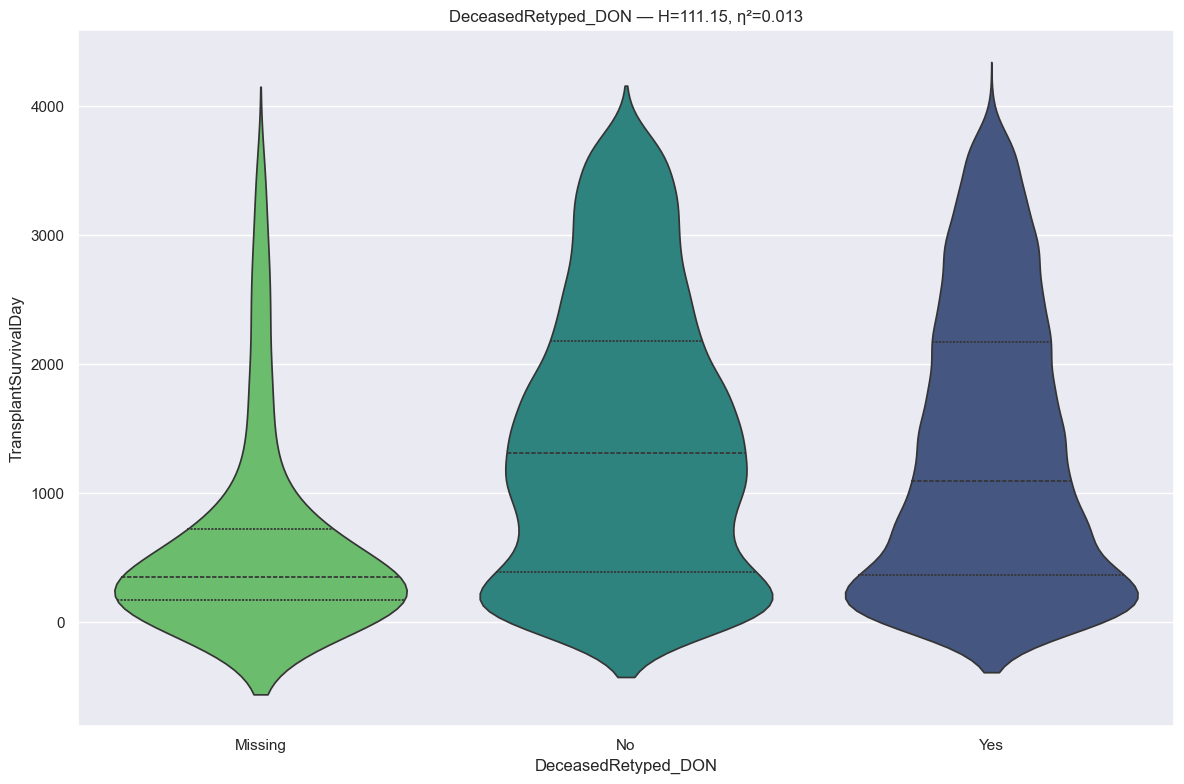

RANKING REPORT: DeceasedRetyped_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :    154 records
 * No                                                :   3081 records
 * Yes                                               :   5084 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 111.1510 | P-value: 7.309077e-25 | Effect η²: 0.0131
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=6.5519e-24 | thr=0.0167 | r= 0.481 | *Sig*
Missing      vs Yes          | p=1.6174e-19 | thr=0.0167 | r= 0.427 | *Sig*
No           vs Yes          | p=5.7472e-06 | thr=0.0167 | r=-0.060 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1

In [6]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [7]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DA1
* Donor-Specific Antibodies (DSAs) directed against antigens (such as HLA Class I or II) are critical factors in transplant rejection, acting as a primary cause of graft loss. The presence of these antibodies before transplant (preformed) or their development afterward (de novo) generally correlates with poor outcomes, particularly in kidney and heart transplants, as they can initiate antibody-mediated rejection (ABMR). 
* Role of DA Antigen in Transplant Research: In experimental studies, particularly in rat heart transplantation, the DA strain (MHC haplotype RT1a) has been used to investigate immunosuppression. 
    * Soluble Class I Antigen: Continuous infusion of purified soluble DA class I antigen can significantly prolong heart graft survival by specifically suppressing allograft rejection.
    * Antigen Complexes: The effectiveness of these antigens is amplified when combined with monoclonal antibodies to create antigen-antibody complexes
    * Graft Dysfunction: The presence of DSAs is associated with increased transplant glomerulopathy and accelerated eGFR decline.
    * Management: Patients with preformed DSAs often undergo desensitization or more intense immunosuppression.

In [8]:
# info
feature = u.get_feature_info(df, 'AntigenDA1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDA1_DON  8319     32   2  3333

:::: NaN Count:
AntigenDA1_DON    0 



{'AntigenDA1_DON': CategoricalDtype(categories=['01:01', '01:02', '02:01', '02:02', '02:03', '02:05',
                   '02:06', '03:01', '03:02', '1', '10', '11', '11:01', '2',
                   '23', '24', '24:02', '24:03', '25', '26', '26:01', '28',
                   '29', '29:02', '3', '30', '30:01', '31', '32', '33', '33:03',
                   '34', '34:02', '36', '66', '66:01', '68', '68:02', '69',
                   '74', 'Missing'],
 , ordered=False, categories_dtype=object)}

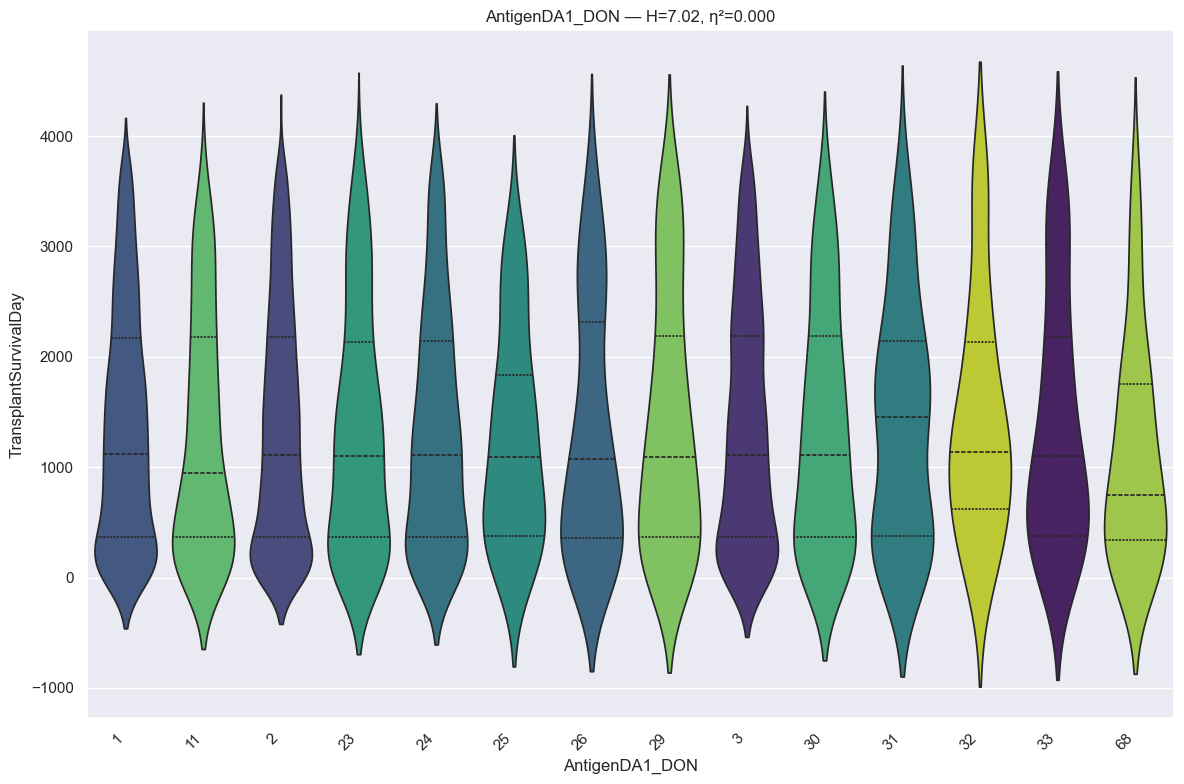

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :   1927 records
 * 11                                                :    389 records
 * 2                                                 :   3333 records
 * 23                                                :    285 records
 * 24                                                :    489 records
 * 25                                                :     59 records
 * 26                                                :    123 records
 * 29                                                :    135 records
 * 3                                                 :   1022 records
 * 30                                                :    185 records
 * 31                                                :     75 records
 * 32                                                :     40 records
 * 33                                                :     82 records
 * 68                        

In [9]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [10]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :   1927 records
 * 11                                                :    389 records
 * 2                                                 :   3333 records
 * 23                                                :    285 records
 * 24                                                :    489 records
 * 25                                                :     59 records
 * 26                                                :    123 records
 * 29                                                :    135 records
 * 3                                                 :   1022 records
 * 30                                                :    185 records
 * 31                                                :     75 records
 * 32                                                :     40 records
 * 33                                                :     82 records
 * 68                        

In [11]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is not statistically significant.

#### AntigenDA2
* Antigen 2 transplant usually refers to Human Leukocyte Antigen (HLA) Class II antigens (such as HLA-DR, -DQ, -DP), which are critical markers in transplantation. Preformed IgG antibodies against these antigens are significant risk factors for high-grade rejection, chronic graft dysfunction (such as transplant glomerulopathy), and poor outcomes in heart and kidney transplants.

In [12]:
# info
feature = u.get_feature_info(df, 'AntigenDA2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top freq
AntigenDA2_DON  8319     40  24  950

:::: NaN Count:
AntigenDA2_DON    0 



{'AntigenDA2_DON': CategoricalDtype(categories=['0', '01:01', '02:01', '02:03', '02:05', '02:06', '03:01',
                   '1', '10', '11', '11:01', '2', '23', '24', '24:02', '24:03',
                   '25', '26', '26:01', '28', '29', '29:01', '29:02', '3', '30',
                   '30:01', '30:02', '31', '32', '33', '33:01', '33:03', '34',
                   '34:02', '36', '43', '66', '66:01', '66:02', '68', '68:01',
                   '68:02', '69', '74', '80', 'Missing',
                   'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

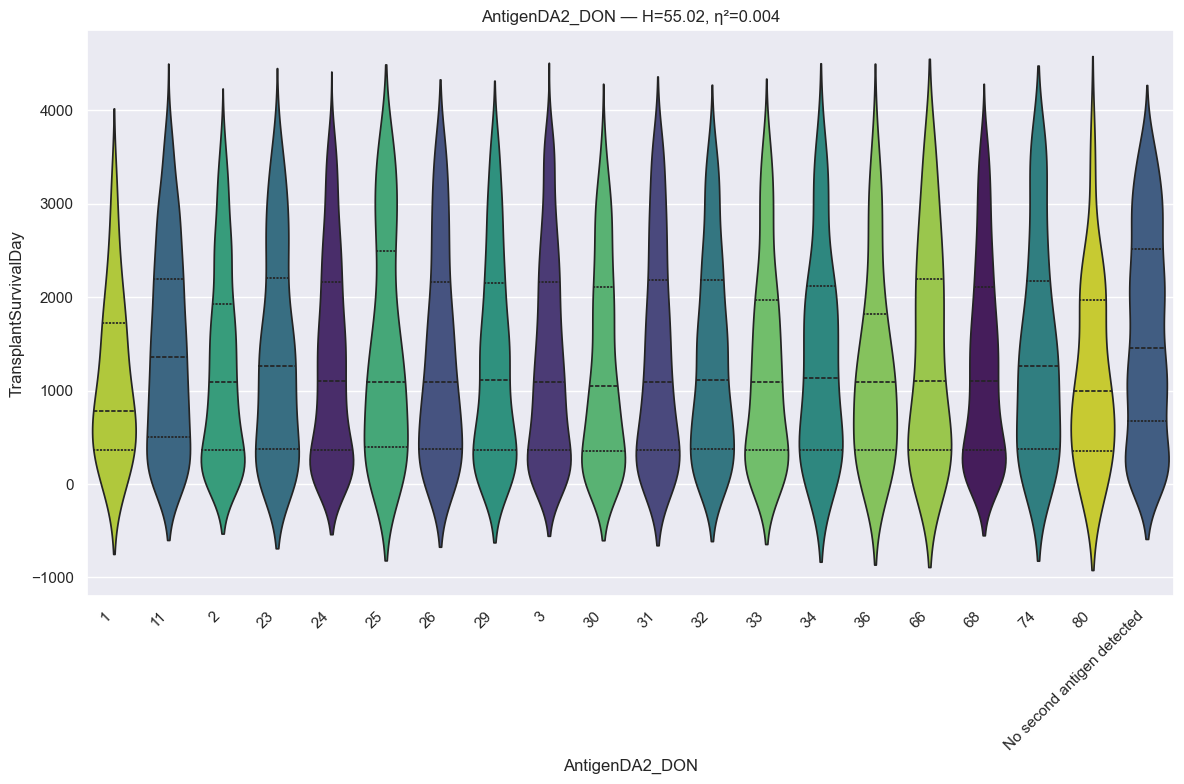

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     59 records
 * 11                                                :    499 records
 * 2                                                 :    844 records
 * 23                                                :    301 records
 * 24                                                :    950 records
 * 25                                                :    178 records
 * 26                                                :    341 records
 * 29                                                :    443 records
 * 3                                                 :    851 records
 * 30                                                :    501 records
 * 31                                                :    434 records
 * 32                                                :    442 records
 * 33                                                :    363 records
 * 34                        

In [13]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [14]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     59 records
 * 11                                                :    499 records
 * 2                                                 :    844 records
 * 23                                                :    301 records
 * 24                                                :    950 records
 * 25                                                :    178 records
 * 26                                                :    341 records
 * 29                                                :    443 records
 * 3                                                 :    851 records
 * 30                                                :    501 records
 * 31                                                :    434 records
 * 32                                                :    442 records
 * 33                                                :    363 records
 * 34                        

In [15]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is statistically significant but lacks clinical interpretation.

####  Antigen DB1
* HLA-DRB1 matching is critical in transplantation to minimize graft-versus-host disease (GVHD) in stem cell transplants and reduce mortality. In solid organ transplant, HLA-DRB1, along with HLA-A, B, DQ, and DP, are key targets for donor-specific antibodies (DSAs), which, if present, can lead to antibody-mediated rejection (AMR).

In [16]:
# info
feature = u.get_feature_info(df, 'AntigenDB1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDB1_DON  8319     67   7  1671

:::: NaN Count:
AntigenDB1_DON    0 



{'AntigenDB1_DON': CategoricalDtype(categories=['07:02', '08:01', '13', '13:02', '14', '14:01', '14:02',
                   '15', '15:01', '15:03', '15:07', '15:10', '15:16', '15:17',
                   '15:18', '18', '27', '27:04', '27:05', '35', '35:01',
                   '35:02', '35:03', '35:08', '35:12', '37', '38', '38:01',
                   '39', '39:01', '39:02', '39:06', '40', '40:01', '40:02',
                   '40:05', '40:06', '41', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '49', '50',
                   '50:01', '51', '51:01', '51:02', '52', '53', '54', '55',
                   '55:01', '56', '56:03', '57', '58', '59', '60', '61', '62',
                   '63', '64', '65', '7', '70', '703', '71', '72', '75', '76',
                   '77', '78', '8', '81', 'Missing'],
 , ordered=False, categories_dtype=object)}

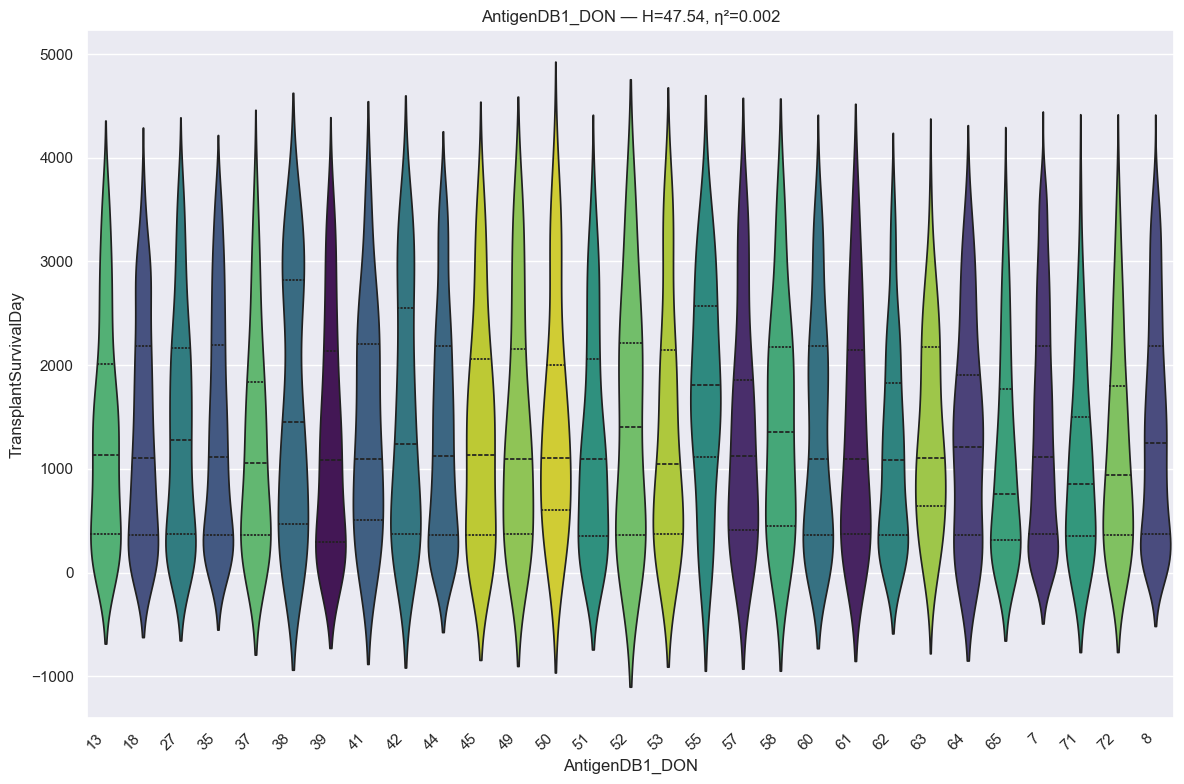

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    272 records
 * 18                                                :    423 records
 * 27                                                :    360 records
 * 35                                                :    922 records
 * 37                                                :    107 records
 * 38                                                :    116 records
 * 39                                                :    231 records
 * 41                                                :     67 records
 * 42                                                :    106 records
 * 44                                                :    722 records
 * 45                                                :     98 records
 * 49                                                :     88 records
 * 50                                                :     38 records
 * 51                        

In [17]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [18]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DB2
* Transplantation antigens are proteins or peptides, primarily Major Histocompatibility Complex (MHC/HLA) molecules, that the immune system recognizes as foreign, triggering rejection in solid organ transplants. In mouse models, specifically H-2Db (a Class I MHC molecule), studies show that antigen-specific CD8+ T-cells are crucial for recognizing and rejecting donor tissue. 

In [19]:
# info
feature = u.get_feature_info(df, 'AntigenDB2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDB2_DON  8319     74  44  1212

:::: NaN Count:
AntigenDB2_DON    0 



{'AntigenDB2_DON': CategoricalDtype(categories=['07:02', '08:01', '12', '13', '13:02', '14', '14:01',
                   '14:02', '15', '15:01', '15:10', '15:16', '15:17', '18',
                   '22', '27', '27:05', '27:08', '35', '35:01', '35:02',
                   '35:03', '35:08', '35:12', '37', '38', '38:01', '39',
                   '39:01', '39:02', '39:05', '39:06', '40', '40:01', '40:02',
                   '40:05', '41', '41:01', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '48:01',
                   '49', '50', '50:01', '51', '51:01', '51:02', '52', '53',
                   '54', '55', '55:01', '56', '56:01', '57', '57:01', '57:03',
                   '58', '59', '60', '61', '62', '63', '64', '65', '67', '7',
                   '70', '71', '72', '73', '75', '76', '77', '78', '8', '81',
                   '82', '82:01', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

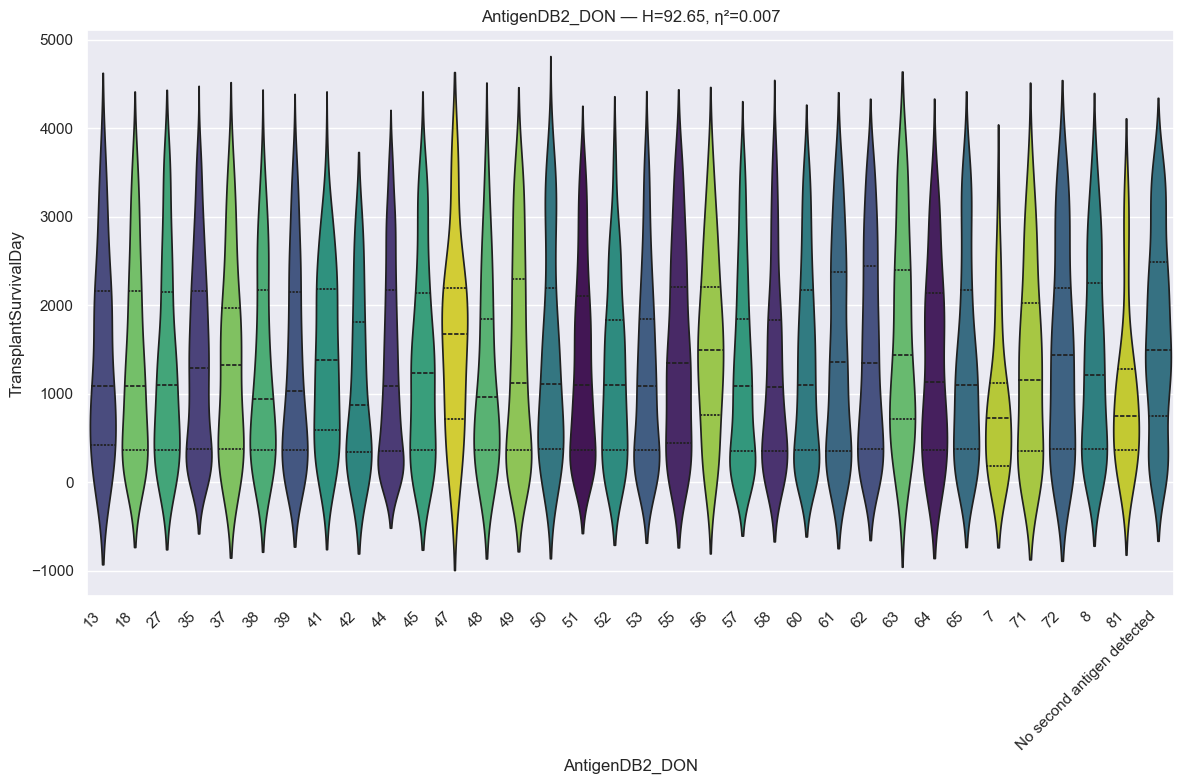

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :     64 records
 * 18                                                :    205 records
 * 27                                                :    190 records
 * 35                                                :    573 records
 * 37                                                :     93 records
 * 38                                                :    125 records
 * 39                                                :    213 records
 * 41                                                :    104 records
 * 42                                                :     71 records
 * 44                                                :   1212 records
 * 45                                                :    162 records
 * 47                                                :     39 records
 * 48                                                :     75 records
 * 49                        

In [20]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [21]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antigen DR1
* HLA-DR1 is a specific antigen within the HLA Class II system that plays a significant role in transplantation compatibility. Recipients with the HLA-DR1 phenotype often show increased overall graft survival and are considered `low responders`, meaning they have a lower risk of organ rejection, particularly of kidneys.

In [22]:
# info
feature = u.get_feature_info(df, 'AntigenDR1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDR1_DON  8319     35   4  2012

:::: NaN Count:
AntigenDR1_DON    0 



{'AntigenDR1_DON': CategoricalDtype(categories=['01:01', '01:02', '01:03', '03:01', '03:02', '04:01',
                   '04:02', '04:03', '04:04', '04:05', '04:07', '04:11',
                   '08:01', '08:02', '09:01', '1', '10', '103', '11', '11:01',
                   '11:03', '11:04', '12', '12:01', '13', '13:01', '13:02',
                   '13:03', '13:05', '14', '14:02', '14:04', '14:54', '15',
                   '15:01', '16', '17', '18', '3', '4', '7', '8', '9',
                   'Missing'],
 , ordered=False, categories_dtype=object)}

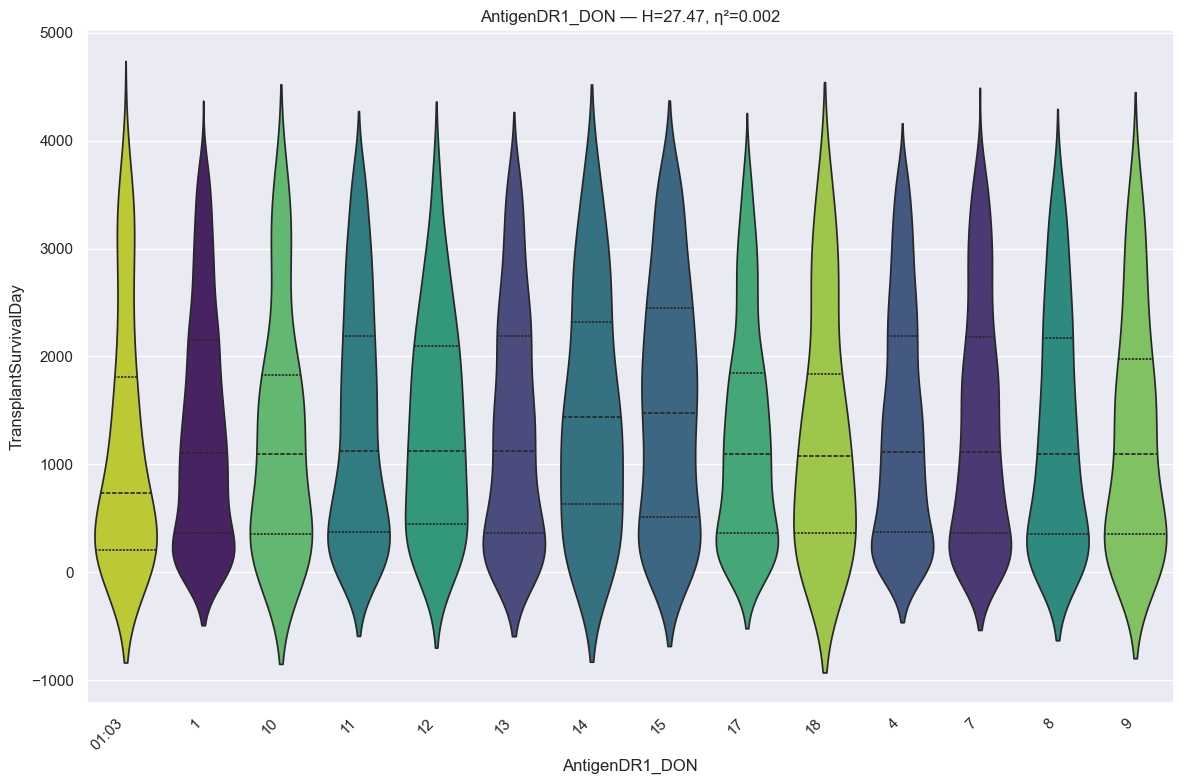

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    142 records
 * 1                                                 :   1411 records
 * 10                                                :    104 records
 * 11                                                :    690 records
 * 12                                                :    144 records
 * 13                                                :    638 records
 * 14                                                :    115 records
 * 15                                                :    344 records
 * 17                                                :    853 records
 * 18                                                :     74 records
 * 4                                                 :   2012 records
 * 7                                                 :   1135 records
 * 8                                                 :    428 records
 * 9                         

In [23]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [24]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    142 records
 * 1                                                 :   1411 records
 * 10                                                :    104 records
 * 11                                                :    690 records
 * 12                                                :    144 records
 * 13                                                :    638 records
 * 14                                                :    115 records
 * 15                                                :    344 records
 * 17                                                :    853 records
 * 18                                                :     74 records
 * 4                                                 :   2012 records
 * 7                                                 :   1135 records
 * 8                                                 :    428 records
 * 9                         

In [25]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is statistically significant but lacks clinical interpretation.

#### Antigen DR2
* HLA-DR2 (a specific type of Human Leukocyte Antigen, part of Class II MHC) is a key protein in transplant immunology that affects compatibility and immune response. While HLA matching is generally essential, the presence of DR2 has historically been linked to higher sensitization and potentially lower graft survival in kidney transplants.

In [26]:
# info
feature = u.get_feature_info(df, 'AntigenDR2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
AntigenDR2_DON  8319     38  15  1687

:::: NaN Count:
AntigenDR2_DON    0 



{'AntigenDR2_DON': CategoricalDtype(categories=['01:01', '01:03', '03:01', '04:01', '04:04', '04:05',
                   '04:07', '08:01', '08:02', '09:01', '1', '10', '103', '11',
                   '11:01', '11:03', '11:04', '12', '12:01', '12:02', '13',
                   '13:01', '13:02', '13:03', '13:05', '14', '14:01', '14:02',
                   '14:04', '14:06', '14:54', '15', '15:01', '15:02', '15:03',
                   '16', '16:01', '16:02', '17', '18', '3', '4', '5', '7', '8',
                   '9', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

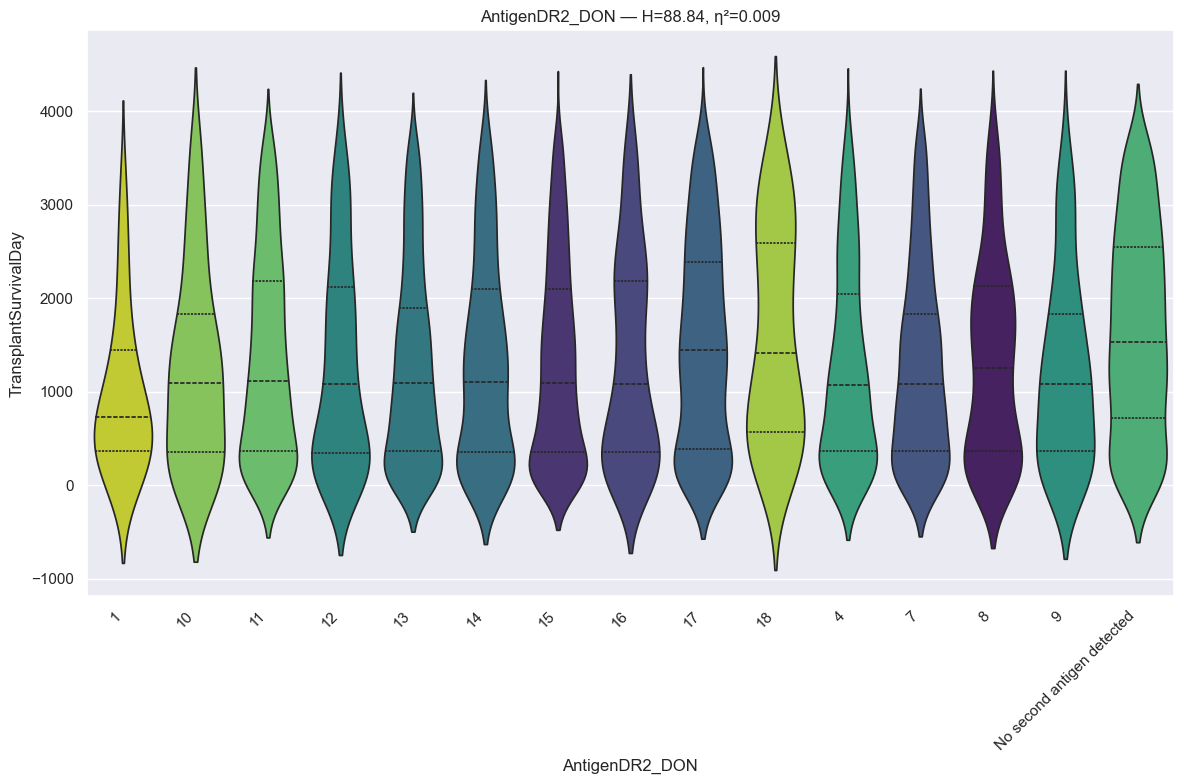

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     33 records
 * 10                                                :    104 records
 * 11                                                :    839 records
 * 12                                                :    219 records
 * 13                                                :   1359 records
 * 14                                                :    453 records
 * 15                                                :   1687 records
 * 16                                                :    267 records
 * 17                                                :    821 records
 * 18                                                :     97 records
 * 4                                                 :    594 records
 * 7                                                 :    726 records
 * 8                                                 :    298 records
 * 9                         

In [27]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [28]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     33 records
 * 10                                                :    104 records
 * 11                                                :    839 records
 * 12                                                :    219 records
 * 13                                                :   1359 records
 * 14                                                :    453 records
 * 15                                                :   1687 records
 * 16                                                :    267 records
 * 17                                                :    821 records
 * 18                                                :     97 records
 * 4                                                 :    594 records
 * 7                                                 :    726 records
 * 8                                                 :    298 records
 * 9                         

In [29]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is statistically significant but lacks clinical interpretation.

#### Citizenship

In [30]:
# info
feature = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique         top  freq
Citizenship_DON  8319      7  US Citizen  7652

:::: NaN Count:
Citizenship_DON    0 



{'Citizenship_DON': CategoricalDtype(categories=['Missing', 'NON-RESIDENT ALIEN',
                   'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant',
                   'Non-US Citizen/US Resident', 'RESIDENT ALIEN', 'US Citizen',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

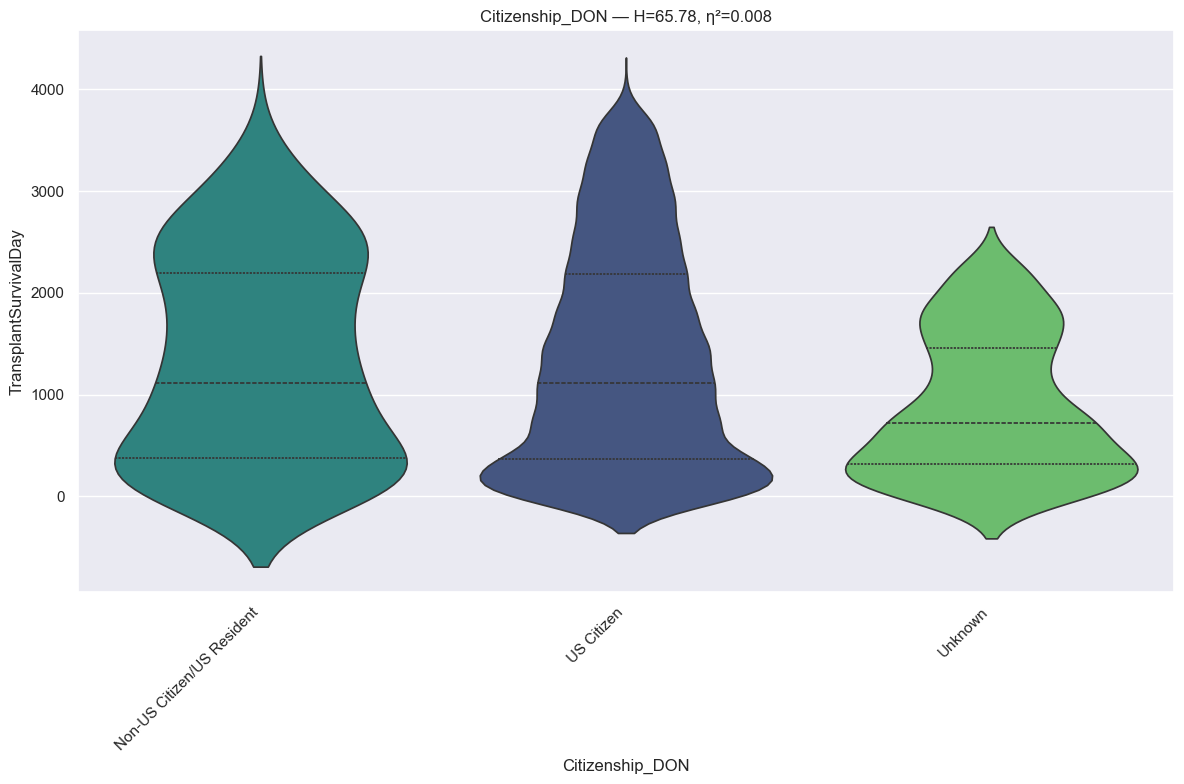

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Non-US Citizen/US Resident                        :    219 records
 * US Citizen                                        :   7652 records
 * Unknown                                           :    396 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     13 records
 * NON-RESIDENT ALIEN                                :      3 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     22 records
 * RESIDENT ALIEN                                    :     14 records
--------------------------------------------------------------------------------
Kruskal H: 65.7847 | P-value: 5.188532e-15 | Effect η²: 0.0077
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
US Citizen   vs Unknown      | p=6.8346e-16 | thr=0.0167 | r=-0.240

In [31]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [32]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Non-US Citizen/US Resident                        :    219 records
 * US Citizen                                        :   7652 records
 * Unknown                                           :    396 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     13 records
 * NON-RESIDENT ALIEN                                :      3 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     22 records
 * RESIDENT ALIEN                                    :     14 records
--------------------------------------------------------------------------------
Kruskal H: 65.7847 | P-value: 5.188532e-15 | Effect η²: 0.0077
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 group

In [33]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Past Cocaine Use

In [34]:
# info
feature = u.get_feature_info(df, 'PastCocaineUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top  freq
PastCocaineUse_DON  8319      4  No  6578

:::: NaN Count:
PastCocaineUse_DON    0 



{'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

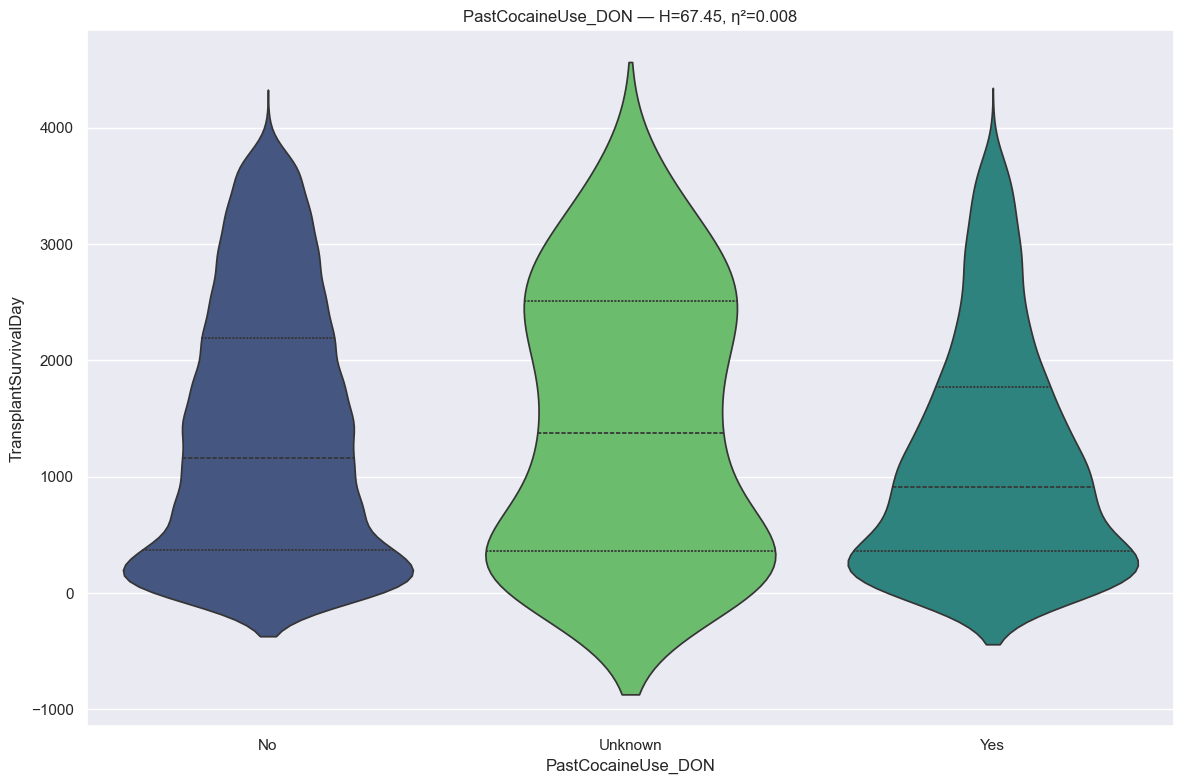

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6578 records
 * Unknown                                           :    121 records
 * Yes                                               :   1606 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 67.4490 | P-value: 2.257497e-15 | Effect η²: 0.0079
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.9944e-16 | thr=0.0167 | r=-0.131 | *Sig*
Unknown      vs Yes          | p=7.8936e-03 | thr=0.0167 | r=-0.145 | *Sig*
No           vs Unknown      | p=6.6412e-01 | thr=0.0167 | r= 0.023 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::::::::::::::

In [35]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [36]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Ethnicity

In [37]:
# info
feature = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique                  top  freq
Ethnicity_DON  8319      7  White, Non-Hispanic  5619

:::: NaN Count:
Ethnicity_DON    0 



{'Ethnicity_DON': CategoricalDtype(categories=['Amer Ind/Alaska Native', 'Asian', 'Black', 'Hispanic',
                   'Multiracial', 'Native Hawaiian/other Pacific Islander',
                   'White, Non-Hispanic'],
 , ordered=False, categories_dtype=object)}

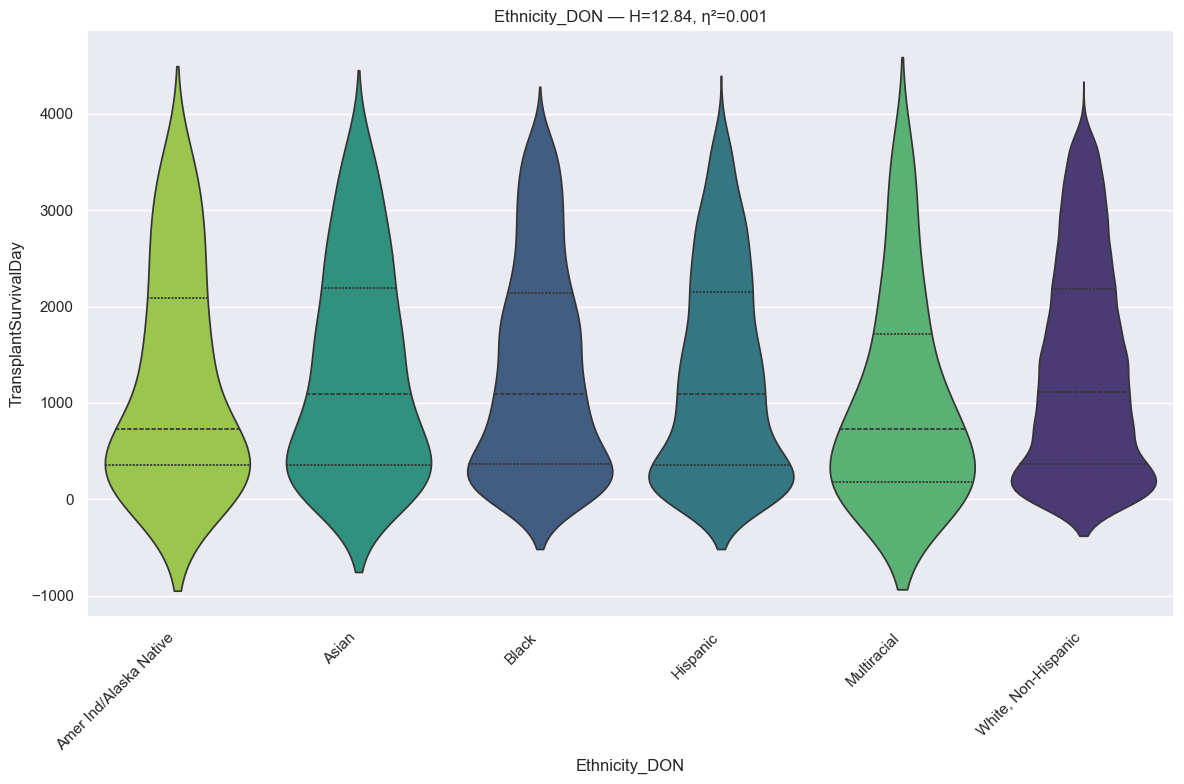

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :     67 records
 * Asian                                             :    183 records
 * Black                                             :   1255 records
 * Hispanic                                          :   1120 records
 * Multiracial                                       :     58 records
 * White, Non-Hispanic                               :   5619 records
BYPASSED CATEGORIES (n < min_n):
 * Native Hawaiian/other Pacific Islander            :     17 records
--------------------------------------------------------------------------------
Kruskal H: 12.8436 | P-value: 2.488943e-02 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Multiracial  vs White, Non-Hispanic | p=7.6627e-03 | thr=0.0033 | r= 0.203 | Not Sig
Black        

In [38]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [39]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Hepatitis B Core Antibody

In [40]:
# info
feature = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                             count unique       top  freq
Hepatitis_B_CoreAntibody_DON  8319      3  Negative  8138

:::: NaN Count:
Hepatitis_B_CoreAntibody_DON    0 



{'Hepatitis_B_CoreAntibody_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

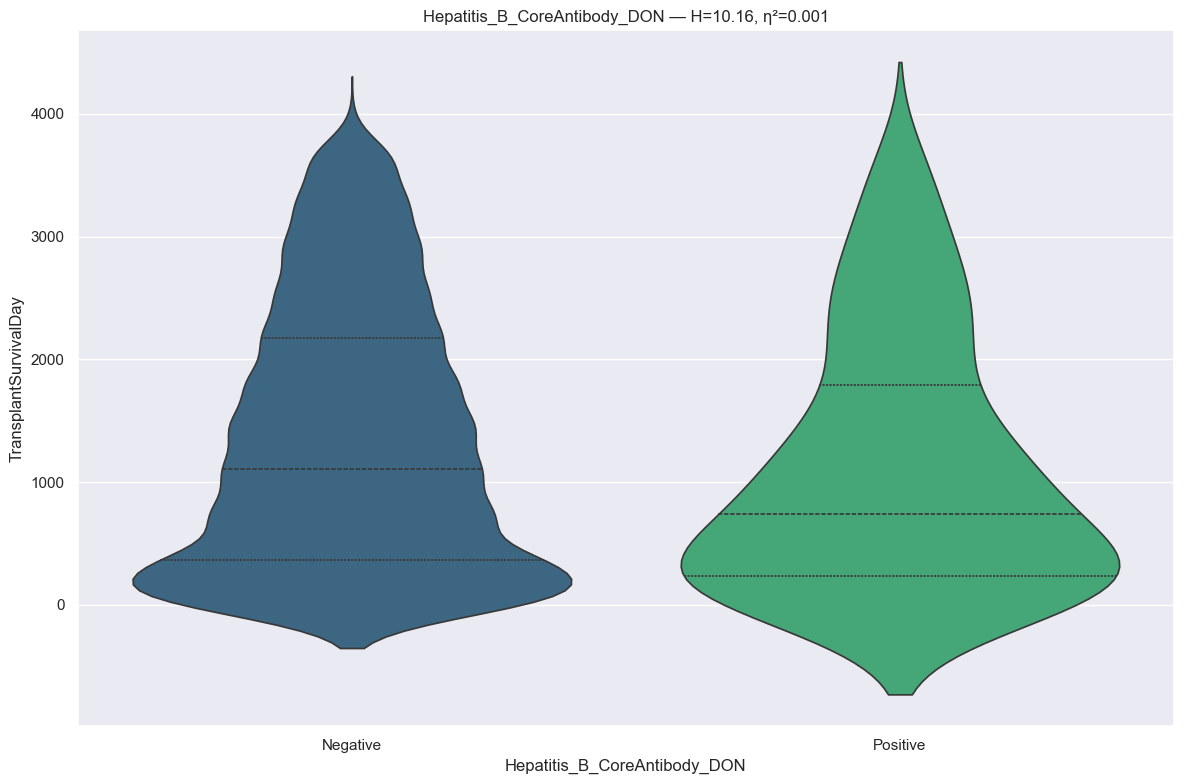

RANKING REPORT: Hepatitis_B_CoreAntibody_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8138 records
 * Positive                                          :    176 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      5 records
--------------------------------------------------------------------------------
Kruskal H: 10.1604 | P-value: 1.434856e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=1.4349e-03 | thr=0.0500 | r=-0.140 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

>>> Group_2 (1 categories)
  - Positive

>>> Other (1 categories)
  - Not Done

Hepatitis_B_CoreAntibody_DO

In [41]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [42]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Surface Antigen HEP B

In [43]:
# info
feature = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique       top  freq
SurfaceAntigenHEP_B_DON  8319      4  Negative  8302

:::: NaN Count:
SurfaceAntigenHEP_B_DON    0 



{'SurfaceAntigenHEP_B_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

In [44]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

[WARNING] Cannot perform statistical comparison for SurfaceAntigenHEP_B_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

SurfaceAntigenHEP_B_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Negative         1338.906288                1105.0                 3956.0                    0.0          8302
               Positive          690.428571                 653.0                 1780.0                   45.0             7
               Not Done         1151.000000                 935.5                 2556.0                  365.0             6
                Missing         1527.500000                1327.5                 3093.0                  362.0             4


##### **Note:** We will perform a manual Binning in which the Positive, Missing, Not Done, and Indeterminate groups are grouped into a single category called `Non-Negative` (Total $n=36$). This would give us just enough data to meet your $n \ge 30$ threshold and compare `Negative` vs. `Non-Negative`.

In [45]:
# mapping
mapping = {'Positive': 'Other',
           'Missing': 'Other',
           'Not Done': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

SurfaceAntigenHEP_B_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Negative         1338.906288                1105.0                 3956.0                    0.0          8302
                  Other         1049.941176                 757.0                 3093.0                   45.0            17


In [46]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** Unable to determine statistical significance due to sample size, and very small sample size.

#### Blood Group

In [47]:
# info
feature = u.get_feature_info(df, 'BloodGroup', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
BloodGroup_DON  8319      8   O  4401

:::: NaN Count:
BloodGroup_DON    0 



{'BloodGroup_DON': CategoricalDtype(categories=['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O'], ordered=False, categories_dtype=object)}

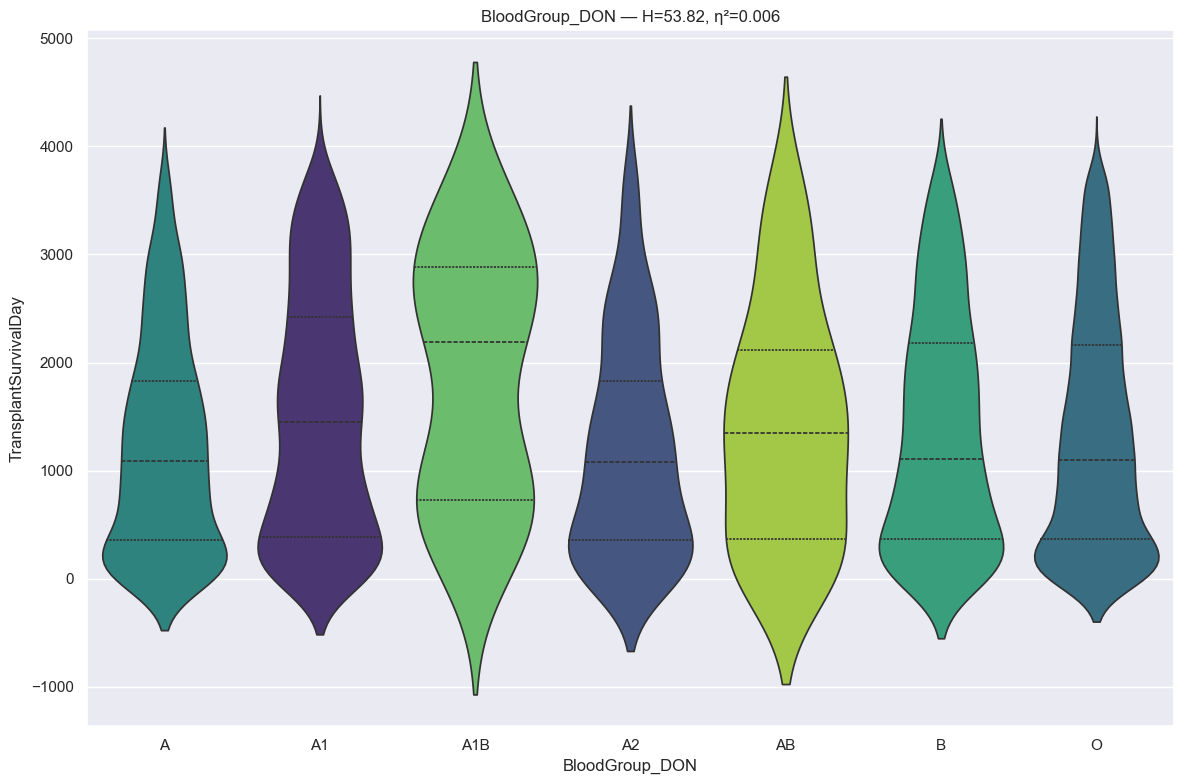

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   1186 records
 * A1                                                :   1526 records
 * A1B                                               :     37 records
 * A2                                                :    243 records
 * AB                                                :     57 records
 * B                                                 :    851 records
 * O                                                 :   4401 records
BYPASSED CATEGORIES (n < min_n):
 * A2B                                               :     18 records
--------------------------------------------------------------------------------
Kruskal H: 53.8218 | P-value: 8.013310e-10 | Effect η²: 0.0058
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
A            vs A1         

In [48]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [49]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Heavy Alcohol Use

In [50]:
# info
feature = u.get_feature_info(df, 'HeavyAlcoholUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
HeavyAlcoholUse_DON  8319      4  No  7155

:::: NaN Count:
HeavyAlcoholUse_DON    0 



{'HeavyAlcoholUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

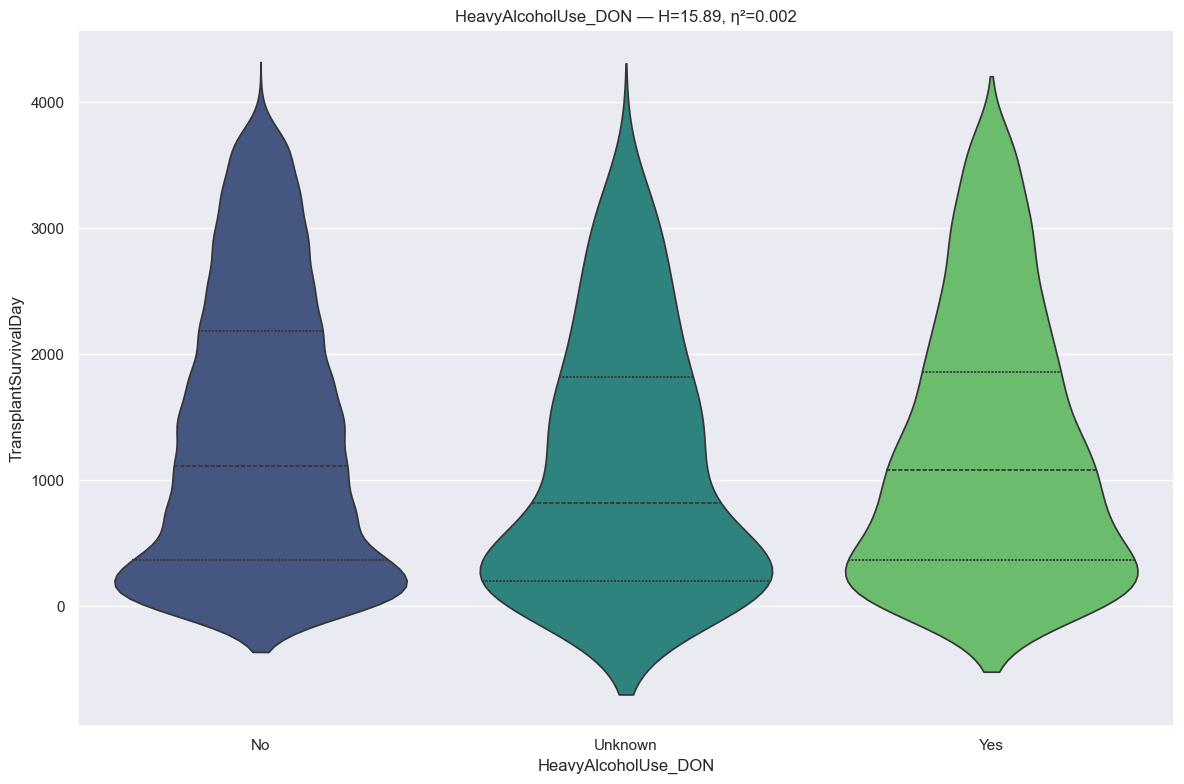

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7155 records
 * Unknown                                           :    172 records
 * Yes                                               :    989 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 15.8876 | P-value: 3.548478e-04 | Effect η²: 0.0017
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=3.6770e-03 | thr=0.0167 | r=-0.129 | *Sig*
No           vs Yes          | p=4.0244e-03 | thr=0.0167 | r=-0.056 | *Sig*
Unknown      vs Yes          | p=1.1215e-01 | thr=0.0167 | r= 0.076 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::

In [51]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [52]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7155 records
 * Unknown                                           :    172 records
 * Yes                                               :    989 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 15.8876 | P-value: 3.548478e-04 | Effect η²: 0.0017
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (2 categories)
  - Unknown
  - Yes

>>> Other (1 categories)
  - Missing



In [53]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Gender

In [54]:
# add to remove list
remove_cols.extend(['Gender_DON'])

#### Residency State

In [55]:
# info
feature = u.get_feature_info(df, 'ResidencyState', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top freq
ResidencyState_DON  8319     54  CA  755

:::: NaN Count:
ResidencyState_DON    0 



{'ResidencyState_DON': CategoricalDtype(categories=['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE',
                   'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
                   'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND',
                   'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
                   'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA',
                   'WI', 'WV', 'WY', 'XX', 'ZZ'],
 , ordered=False, categories_dtype=object)}

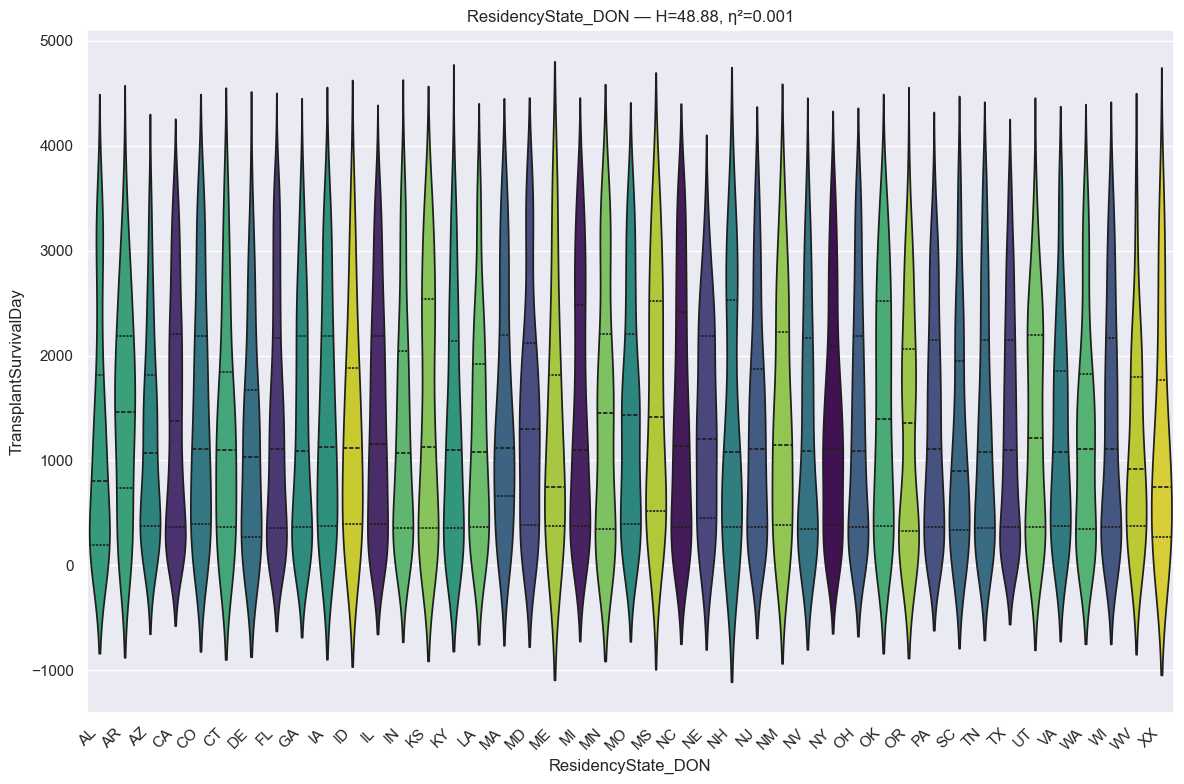

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AL                                                :    134 records
 * AR                                                :     58 records
 * AZ                                                :    196 records
 * CA                                                :    755 records
 * CO                                                :    133 records
 * CT                                                :     67 records
 * DE                                                :     59 records
 * FL                                                :    536 records
 * GA                                                :    278 records
 * IA                                                :     73 records
 * ID                                                :     42 records
 * IL                                                :    346 records
 * IN                                                :    217 records
 * KS                    

In [56]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [57]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AL                                                :    134 records
 * AR                                                :     58 records
 * AZ                                                :    196 records
 * CA                                                :    755 records
 * CO                                                :    133 records
 * CT                                                :     67 records
 * DE                                                :     59 records
 * FL                                                :    536 records
 * GA                                                :    278 records
 * IA                                                :     73 records
 * ID                                                :     42 records
 * IL                                                :    346 records
 * IN                                                :    217 records
 * KS                    

In [58]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is not a statistically significant result.

#### Antibody HEP C
* Research shows that getting a kidney from a hepatitis C-positive donor does not lower a patient's or the kidney's survival for up to ten years after transplant. However, there may still be some risk, especially if the donor's virus type differs from the patients.'

In [59]:
# info
feature = u.get_feature_info(df, 'Antibody_HEP_C', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
Antibody_HEP_C_DON  8319      4  Negative  7872

:::: NaN Count:
Antibody_HEP_C_DON    0 



{'Antibody_HEP_C_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive'],
 , ordered=False, categories_dtype=object)}

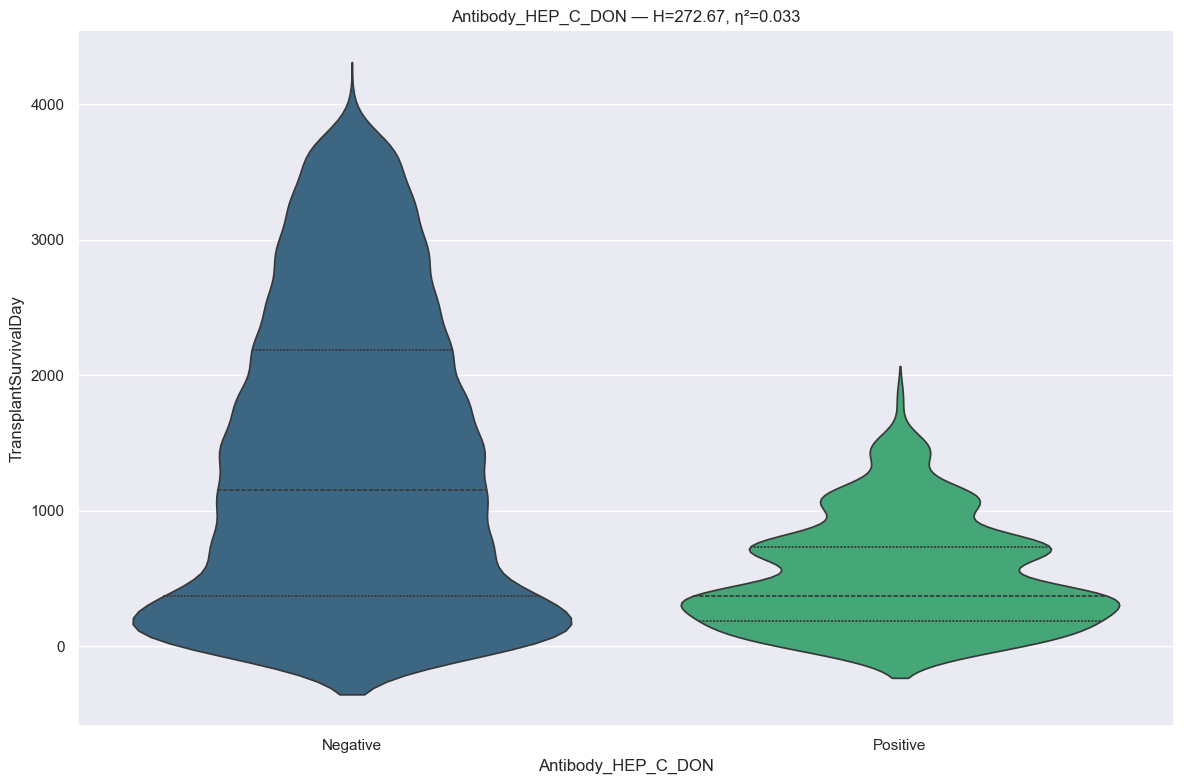

RANKING REPORT: Antibody_HEP_C_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   7872 records
 * Positive                                          :    445 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
 * Not Done                                          :      1 records
--------------------------------------------------------------------------------
Kruskal H: 272.6704 | P-value: 2.971138e-61 | Effect η²: 0.0327
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=2.9716e-61 | thr=0.0500 | r=-0.465 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

>>> Group_2 (1 categories)
  - Positive

>>> O

In [60]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [61]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Non Heart Beating

In [62]:
# info
feature = u.get_feature_info(df, 'NonHeartBeating', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
NonHeartBeating_DON  8319      3  No  8282

:::: NaN Count:
NonHeartBeating_DON    0 



{'NonHeartBeating_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

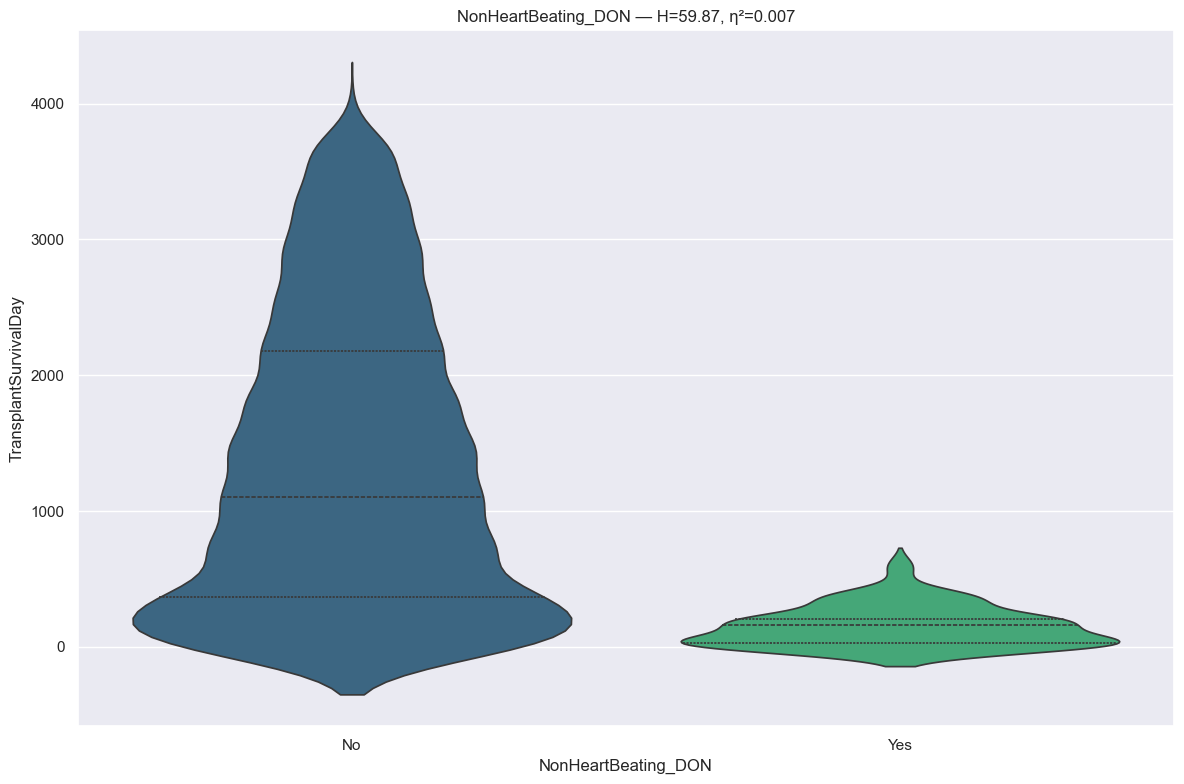

RANKING REPORT: NonHeartBeating_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8282 records
 * Yes                                               :     36 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 59.8740 | P-value: 1.011273e-14 | Effect η²: 0.0071
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.0115e-14 | thr=0.0500 | r=-0.746 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

NonHeartBeating_DON  mean_survival_days  median_

In [63]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [64]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Anti Hypertensive

In [65]:
# info
feature = u.get_feature_info(df, 'AntiHypertensive_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
AntiHypertensive_DON  8319      4  No  5506

:::: NaN Count:
AntiHypertensive_DON    0 



{'AntiHypertensive_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

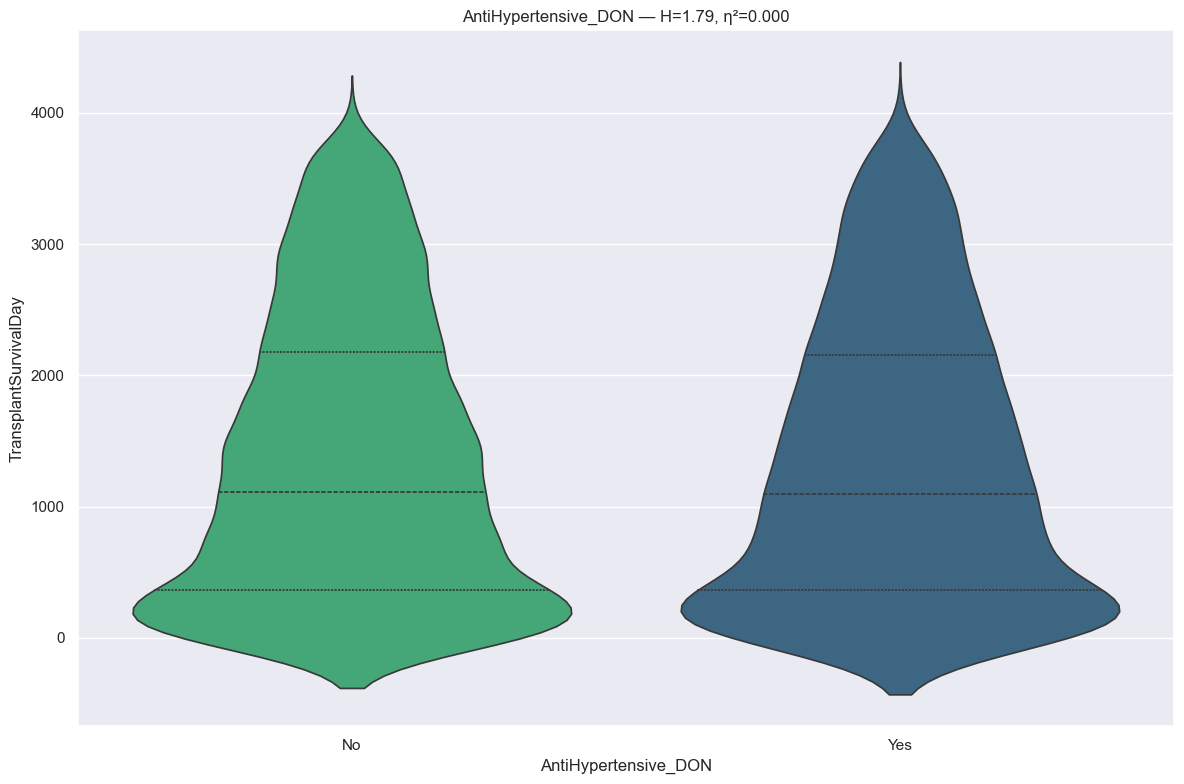

RANKING REPORT: AntiHypertensive_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5506 records
 * Yes                                               :   2797 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 1.7881 | P-value: 1.811546e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.8116e-01 | thr=0.0500 | r=-0.018 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (2 categories)
  - Missing
  - U

In [66]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [67]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntiHypertensive_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5506 records
 * Yes                                               :   2797 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 1.7881 | P-value: 1.811546e-01 | Effect η²: 0.0001
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [68]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is not a statistically significant result.

#### Blood Infection Source

In [69]:
# info
feature = u.get_feature_info(df, 'BloodInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique top  freq
BloodInfectionSource_DON  8319      3  No  7471

:::: NaN Count:
BloodInfectionSource_DON    0 



{'BloodInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

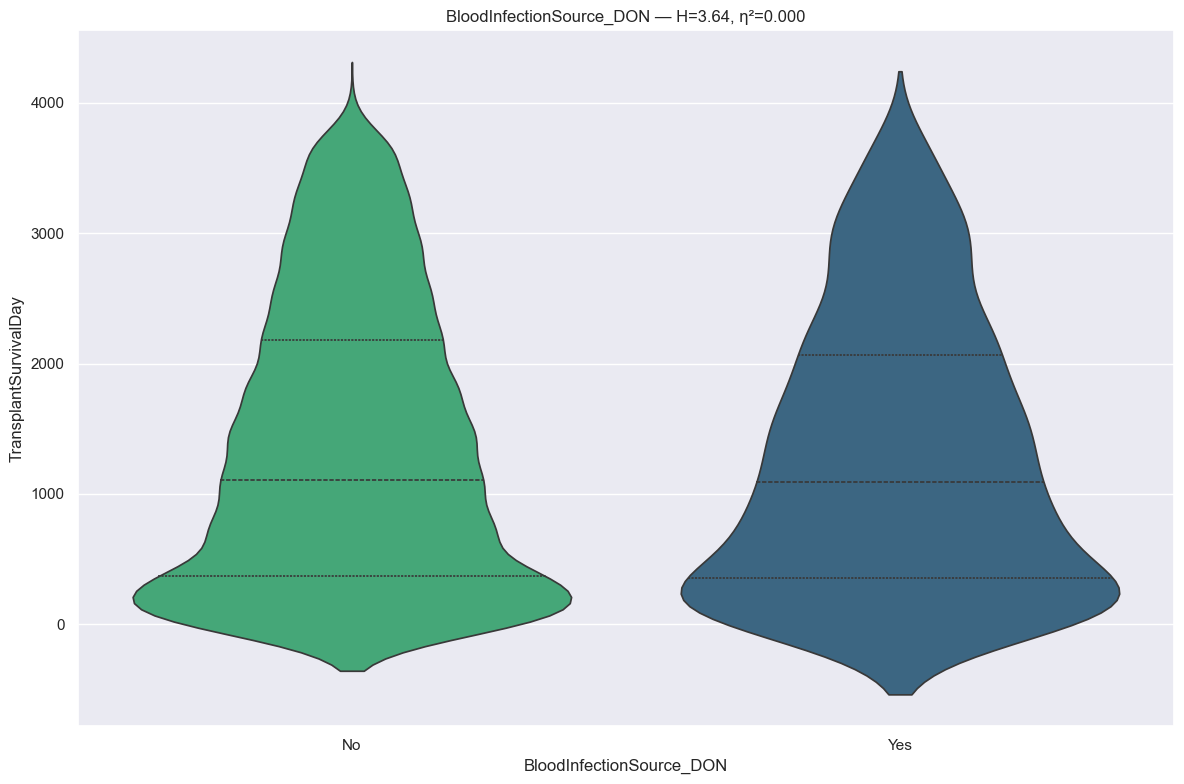

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7471 records
 * Yes                                               :    847 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.6373 | P-value: 5.649835e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.6499e-02 | thr=0.0500 | r=-0.040 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Missing

BloodInfectionSource_DON  mean_survival_days  median_survival_days  ma

In [70]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [71]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7471 records
 * Yes                                               :    847 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.6373 | P-value: 5.649835e-02 | Effect η²: 0.0003
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Missing



In [72]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is not a statistically significant result.

#### OtherInfectionSource_DON

In [73]:
# info
feature = u.get_feature_info(df, 'OtherInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique top  freq
OtherInfectionSource_DON  8319      3  No  5743

:::: NaN Count:
OtherInfectionSource_DON    0 



{'OtherInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

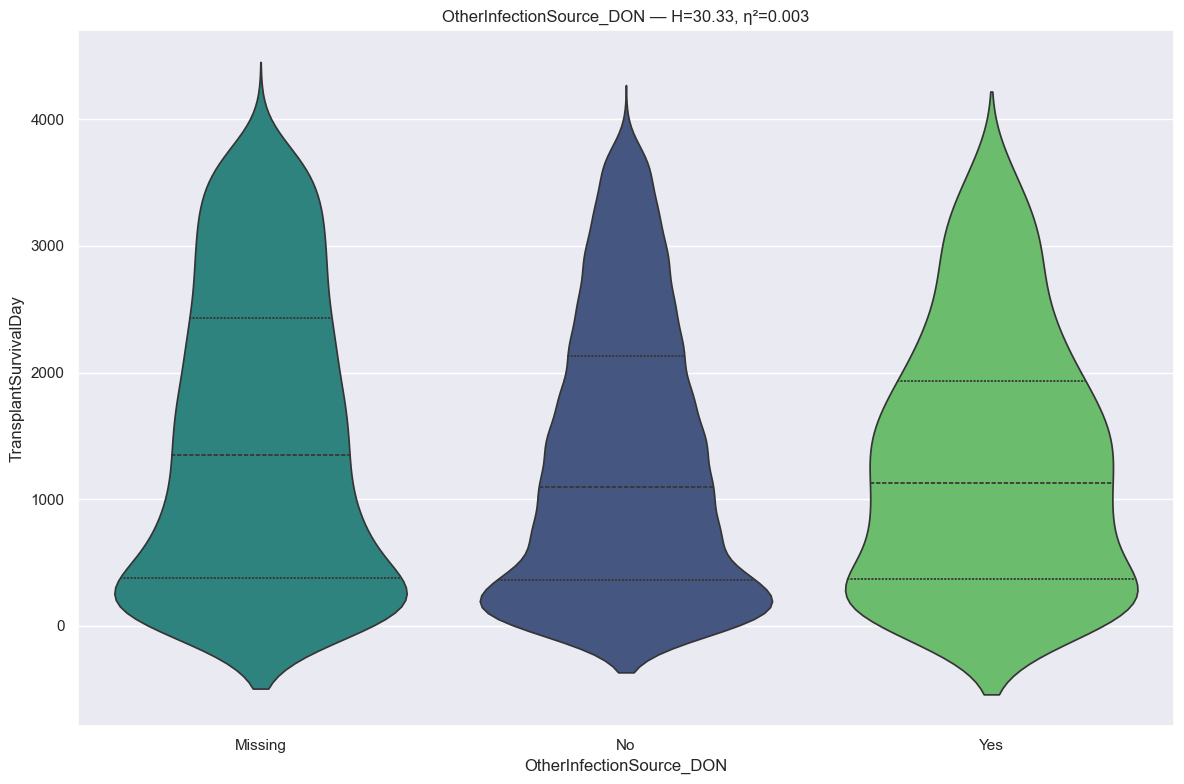

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   1930 records
 * No                                                :   5743 records
 * Yes                                               :    646 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 30.3284 | P-value: 2.595780e-07 | Effect η²: 0.0034
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=4.2467e-08 | thr=0.0167 | r=-0.083 | *Sig*
Missing      vs Yes          | p=9.5194e-03 | thr=0.0167 | r=-0.068 | *Sig*
No           vs Yes          | p=3.9625e-01 | thr=0.0167 | r= 0.020 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> G

In [74]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [75]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature shows a statistically significant result, but it is not clinically meaningful because Yes and No are grouped together.

#### Diuretics

In [76]:
# info
feature = u.get_feature_info(df, 'Diuretics', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique  top  freq
Diuretics_DON  8319      4  Yes  5909

:::: NaN Count:
Diuretics_DON    0 



{'Diuretics_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

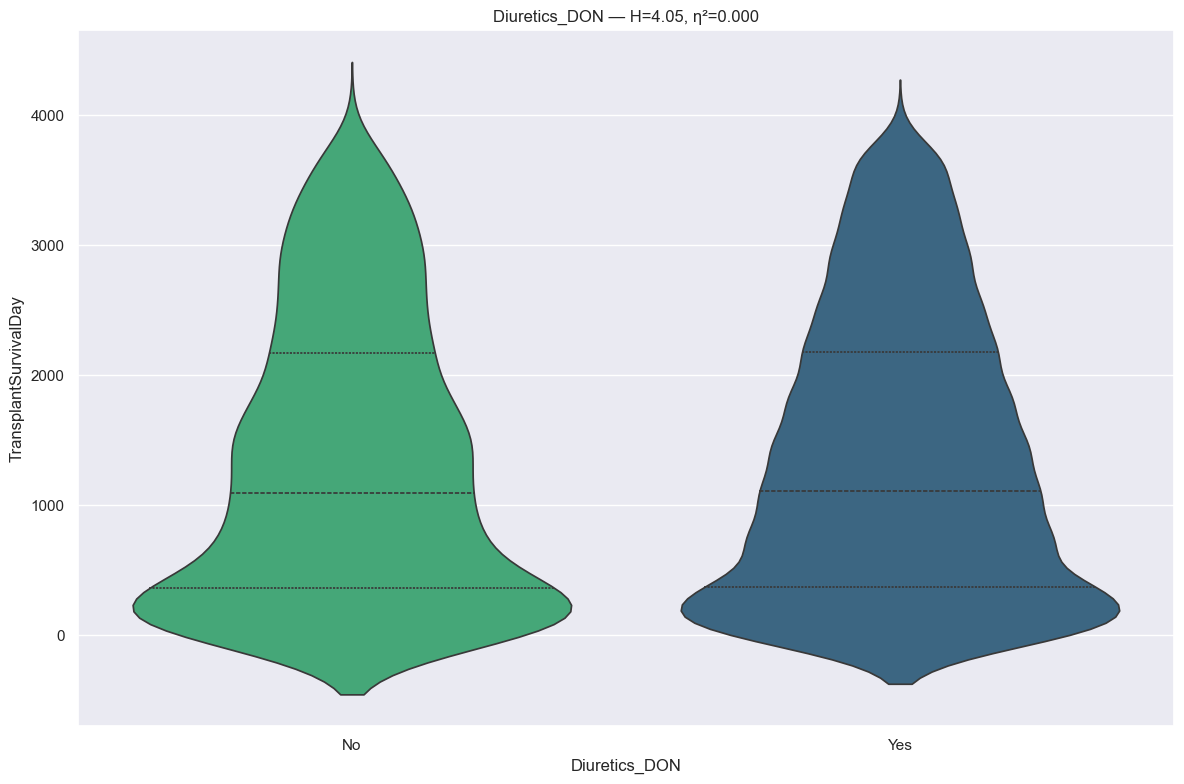

RANKING REPORT: Diuretics_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2394 records
 * Yes                                               :   5909 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 4.0539 | P-value: 4.406898e-02 | Effect η²: 0.0004
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.4070e-02 | thr=0.0500 | r= 0.028 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories

In [77]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [78]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: Diuretics_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2394 records
 * Yes                                               :   5909 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 4.0539 | P-value: 4.406898e-02 | Effect η²: 0.0004
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [79]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Steroids Use

In [80]:
# info
feature = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique  top  freq
SteroidsUse_DON  8319      4  Yes  5936

:::: NaN Count:
SteroidsUse_DON    0 



{'SteroidsUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

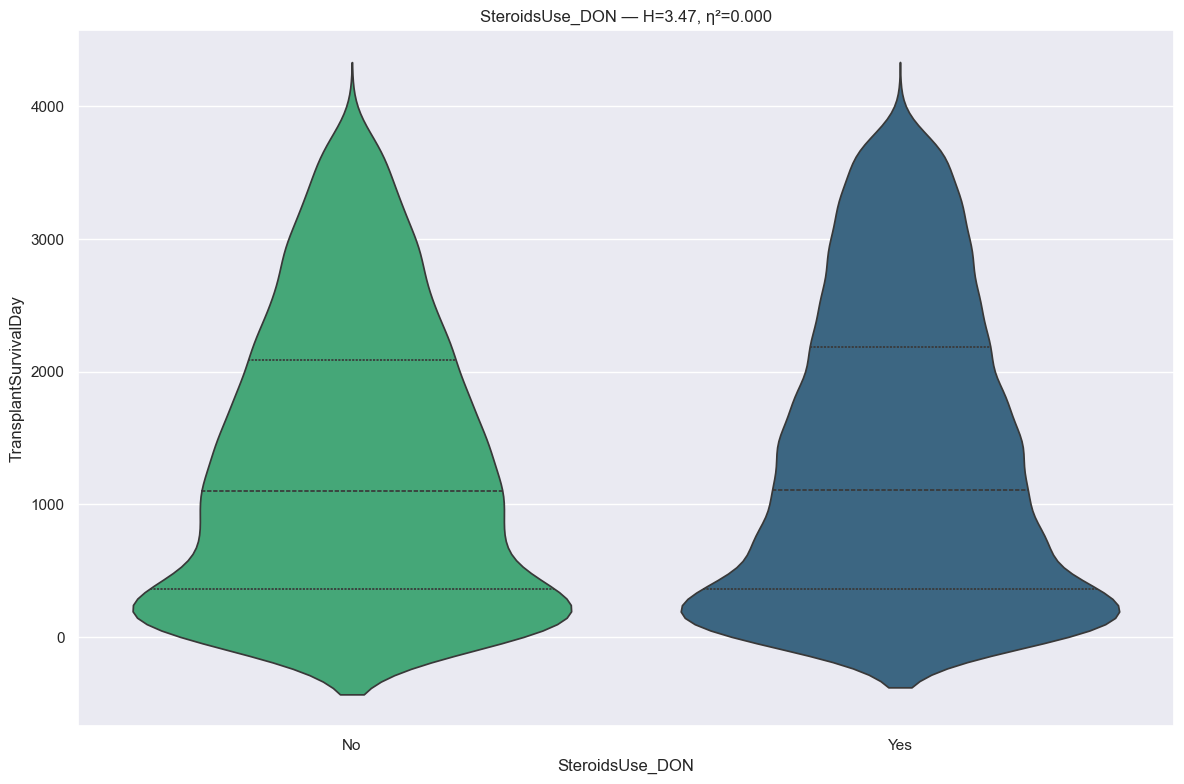

RANKING REPORT: SteroidsUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2359 records
 * Yes                                               :   5936 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 3.4733 | P-value: 6.236494e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.2366e-02 | thr=0.0500 | r= 0.026 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknow

In [81]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [82]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: SteroidsUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2359 records
 * Yes                                               :   5936 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 3.4733 | P-value: 6.236494e-02 | Effect η²: 0.0003
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [83]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature is not a statistically significant result, but it is not clinically meaningful because Yes and No are grouped together.

#### Triiodothyronine T3

In [84]:
# info
feature = u.get_feature_info(df, 'TriiodothyronineT3', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top  freq
TriiodothyronineT3_DON  8319      4  No  8268

:::: NaN Count:
TriiodothyronineT3_DON    0 



{'TriiodothyronineT3_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

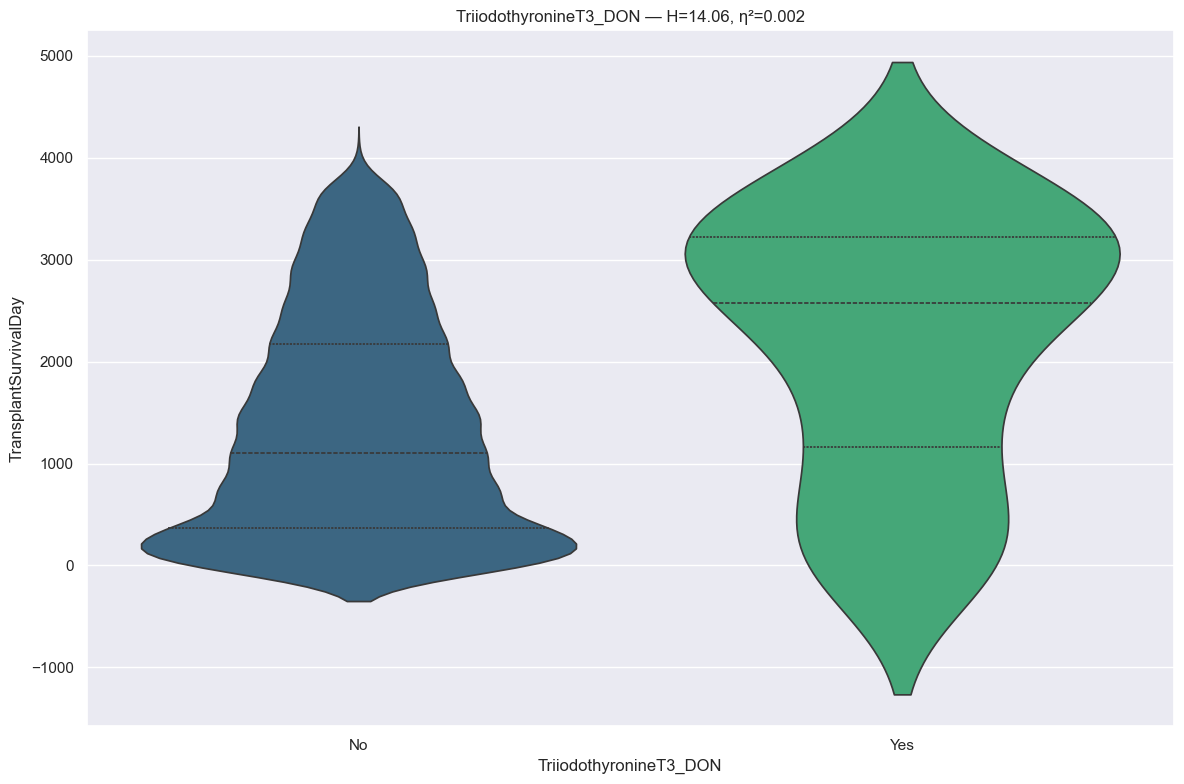

RANKING REPORT: TriiodothyronineT3_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8268 records
 * Yes                                               :     34 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 14.0631 | P-value: 1.767824e-04 | Effect η²: 0.0016
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.7681e-04 | thr=0.0500 | r= 0.372 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 

In [85]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [86]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: TriiodothyronineT3_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8268 records
 * Yes                                               :     34 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 14.0631 | P-value: 1.767824e-04 | Effect η²: 0.0016
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [87]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Thyroxine T4

In [88]:
# info
feature = u.get_feature_info(df, 'ThyroxineT4', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique  top  freq
ThyroxineT4_DON  8319      4  Yes  5351

:::: NaN Count:
ThyroxineT4_DON    0 



{'ThyroxineT4_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

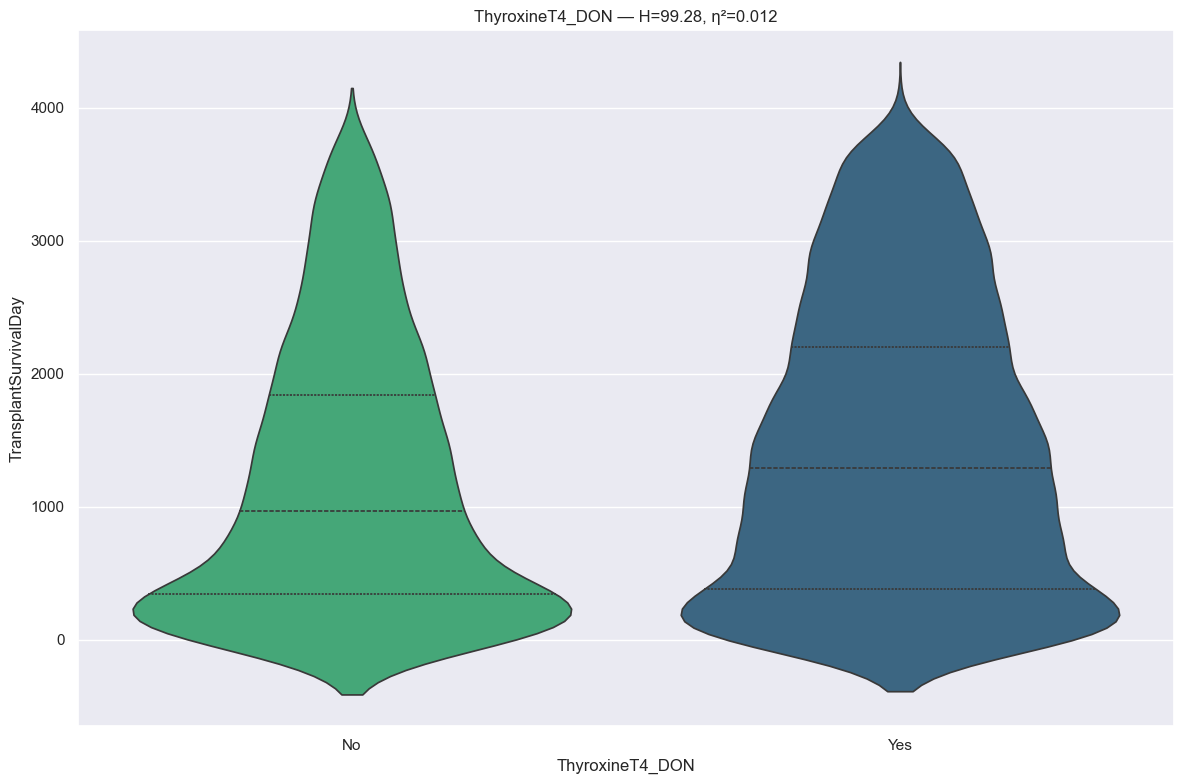

RANKING REPORT: ThyroxineT4_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2952 records
 * Yes                                               :   5351 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 99.2832 | P-value: 2.188563e-23 | Effect η²: 0.0118
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.1887e-23 | thr=0.0500 | r= 0.132 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categor

In [89]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [90]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ThyroxineT4_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2952 records
 * Yes                                               :   5351 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 99.2832 | P-value: 2.188563e-23 | Effect η²: 0.0118
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [91]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Pulmonary Infection

In [92]:
# info
feature = u.get_feature_info(df, 'PulmonaryInfection', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top  freq
PulmonaryInfection_DON  8319      3  Yes  5564

:::: NaN Count:
PulmonaryInfection_DON    0 



{'PulmonaryInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

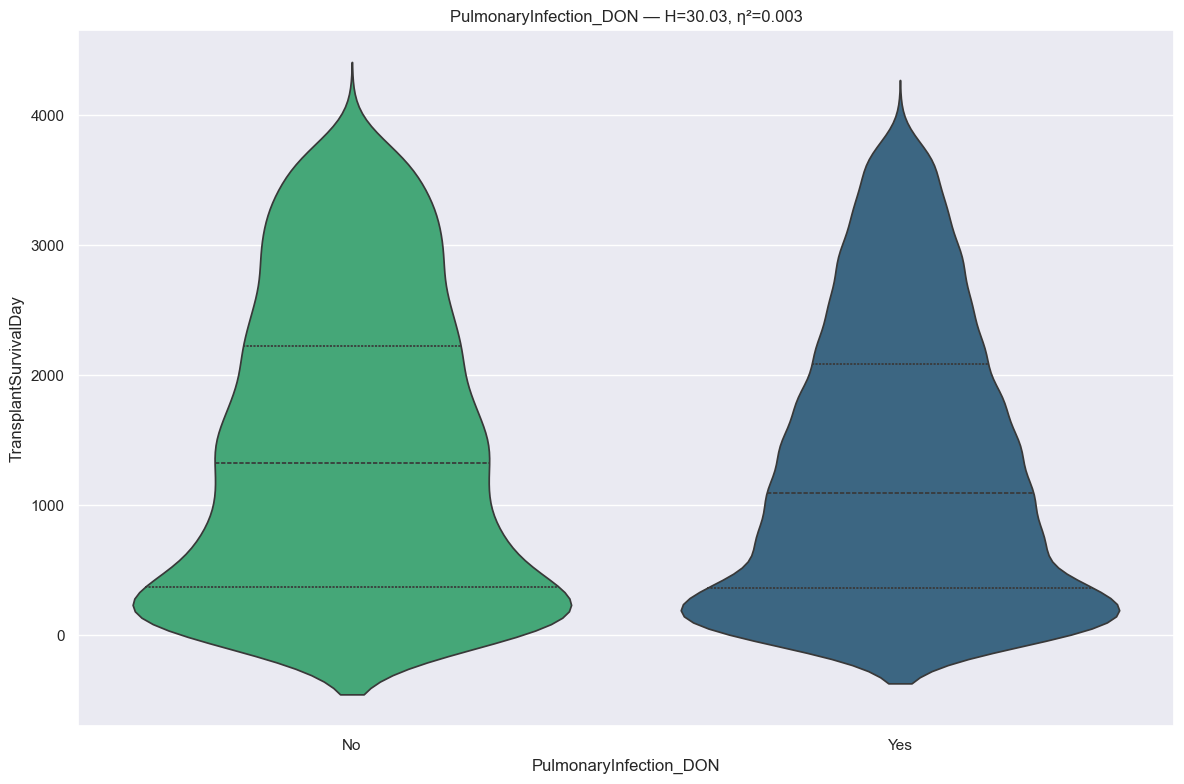

RANKING REPORT: PulmonaryInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2754 records
 * Yes                                               :   5564 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 30.0313 | P-value: 4.251273e-08 | Effect η²: 0.0035
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.2514e-08 | thr=0.0500 | r=-0.074 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

PulmonaryInfection_DON  mean_survival_days  m

In [93]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [94]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Urine Infection

In [95]:
# info
feature = u.get_feature_info(df, 'UrineInfection', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top  freq
UrineInfection_DON  8319      3  No  6211

:::: NaN Count:
UrineInfection_DON    0 



{'UrineInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

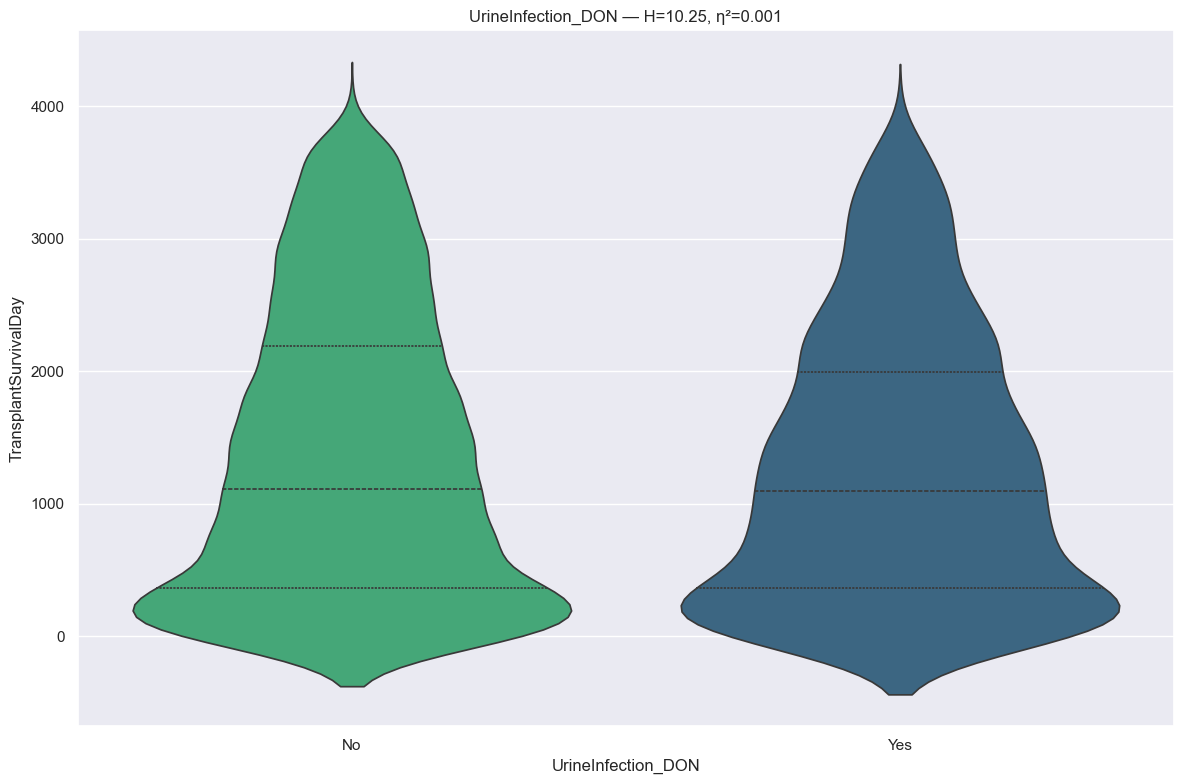

RANKING REPORT: UrineInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6211 records
 * Yes                                               :   2107 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 10.2458 | P-value: 1.369935e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.3700e-03 | thr=0.0500 | r=-0.047 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

UrineInfection_DON  mean_survival_days  median_su

In [96]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [97]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Vasodilators

In [98]:
# info
feature = u.get_feature_info(df, 'Vasodilators', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique top  freq
Vasodilators_DON  8319      4  No  6944

:::: NaN Count:
Vasodilators_DON    0 



{'Vasodilators_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

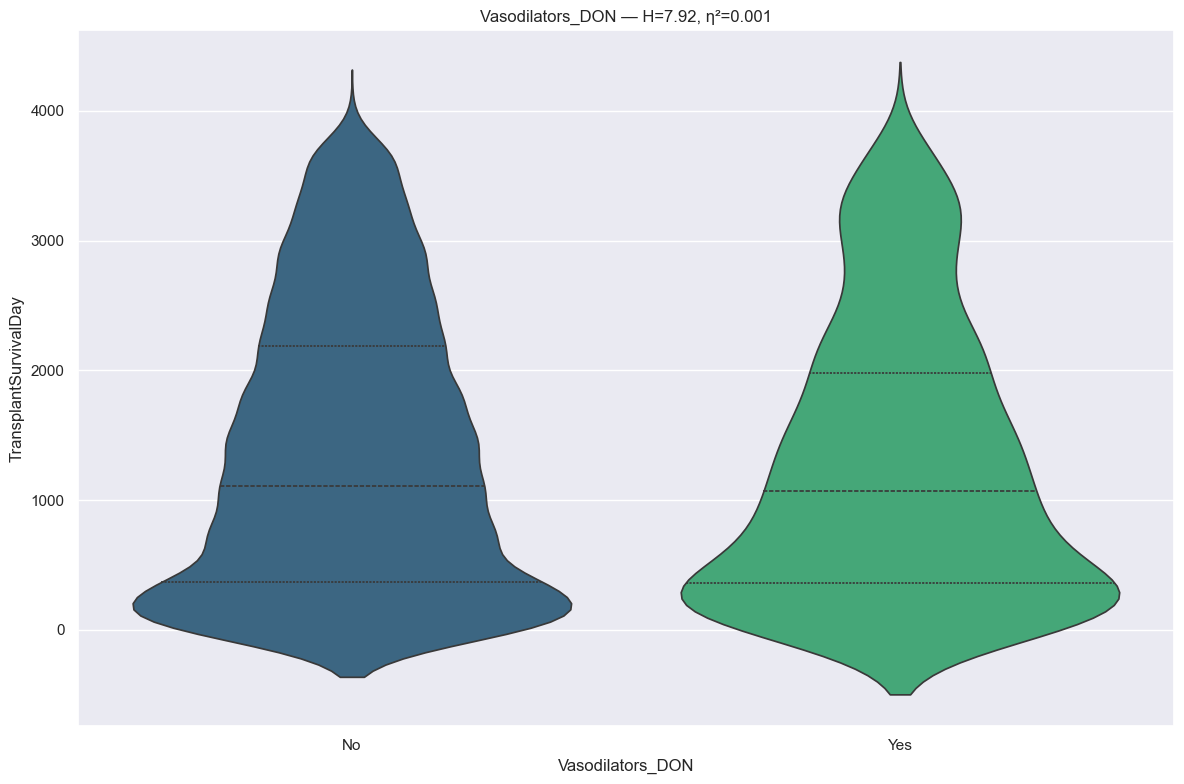

RANKING REPORT: Vasodilators_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6944 records
 * Yes                                               :   1357 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 7.9208 | P-value: 4.886913e-03 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.8870e-03 | thr=0.0500 | r=-0.048 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categor

In [99]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [100]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antibody Result RPR VDRL
* RPR (Rapid Plasma Reagin) and VDRL (Venereal Disease Research Laboratory) are essential non-treponemal screening tests used to detect active syphilis infection in both donors and recipients. A positive (reactive) RPR/VDRL result requires confirmation with a treponemal-specific test (such as TP-PA), as non-treponemal tests can yield false positives due to other conditions, including autoimmune disorders or infections.

In [101]:
# info
feature = u.get_feature_info(df, 'AntibodyResultRPR_VDRL', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                           count unique       top  freq
AntibodyResultRPR_VDRL_DON  8319      4  Negative  8077

:::: NaN Count:
AntibodyResultRPR_VDRL_DON    0 



{'AntibodyResultRPR_VDRL_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive'], ordered=False, categories_dtype=object)}

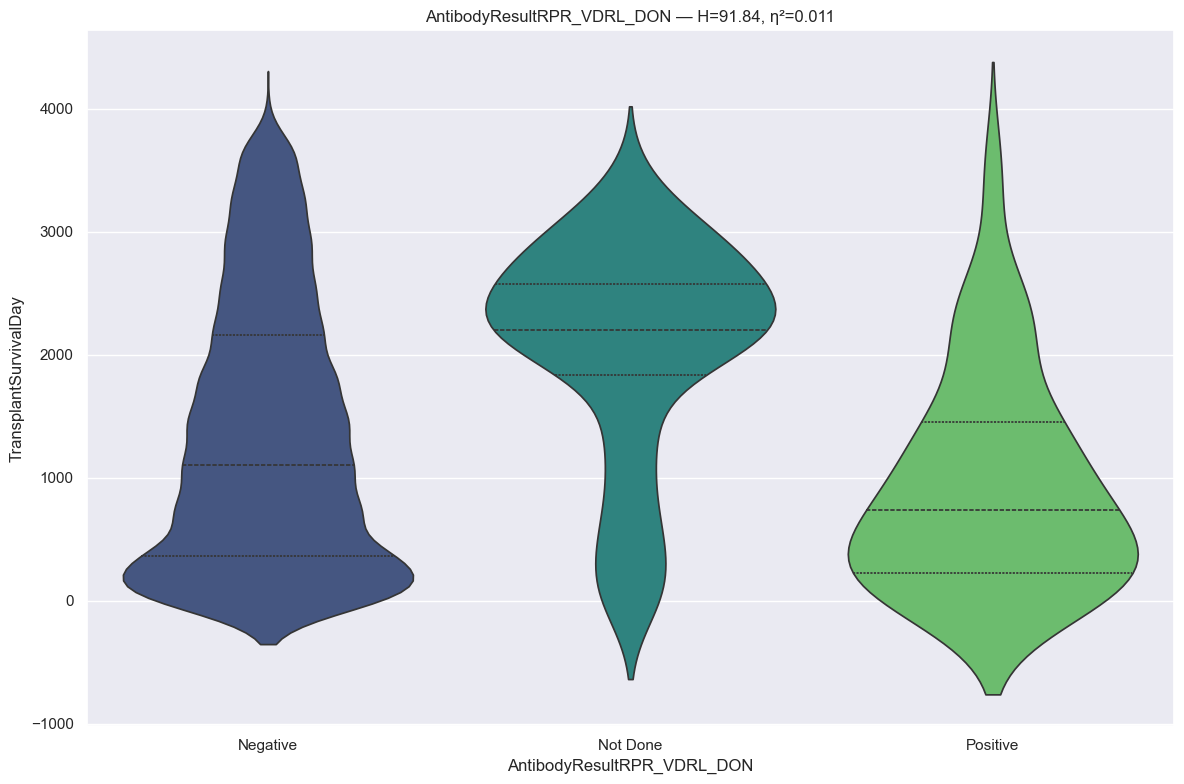

RANKING REPORT: AntibodyResultRPR_VDRL_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8077 records
 * Not Done                                          :    173 records
 * Positive                                          :     62 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 91.8443 | P-value: 1.138313e-20 | Effect η²: 0.0108
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=6.2060e-20 | thr=0.0167 | r= 0.406 | *Sig*
Not Done     vs Positive     | p=1.3373e-12 | thr=0.0167 | r=-0.607 | *Sig*
Negative     vs Positive     | p=5.6884e-03 | thr=0.0167 | r=-0.204 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::

In [102]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [103]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntibodyResultRPR_VDRL_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8077 records
 * Not Done                                          :    173 records
 * Positive                                          :     62 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 91.8443 | P-value: 1.138313e-20 | Effect η²: 0.0108
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

>>> Group_2 (1 categories)
  - Not Done

>>> Group_3 (1 categories)
  - Posi

In [104]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Infection Clinical

In [105]:
# info
feature = u.get_feature_info(df, 'InfectionClinical', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top  freq
InfectionClinical_DON  8319      4  Yes  6389

:::: NaN Count:
InfectionClinical_DON    0 



{'InfectionClinical_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

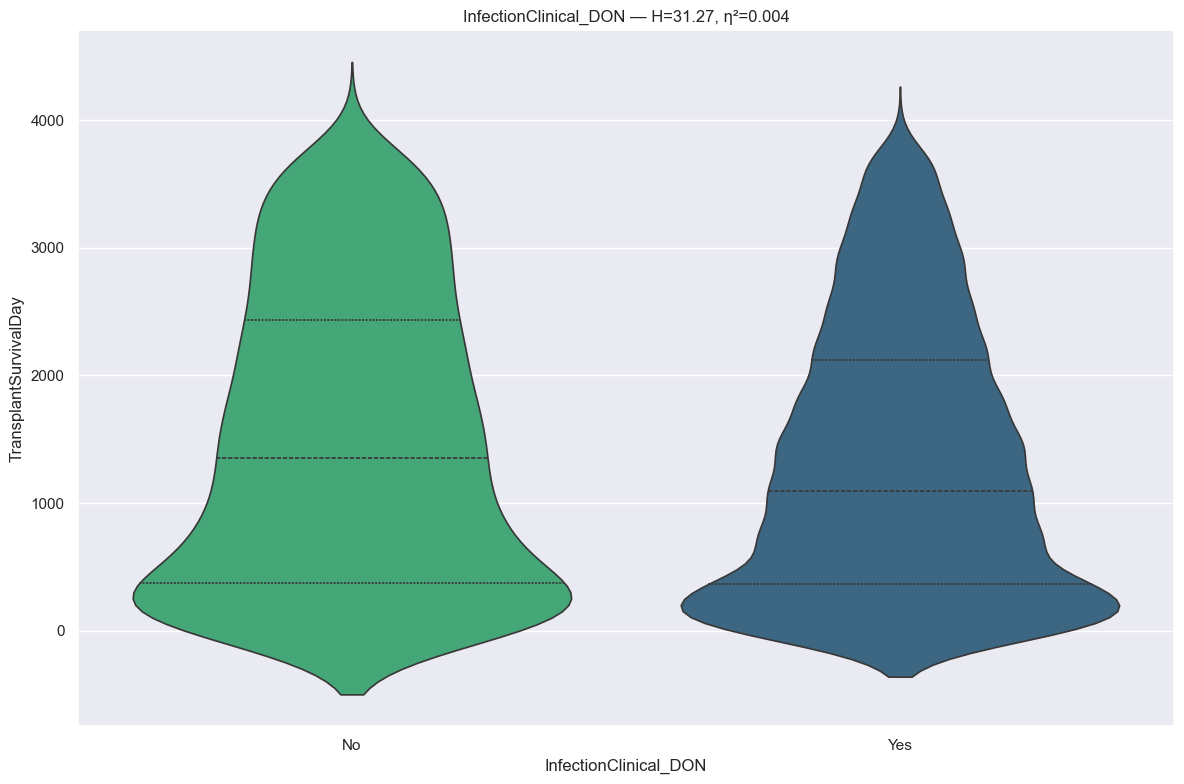

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   1890 records
 * Yes                                               :   6389 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     26 records
--------------------------------------------------------------------------------
Kruskal H: 31.2733 | P-value: 2.241387e-08 | Effect η²: 0.0037
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.2415e-08 | thr=0.0500 | r=-0.085 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 c

In [106]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [107]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cocaine Use

In [108]:
# info
feature = u.get_feature_info(df, 'CocaineUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique      top  freq
CocaineUse_DON      8319      4  Missing  6713
PastCocaineUse_DON  8319      3  Group_1  6699

:::: NaN Count:
CocaineUse_DON        0
PastCocaineUse_DON    0 



{'CocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastCocaineUse_DON': CategoricalDtype(categories=['Group_1', 'Group_2', 'Other'], ordered=False, categories_dtype=object)}

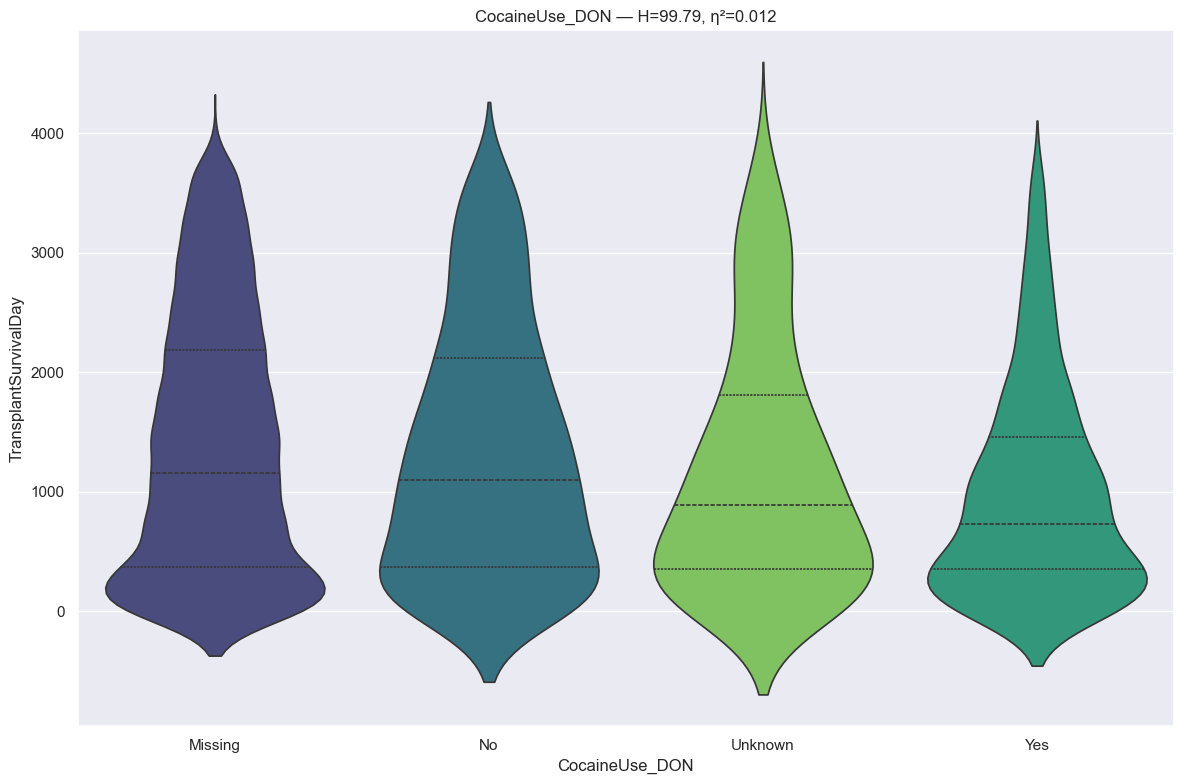

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6713 records
 * No                                                :    542 records
 * Unknown                                           :    215 records
 * Yes                                               :    849 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 99.7937 | P-value: 1.721303e-21 | Effect η²: 0.0116
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=2.5778e-22 | thr=0.0083 | r=-0.204 | *Sig*
No           vs Yes          | p=3.7157e-09 | thr=0.0083 | r=-0.187 | *Sig*
Missing      vs Unknown      | p=5.0142e-03 | thr=0.0083 | r=-0.112 | *Sig*
No           vs Unknown      | p=4.0936e-02 | thr=0.0083 | r=-0.095 | Not Sig
Unknown 

In [109]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [110]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6713 records
 * No                                                :    542 records
 * Unknown                                           :    215 records
 * Yes                                               :    849 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 99.7937 | P-value: 1.721303e-21 | Effect η²: 0.0116
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (4 categories)
  - Missing
  - No
  - Unknown
  - Yes



In [111]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but it becomes non-informative and should be treated as a single-level variable. There is no remaining category structure that survives your r‑threshold, so the feature has no usable variation left.

#### Other Drug Use

In [112]:
# info
feature = u.get_feature_info(df, 'OtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique      top  freq
OtherDrugUse_DON      8319      4  Missing  4406
PastOtherDrugUse_DON  8319      4       No  4317

:::: NaN Count:
OtherDrugUse_DON        0
PastOtherDrugUse_DON    0 



{'OtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

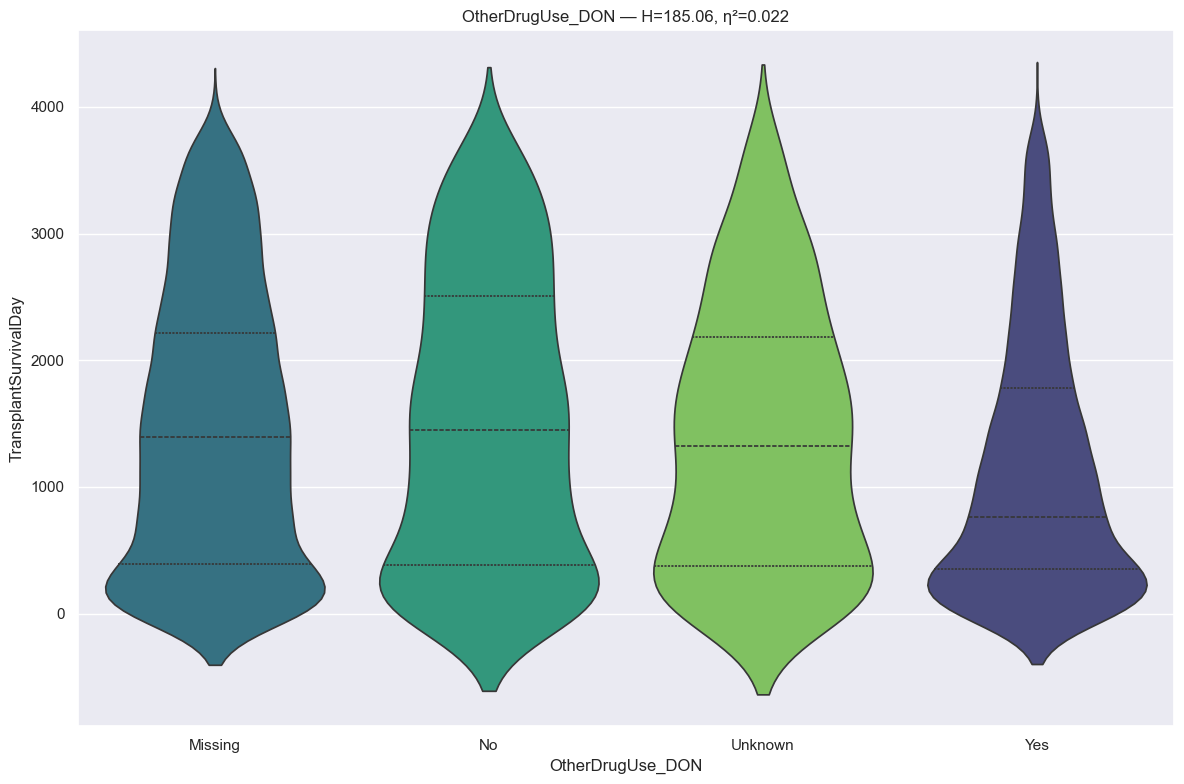

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   4406 records
 * No                                                :    685 records
 * Unknown                                           :    348 records
 * Yes                                               :   2880 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 185.0556 | P-value: 7.138551e-40 | Effect η²: 0.0219
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=3.3164e-39 | thr=0.0083 | r=-0.181 | *Sig*
No           vs Yes          | p=1.7121e-14 | thr=0.0083 | r=-0.188 | *Sig*
Unknown      vs Yes          | p=2.8225e-06 | thr=0.0083 | r=-0.153 | *Sig*
No           vs Unknown      | p=2.0133e-01 | thr=0.0083 | r=-0.049 | Not Sig
Missi

In [113]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [114]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   4406 records
 * No                                                :    685 records
 * Unknown                                           :    348 records
 * Yes                                               :   2880 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 185.0556 | P-value: 7.138551e-40 | Effect η²: 0.0219
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (3 categories)
  - Missing
  - No
  - Unknown

>>> Group_2 (1 categories)
  - Yes



In [115]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer ExtraCranial

In [116]:
# info
feature = u.get_feature_info(df, 'CancerExtraCranial', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top  freq
CancerExtraCranial_DON  8319      4  No  8251

:::: NaN Count:
CancerExtraCranial_DON    0 



{'CancerExtraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

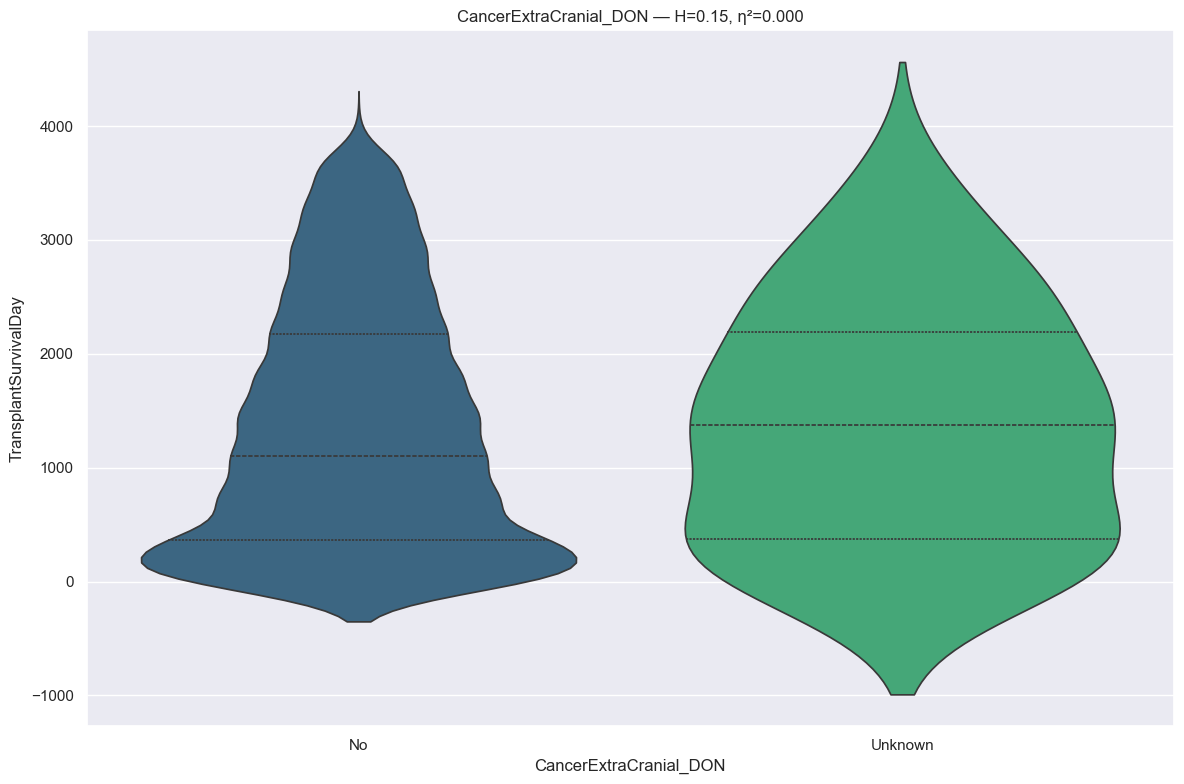

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8251 records
 * Unknown                                           :     40 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :     14 records
--------------------------------------------------------------------------------
Kruskal H: 0.1492 | P-value: 6.992859e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=6.9931e-01 | thr=0.0500 | r= 0.035 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (2 categories)
  - Missing

In [117]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [118]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "suppress_pairwise": False}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8251 records
 * Unknown                                           :     40 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :     14 records
--------------------------------------------------------------------------------
Kruskal H: 0.1492 | P-value: 6.992859e-01 | Effect η²: 0.0000
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=6.9931e-01 | thr=0.0500 | r= 0.035 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (2 categories)
  - Missin

In [119]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer Site

In [120]:
# info
feature = u.get_feature_info(df, 'CancerSite', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
CancerSite_DON  8319     22  NO  8068

:::: NaN Count:
CancerSite_DON    0 



{'CancerSite_DON': CategoricalDtype(categories=['BREAST', 'CNS TUMOR - ASTROCYTOMA',
                   'CNS TUMOR - GLIOBLASTOMA MULTIFORME',
                   'CNS TUMOR - MEDULLOBLASTOMA', 'CNS TUMOR - MENINGIOMA',
                   'CNS TUMOR - NEUROBLASTOMA', 'CNS TUMOR - OTHER',
                   'GASTROINTESTINAL - COLO-RECTAL',
                   'GASTROINTESTINAL - STOMACH', 'GENITOURINARY - BLADDER',
                   'GENITOURINARY - KIDNEY', 'GENITOURINARY - OVARIAN',
                   'GENITOURINARY - PENIS, TESTICULAR',
                   'GENITOURINARY - PROSTATE', 'GENITOURINARY - UNKNOWN',
                   'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA',
                   'GENITOURINARY - UTERINE BODY ENDOMETRIAL',
                   'GENITOURINARY - UTERINE CERVIX', 'GENITOURINARY - VULVA',
                   'LEUKEMIA/LYMPHOMA', 'Missing', 'NO', 'OTHER, SPECIFY',
                   'SKIN - MELANOMA', 'SKIN - SQUAMOUS, BASAL CELL', 'THYROID',
                  

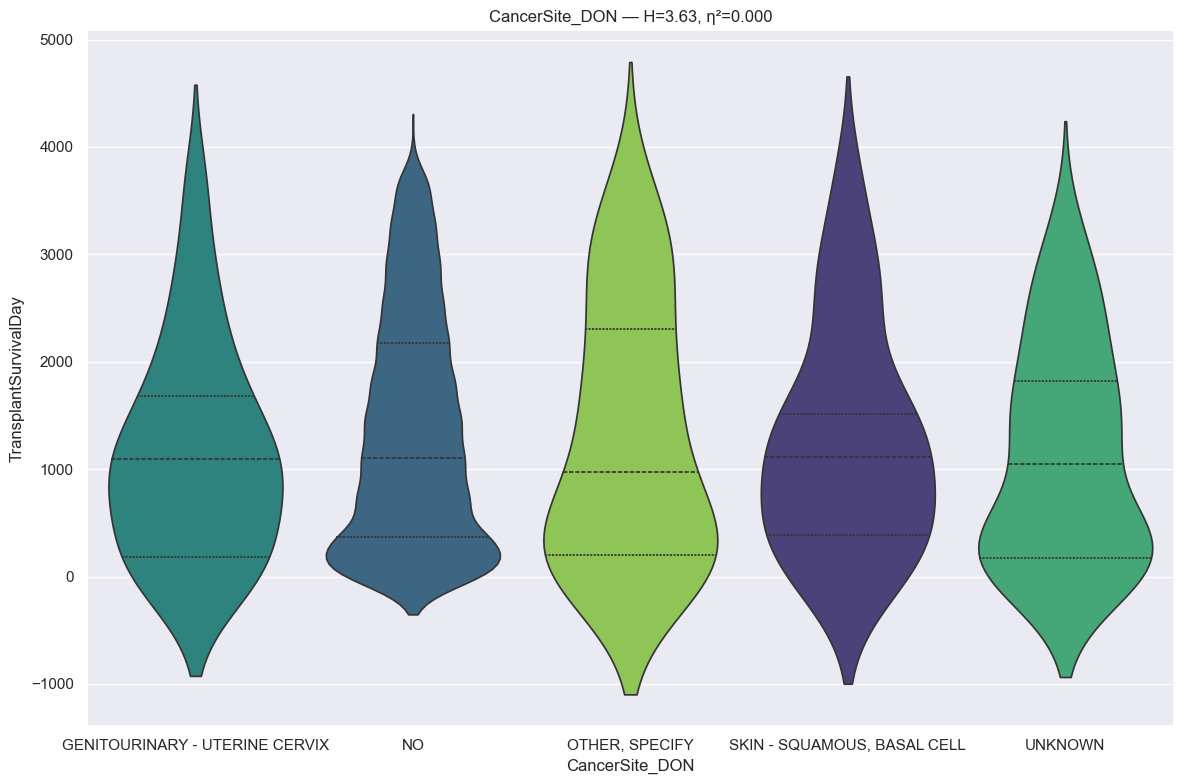

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * GENITOURINARY - UTERINE CERVIX                    :     44 records
 * NO                                                :   8068 records
 * OTHER, SPECIFY                                    :     45 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     38 records
 * UNKNOWN                                           :     46 records
BYPASSED CATEGORIES (n < min_n):
 * BREAST                                            :     10 records
 * CNS TUMOR - ASTROCYTOMA                           :      3 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :      3 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :     16 records
 * CNS TUMOR - NEUROBLASTOMA                         :      2 records
 * CNS TUMOR - OTHER                                 :      5 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      1 reco

In [121]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [122]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * GENITOURINARY - UTERINE CERVIX                    :     44 records
 * NO                                                :   8068 records
 * OTHER, SPECIFY                                    :     45 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     38 records
 * UNKNOWN                                           :     46 records
BYPASSED CATEGORIES (n < min_n):
 * BREAST                                            :     10 records
 * CNS TUMOR - ASTROCYTOMA                           :      3 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :      3 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :     16 records
 * CNS TUMOR - NEUROBLASTOMA                         :      2 records
 * CNS TUMOR - OTHER                                 :      5 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      1 reco

In [123]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect.

#### Cigarette History

In [124]:
# info
feature = u.get_feature_info(df, 'CigaretteHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
CigaretteHistory_DON  8319      4  No  7157

:::: NaN Count:
CigaretteHistory_DON    0 



{'CigaretteHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

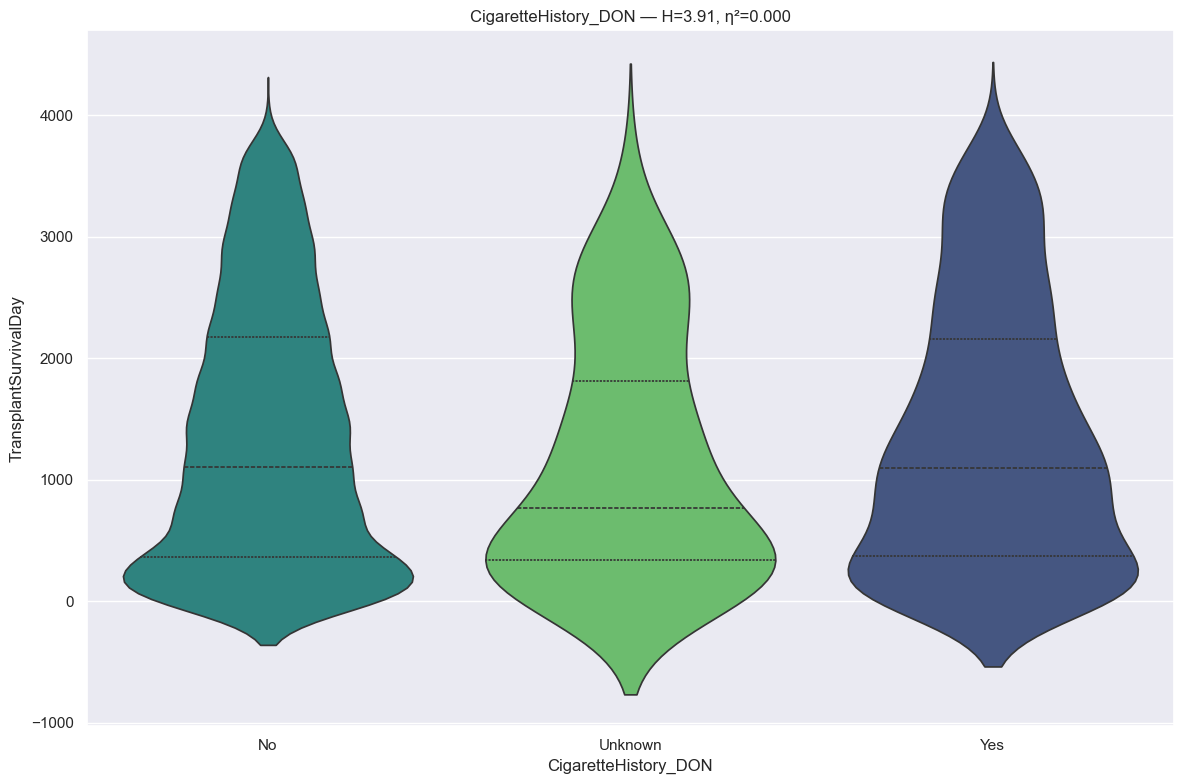

RANKING REPORT: CigaretteHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7157 records
 * Unknown                                           :    117 records
 * Yes                                               :   1044 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.9078 | P-value: 1.417221e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=5.0160e-02 | thr=0.0167 | r=-0.105 | Not Sig
Unknown      vs Yes          | p=8.2303e-02 | thr=0.0167 | r= 0.098 | Not Sig
No           vs Yes          | p=7.1519e-01 | thr=0.0167 | r=-0.007 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::

In [125]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [126]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CigaretteHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7157 records
 * Unknown                                           :    117 records
 * Yes                                               :   1044 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.9078 | P-value: 1.417221e-01 | Effect η²: 0.0002
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (3 categories)
  - No
  - Unknown
  - Yes

>>> Other (1 categories)
  - Missing



In [127]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect, and no clinical interpretation, since Yes and No are grouped together.

#### Hypertension History

In [128]:
# info
feature = u.get_feature_info(df, 'HypertensionHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique top  freq
HypertensionHistory_DON  8319      4  No  6590

:::: NaN Count:
HypertensionHistory_DON    0 



{'HypertensionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

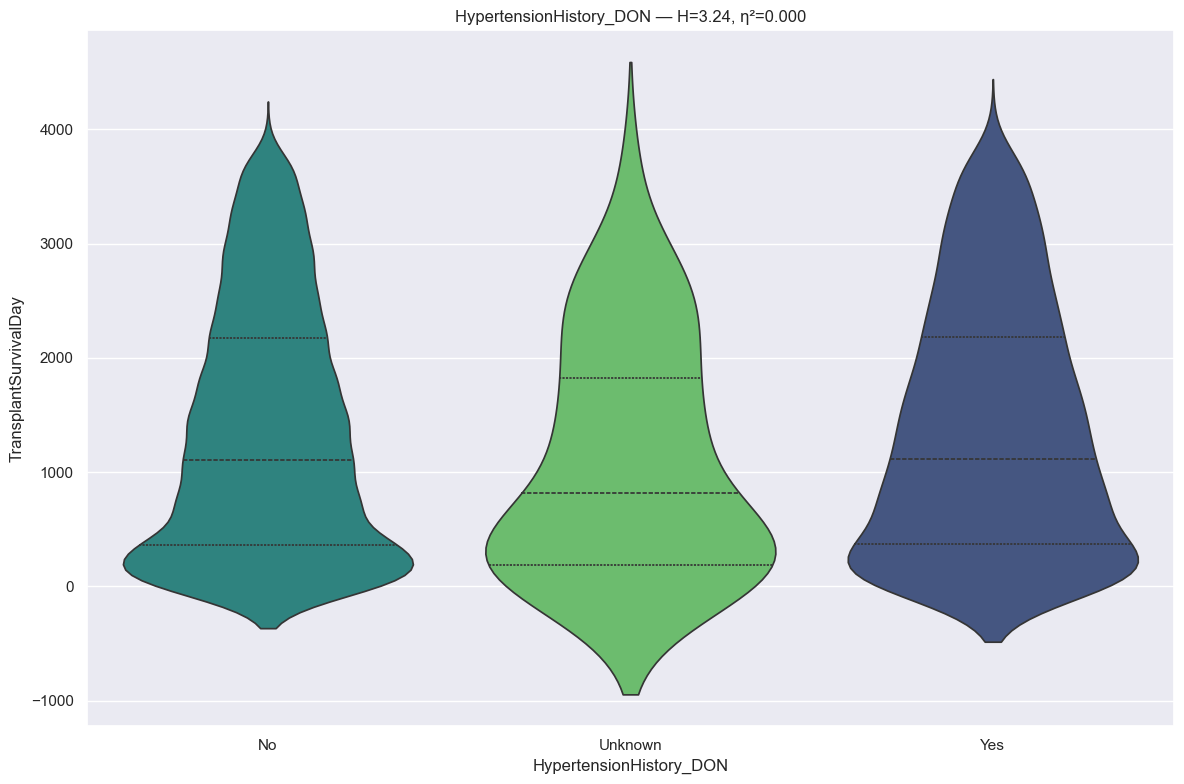

RANKING REPORT: HypertensionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6590 records
 * Unknown                                           :     46 records
 * Yes                                               :   1682 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.2413 | P-value: 1.977672e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=1.1537e-01 | thr=0.0167 | r= 0.136 | Not Sig
No           vs Unknown      | p=1.5753e-01 | thr=0.0167 | r=-0.121 | Not Sig
No           vs Yes          | p=2.8598e-01 | thr=0.0167 | r= 0.017 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::::::

In [129]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [130]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect, and no clinical interpretation, since Yes and No are grouped together.

#### Cancer Intra Cranial

In [131]:
# info
feature = u.get_feature_info(df, 'CancerIntraCranial', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top  freq
CancerIntraCranial_DON  8319      4  No  8238

:::: NaN Count:
CancerIntraCranial_DON    0 



{'CancerIntraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

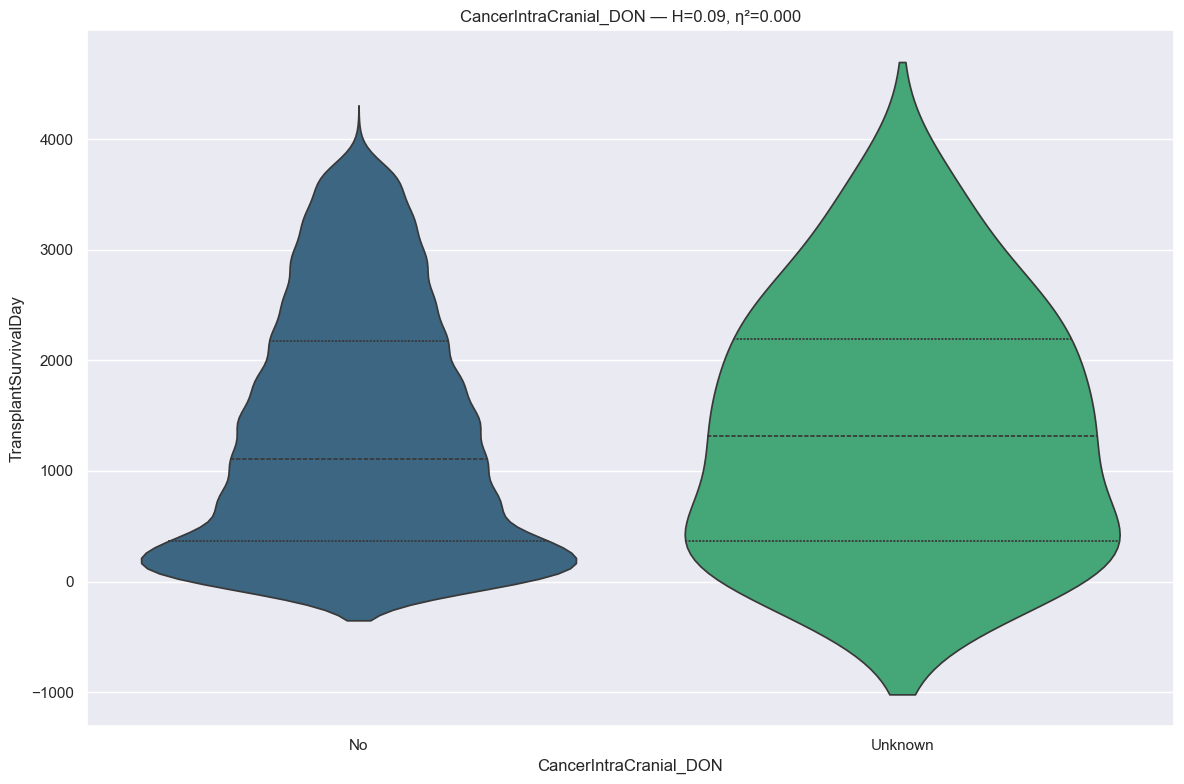

RANKING REPORT: CancerIntraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8238 records
 * Unknown                                           :     44 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :     23 records
--------------------------------------------------------------------------------
Kruskal H: 0.0909 | P-value: 7.630091e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=7.6303e-01 | thr=0.0500 | r= 0.026 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (2 categories)
  - Missing

In [132]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [133]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer History

In [134]:
# info
feature = u.get_feature_info(df, 'CancerHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique top  freq
CancerHistory_DON  8319      4  No  8068

:::: NaN Count:
CancerHistory_DON    0 



{'CancerHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

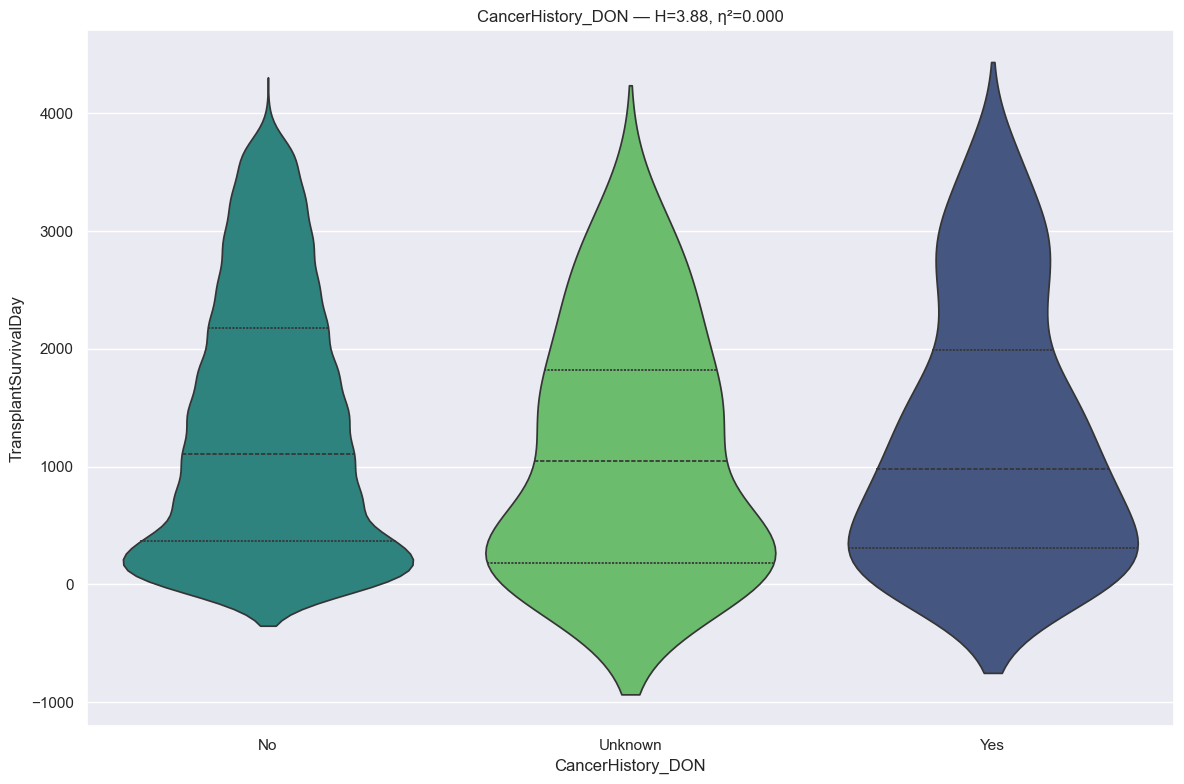

RANKING REPORT: CancerHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8068 records
 * Unknown                                           :     46 records
 * Yes                                               :    201 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 3.8837 | P-value: 1.434403e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.5358e-01 | thr=0.0167 | r=-0.122 | Not Sig
No           vs Yes          | p=1.6863e-01 | thr=0.0167 | r=-0.057 | Not Sig
Unknown      vs Yes          | p=5.2778e-01 | thr=0.0167 | r= 0.060 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

::::::::::::::

In [135]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [136]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but it becomes non-informative and should be treated as a single-level variable. There is no remaining category structure that survives your r‑threshold, so the feature has no usable variation left.

#### Diabetes History

In [137]:
# info
feature = u.get_feature_info(df, 'DiabetesHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
DiabetesHistory_DON  8319      7  No  7855

:::: NaN Count:
DiabetesHistory_DON    0 



{'DiabetesHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes, 0-5 Years',
                   'Yes, 6-10 Years', 'Yes, >10 Years',
                   'Yes, Duration Unknown'],
 , ordered=False, categories_dtype=object)}

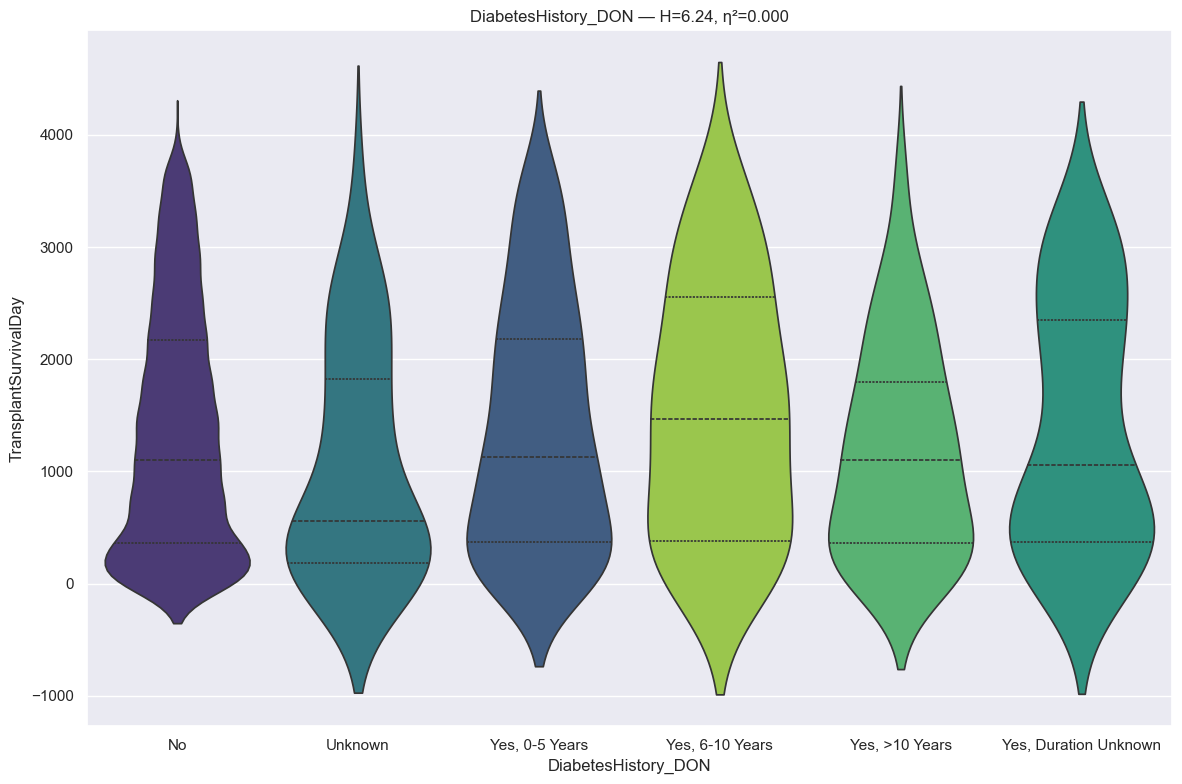

RANKING REPORT: DiabetesHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7855 records
 * Unknown                                           :     41 records
 * Yes, 0-5 Years                                    :    225 records
 * Yes, 6-10 Years                                   :     53 records
 * Yes, >10 Years                                    :     90 records
 * Yes, Duration Unknown                             :     54 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 6.2397 | P-value: 2.835848e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes, 6-10 Years | p=4.0271e-02 | thr=0.0033 | r= 0.248 | Not Sig
Yes, 6-10 Ye

In [138]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [139]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

  DiabetesHistory_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                   No         1338.060344                1105.0                 3956.0                    0.0          7855
       Yes, 0-5 Years         1391.302222                1124.0                 3657.0                    1.0           225
       Yes, >10 Years         1186.611111                1101.0                 3672.0                    2.0            90
Yes, Duration Unknown         1402.777778                1058.0                 3302.0                   12.0            54
      Yes, 6-10 Years         1536.792453                1464.0                 3651.0                   11.0            53
                Other         1093.976190                 600.0                 3645.0                    0.0            42


In [140]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: DiabetesHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7855 records
 * Other                                             :     42 records
 * Yes, 0-5 Years                                    :    225 records
 * Yes, 6-10 Years                                   :     53 records
 * Yes, >10 Years                                    :     90 records
 * Yes, Duration Unknown                             :     54 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 5.8512 | P-value: 3.209640e-01 | Effect η²: 0.0001
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::

In [141]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect.

#### Diabetes

In [142]:
# info
feature = u.get_feature_info(df, 'Diabetes_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

             count unique top  freq
Diabetes_DON  8319      4  No  7855

:::: NaN Count:
Diabetes_DON    0 



{'Diabetes_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

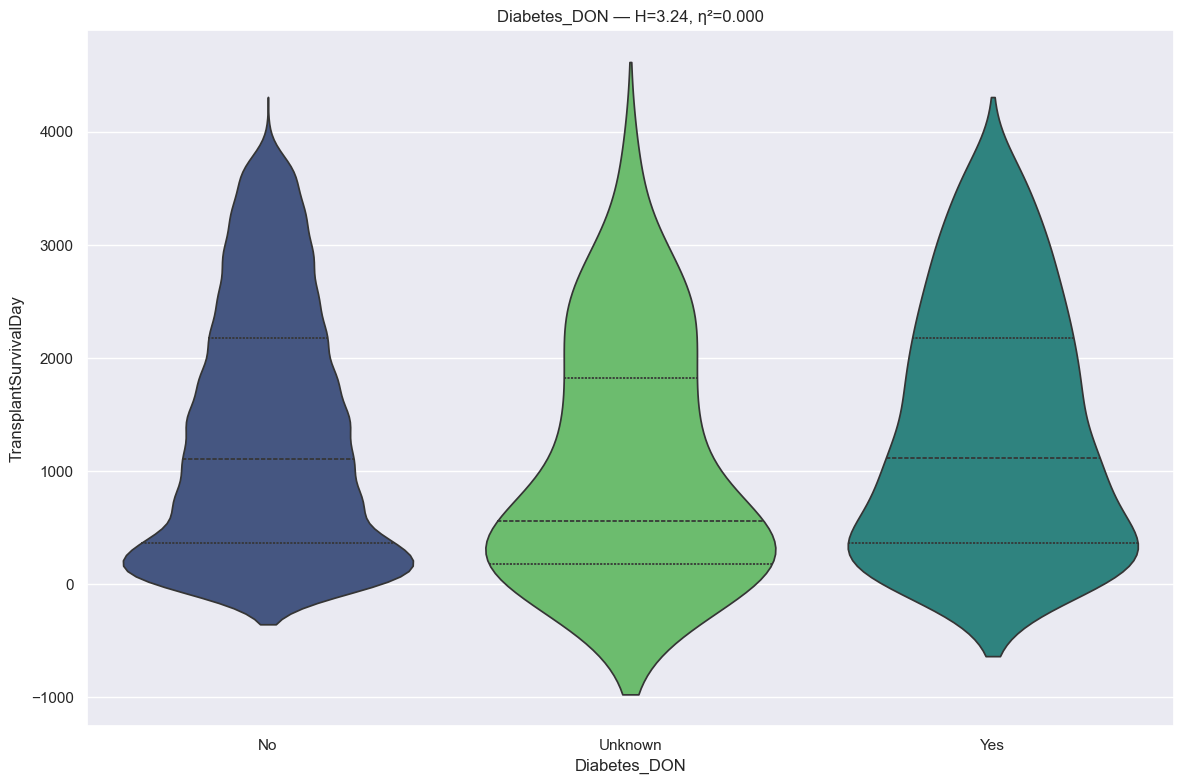

RANKING REPORT: Diabetes_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7855 records
 * Unknown                                           :     41 records
 * Yes                                               :    422 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.2419 | P-value: 1.977061e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=7.6672e-02 | thr=0.0167 | r= 0.167 | Not Sig
No           vs Unknown      | p=9.7718e-02 | thr=0.0167 | r=-0.150 | Not Sig
No           vs Yes          | p=4.9486e-01 | thr=0.0167 | r= 0.020 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::

In [143]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [144]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect.

#### Past Other Drug Use

In [145]:
# info
feature = u.get_feature_info(df, 'PastOtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
PastOtherDrugUse_DON  8319      4  No  4317

:::: NaN Count:
PastOtherDrugUse_DON    0 



{'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

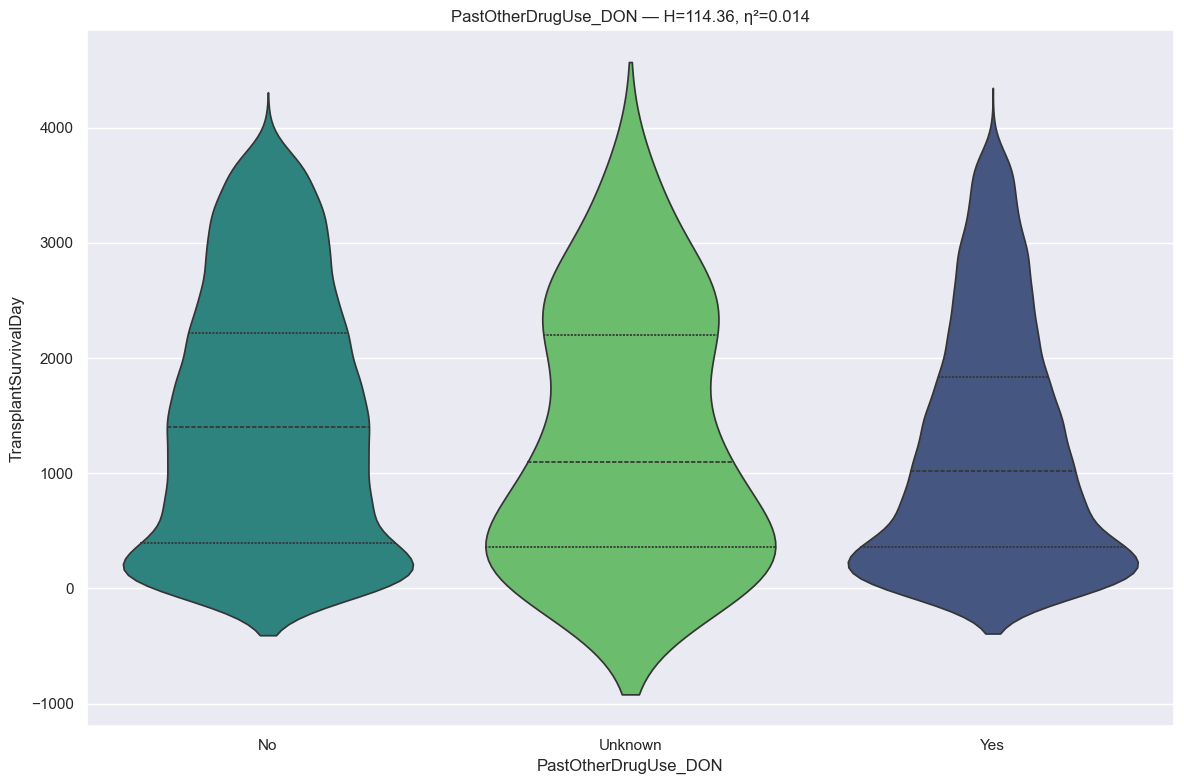

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4317 records
 * Unknown                                           :     75 records
 * Yes                                               :   3913 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 114.3571 | P-value: 1.471215e-25 | Effect η²: 0.0135
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.1862e-26 | thr=0.0167 | r=-0.136 | *Sig*
No           vs Unknown      | p=1.4700e-01 | thr=0.0167 | r=-0.098 | Not Sig
Unknown      vs Yes          | p=6.5872e-01 | thr=0.0167 | r=-0.030 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::

In [146]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [147]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but Yes and No are grouped together.

#### Cancer Skin

In [148]:
# info
feature = u.get_feature_info(df, 'CancerSkin', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique top  freq
CancerSkin_DON  8319      4  No  8258

:::: NaN Count:
CancerSkin_DON    0 



{'CancerSkin_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

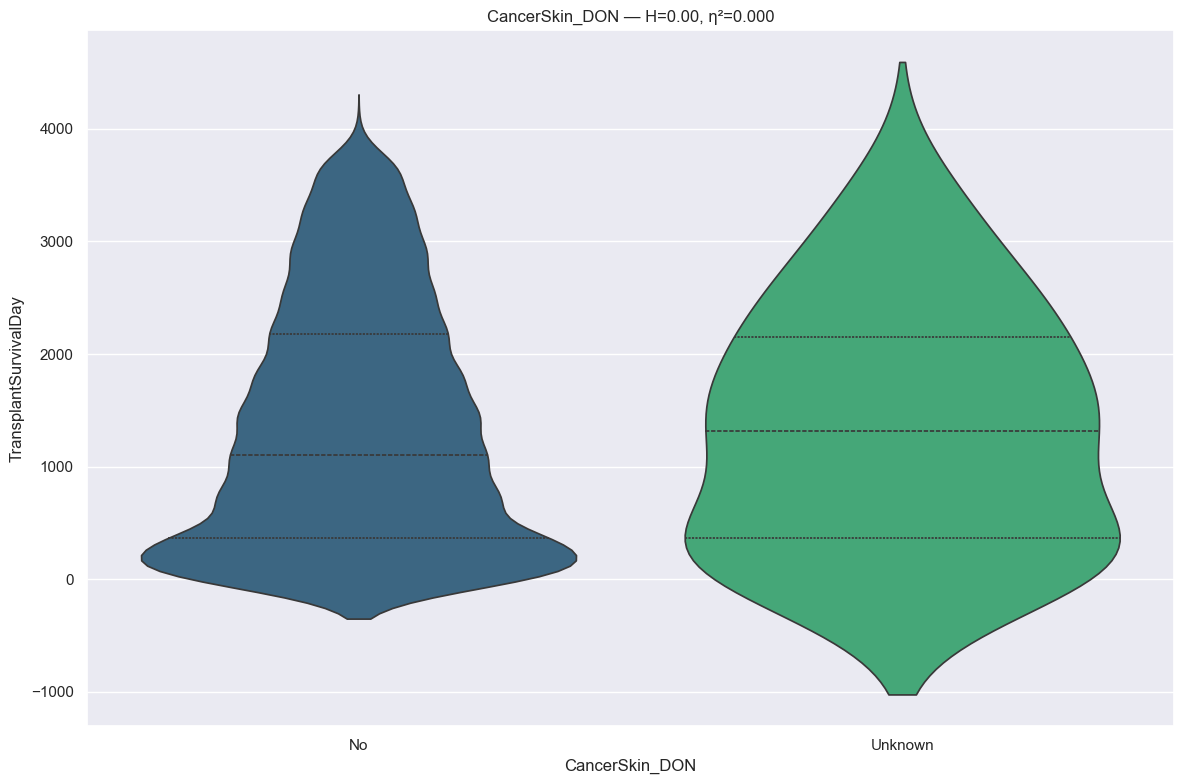

RANKING REPORT: CancerSkin_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8258 records
 * Unknown                                           :     38 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :      9 records
--------------------------------------------------------------------------------
Kruskal H: 0.0006 | P-value: 9.799059e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=9.7993e-01 | thr=0.0500 | r=-0.002 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Unknown

>>> Other (2 categories)
  - Missing
  - Yes

In [149]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [150]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Serology Anti CMV

In [151]:
# info
feature = u.get_feature_info(df, 'SerologyAntiCMV', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top  freq
SerologyAntiCMV_DON  8319      5  Positive  5651

:::: NaN Count:
SerologyAntiCMV_DON    0 



{'SerologyAntiCMV_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

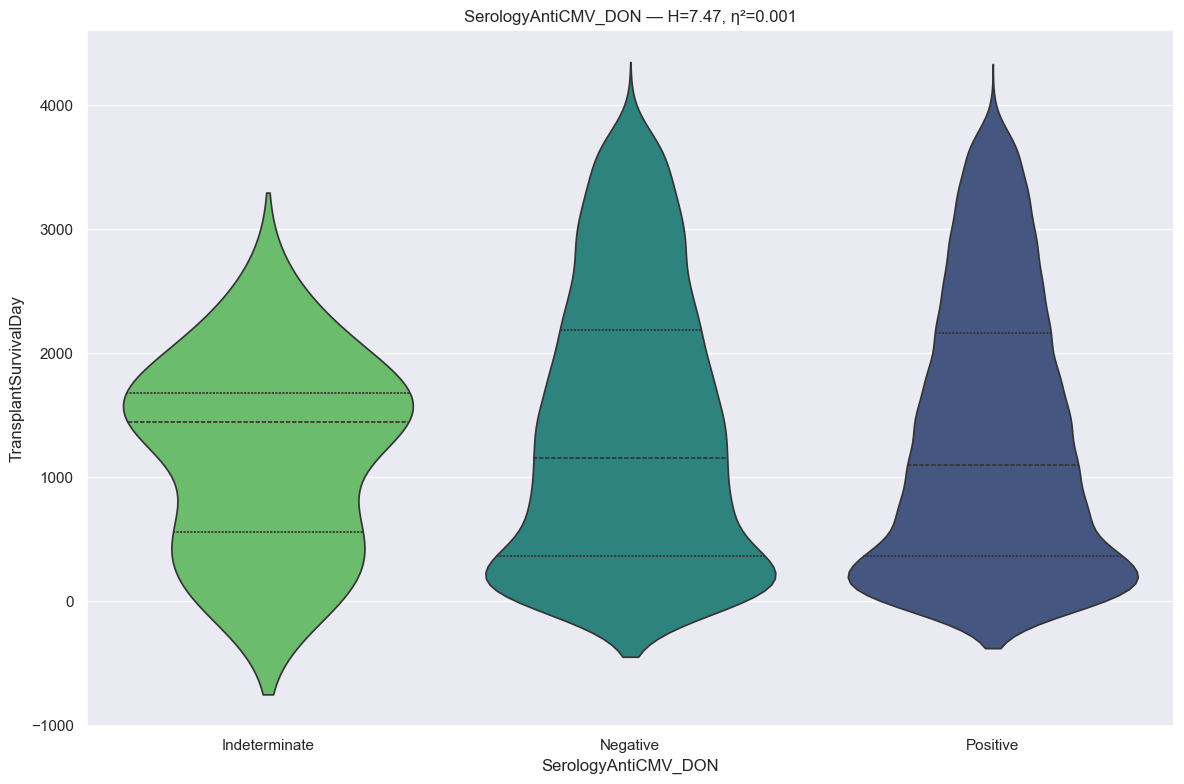

RANKING REPORT: SerologyAntiCMV_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     30 records
 * Negative                                          :   2628 records
 * Positive                                          :   5651 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
 * Not Done                                          :      7 records
--------------------------------------------------------------------------------
Kruskal H: 7.4714 | P-value: 2.385595e-02 | Effect η²: 0.0007
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=7.1413e-03 | thr=0.0167 | r=-0.037 | *Sig*
Indeterminate vs Negative     | p=4.5574e-01 | thr=0.0167 | r= 0.079 | Not Sig
Indeterminate vs Positive     | p=7.2758e-01 | thr=0.0167 | r= 0.037 | Not Sig

In [152]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [153]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: SerologyAntiCMV_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     30 records
 * Negative                                          :   2628 records
 * Positive                                          :   5651 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
 * Not Done                                          :      7 records
--------------------------------------------------------------------------------
Kruskal H: 7.4714 | P-value: 2.385595e-02 | Effect η²: 0.0007
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (3 categories)
  - Indeterminate
  - Negati

In [154]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect, and has an underpowered sample size.

#### Cause Of Death

In [155]:
# info
feature = u.get_feature_info(df, 'CauseOfDeath', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique     top  freq
CauseOfDeath_DON  8319      6  ANOXIA  3503

:::: NaN Count:
CauseOfDeath_DON    0 



{'CauseOfDeath_DON': CategoricalDtype(categories=['ANOXIA', 'CEREBROVASCULAR/STROKE', 'CNS TUMOR',
                   'HEAD TRAUMA', 'Missing', 'OTHER SPECIFY'],
 , ordered=False, categories_dtype=object)}

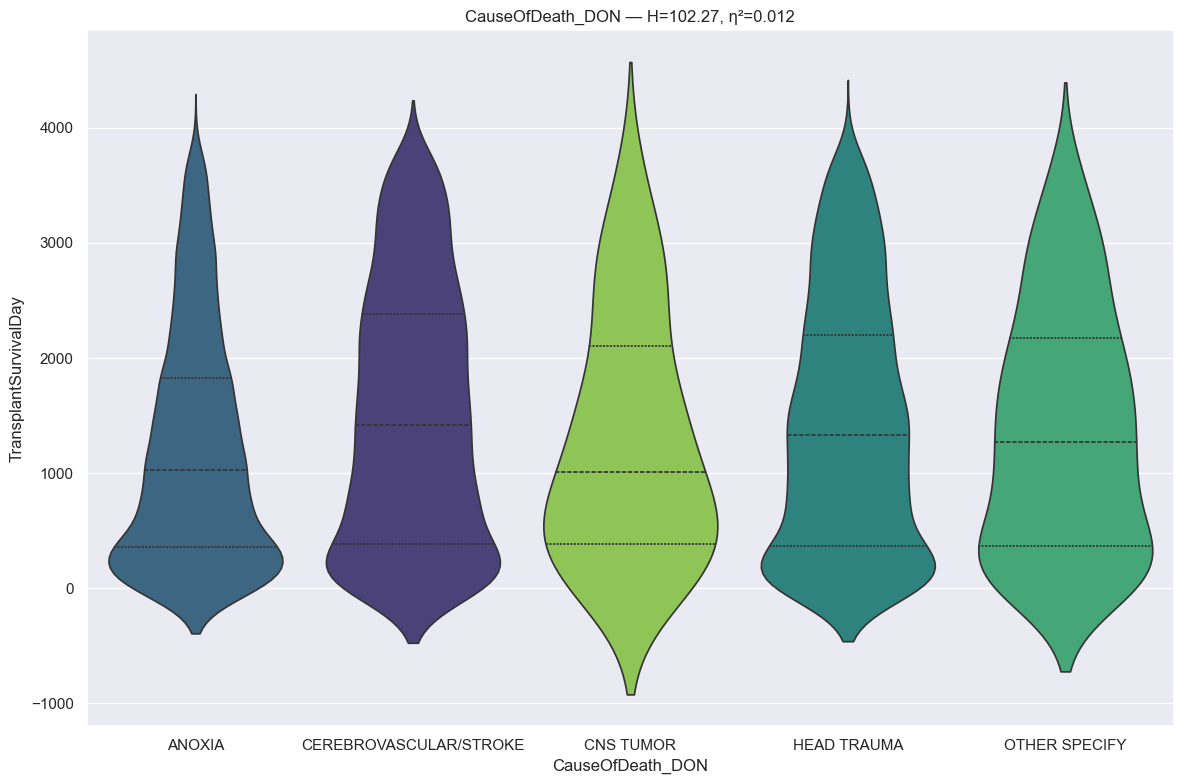

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3503 records
 * CEREBROVASCULAR/STROKE                            :   2227 records
 * CNS TUMOR                                         :     57 records
 * HEAD TRAUMA                                       :   2327 records
 * OTHER SPECIFY                                     :    204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 102.2651 | P-value: 3.239786e-21 | Effect η²: 0.0118
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.5118e-20 | thr=0.0050 | r= 0.145 | *Sig*
ANOXIA       vs HEAD TRAUMA  | p=4.0058e-13 | thr=0.0050 | r= 0.112 | *Sig*
AN

In [156]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [157]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3503 records
 * CEREBROVASCULAR/STROKE                            :   2227 records
 * CNS TUMOR                                         :     57 records
 * HEAD TRAUMA                                       :   2327 records
 * OTHER SPECIFY                                     :    204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 102.2651 | P-value: 3.239786e-21 | Effect η²: 0.0118
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::

In [158]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3503 records
 * CEREBROVASCULAR/STROKE                            :   2227 records
 * CNS TUMOR                                         :     57 records
 * HEAD TRAUMA                                       :   2327 records
 * OTHER SPECIFY                                     :    204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 102.2651 | P-value: 3.239786e-21 | Effect η²: 0.0118
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::

In [159]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Death Mechanism

In [160]:
# info
feature = u.get_feature_info(df, 'DeathMechanism', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique                             top  freq
DeathMechanism_DON  8319     13  INTRACRANIAL HEMORRHAGE/STROKE  2265

:::: NaN Count:
DeathMechanism_DON    0 



{'DeathMechanism_DON': CategoricalDtype(categories=['ASPHYXIATION', 'BLUNT INJURY', 'CARDIOVASCULAR',
                   'DEATH FROM NATURAL CAUSES', 'DROWNING', 'DRUG INTOXICATION',
                   'ELECTRICAL', 'GUNSHOT WOUND',
                   'INTRACRANIAL HEMORRHAGE/STROKE', 'Missing',
                   'NONE OF THE ABOVE', 'SEIZURE', 'STAB'],
 , ordered=False, categories_dtype=object)}

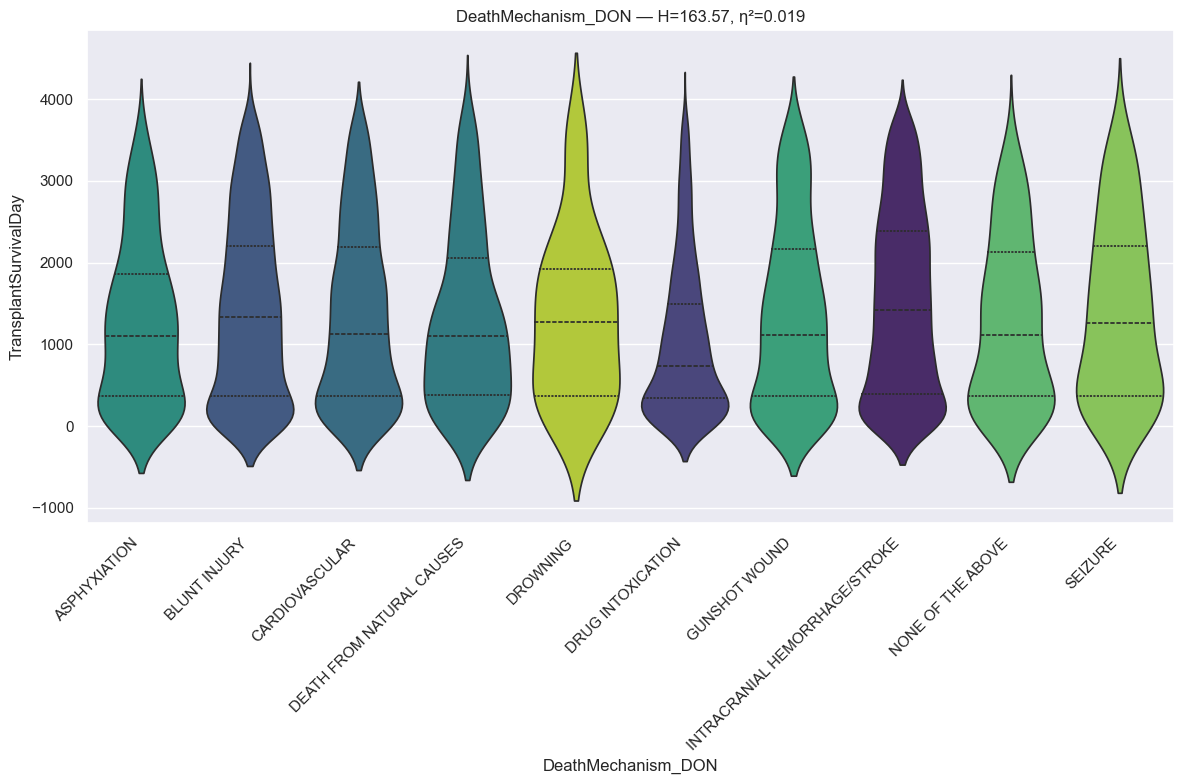

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    508 records
 * BLUNT INJURY                                      :   1682 records
 * CARDIOVASCULAR                                    :    946 records
 * DEATH FROM NATURAL CAUSES                         :    300 records
 * DROWNING                                          :     57 records
 * DRUG INTOXICATION                                 :   1616 records
 * GUNSHOT WOUND                                     :    593 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2265 records
 * NONE OF THE ABOVE                                 :    221 records
 * SEIZURE                                           :    120 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * Missing                                           :      3 records
 * STAB                                              :      7 

In [161]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [162]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    508 records
 * BLUNT INJURY                                      :   1682 records
 * CARDIOVASCULAR                                    :    946 records
 * DEATH FROM NATURAL CAUSES                         :    300 records
 * DROWNING                                          :     57 records
 * DRUG INTOXICATION                                 :   1616 records
 * GUNSHOT WOUND                                     :    593 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2265 records
 * NONE OF THE ABOVE                                 :    221 records
 * SEIZURE                                           :    120 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * Missing                                           :      3 records
 * STAB                                              :      7 

In [163]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Heparin Management

In [164]:
# info
feature = u.get_feature_info(df, 'HeparinManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top  freq
HeparinManagement_DON  8319      3  Yes  8179

:::: NaN Count:
HeparinManagement_DON    0 



{'HeparinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

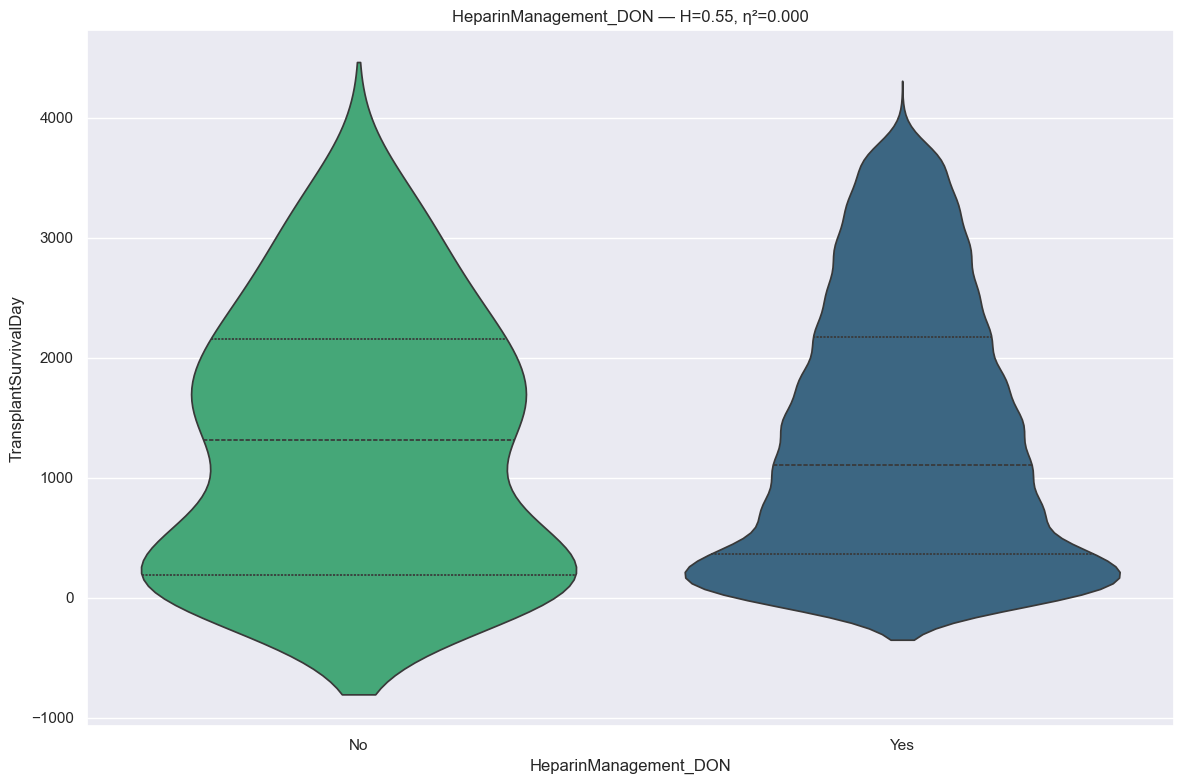

RANKING REPORT: HeparinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    126 records
 * Yes                                               :   8179 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 0.5522 | P-value: 4.574247e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.5744e-01 | thr=0.0500 | r= 0.039 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Missing

HeparinManagement_DON  mean_survival_days  median_survival_days  maximum_

In [165]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [166]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but no clinical interpretation value.

#### Arginnie Management

In [167]:
# info
feature = u.get_feature_info(df, 'ArginnieManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top  freq
ArginnieManagement_DON  8319      4  Yes  5536

:::: NaN Count:
ArginnieManagement_DON    0 



{'ArginnieManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

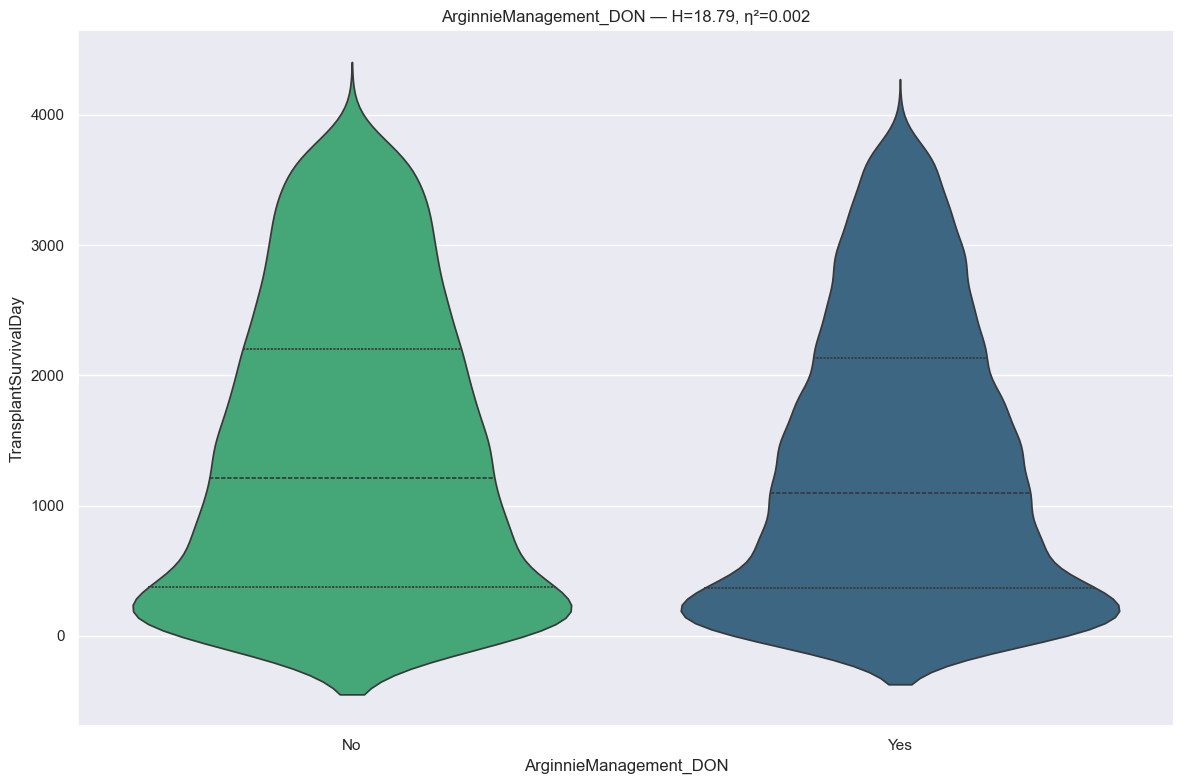

RANKING REPORT: ArginnieManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2767 records
 * Yes                                               :   5536 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 18.7928 | P-value: 1.457169e-05 | Effect η²: 0.0021
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.4572e-05 | thr=0.0500 | r=-0.058 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 

In [168]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [169]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ArginnieManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2767 records
 * Yes                                               :   5536 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 18.7928 | P-value: 1.457169e-05 | Effect η²: 0.0021
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [170]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Insulin Management

In [171]:
# info
feature = u.get_feature_info(df, 'InsulinManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top  freq
InsulinManagement_DON  8319      4  Yes  4972

:::: NaN Count:
InsulinManagement_DON    0 



{'InsulinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

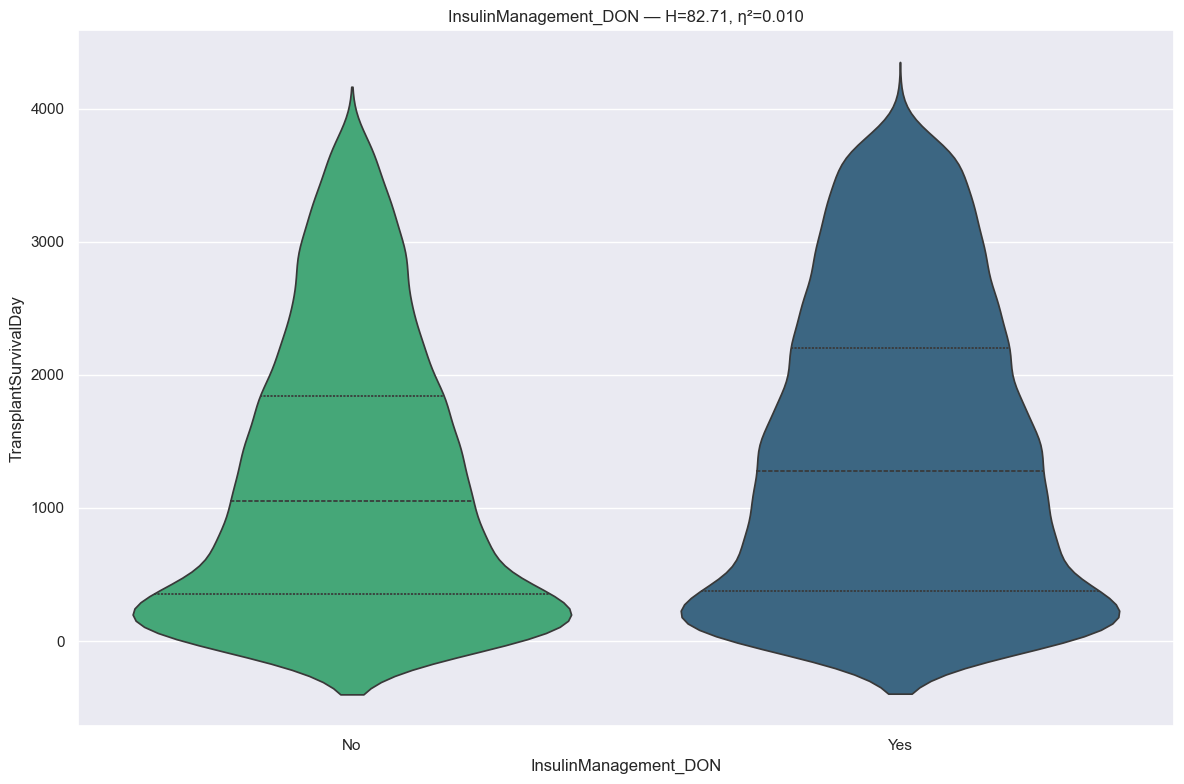

RANKING REPORT: InsulinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3330 records
 * Yes                                               :   4972 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 82.7112 | P-value: 9.496394e-20 | Effect η²: 0.0098
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=9.4968e-20 | thr=0.0500 | r= 0.118 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 c

In [172]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [173]:
# values for NominalSurvivalRanker
class_values = {"method": "holm", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: InsulinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3330 records
 * Yes                                               :   4972 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 82.7112 | P-value: 9.496394e-20 | Effect η²: 0.0098
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown


In [174]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HBV NAT Result

In [175]:
# info
feature = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
HBV_NAT_Result_DON  8319      5  Negative  5716

:::: NaN Count:
HBV_NAT_Result_DON    0 



{'HBV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive', 'Unknown'], ordered=False, categories_dtype=object)}

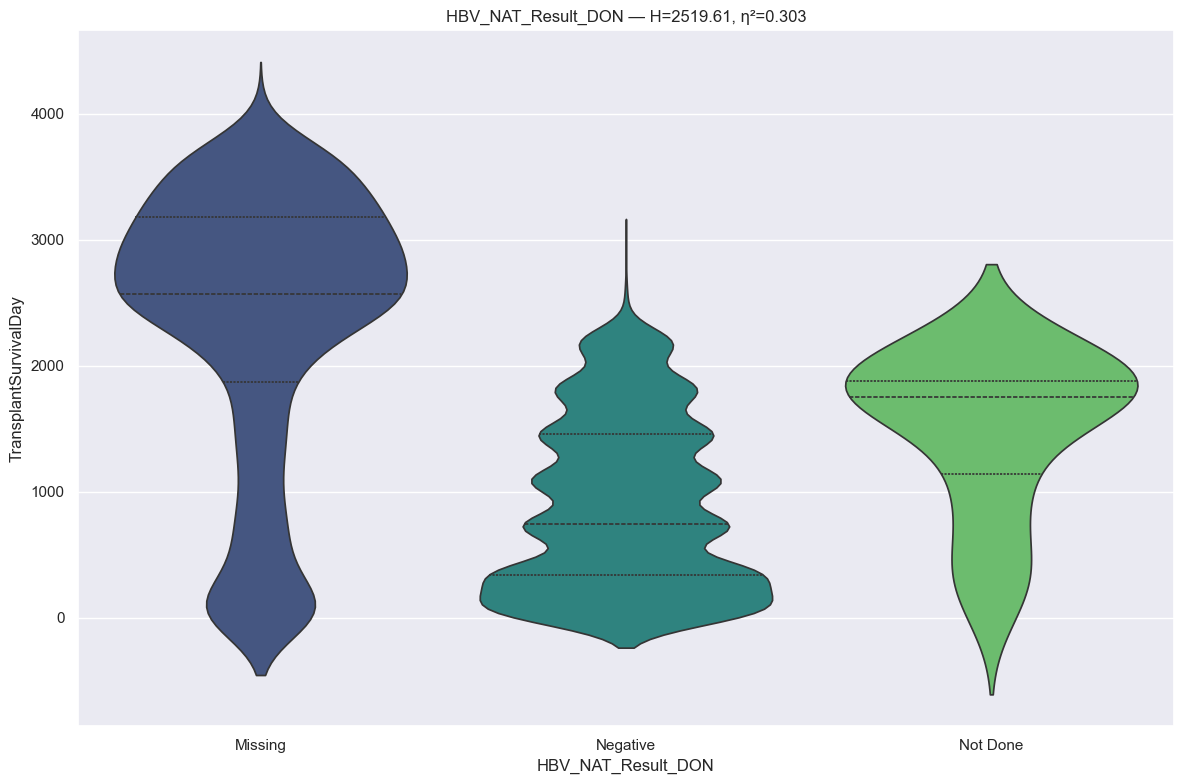

RANKING REPORT: HBV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5716 records
 * Not Done                                          :     39 records
BYPASSED CATEGORIES (n < min_n):
 * Positive                                          :      2 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 2519.6124 | P-value: 0.000000e+00 | Effect η²: 0.3029
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.687 | *Sig*
Missing      vs Not Done     | p=9.0006e-10 | thr=0.0167 | r=-0.571 | *Sig*
Negative     vs Not Done     | p=2.3043e-07 | thr=0.0167 | r= 0.480 | *Sig*
:::

In [176]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [177]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: HBV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5716 records
 * Not Done                                          :     39 records
BYPASSED CATEGORIES (n < min_n):
 * Positive                                          :      2 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 2519.6124 | P-value: 0.000000e+00 | Effect η²: 0.3029
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Missing

>>> Group_2 (

In [178]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HCV NAT Result

In [179]:
# info
feature = u.get_feature_info(df, 'HCV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
HCV_NAT_Result_DON  8319      5  Negative  5521

:::: NaN Count:
HCV_NAT_Result_DON    0 



{'HCV_NAT_Result_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

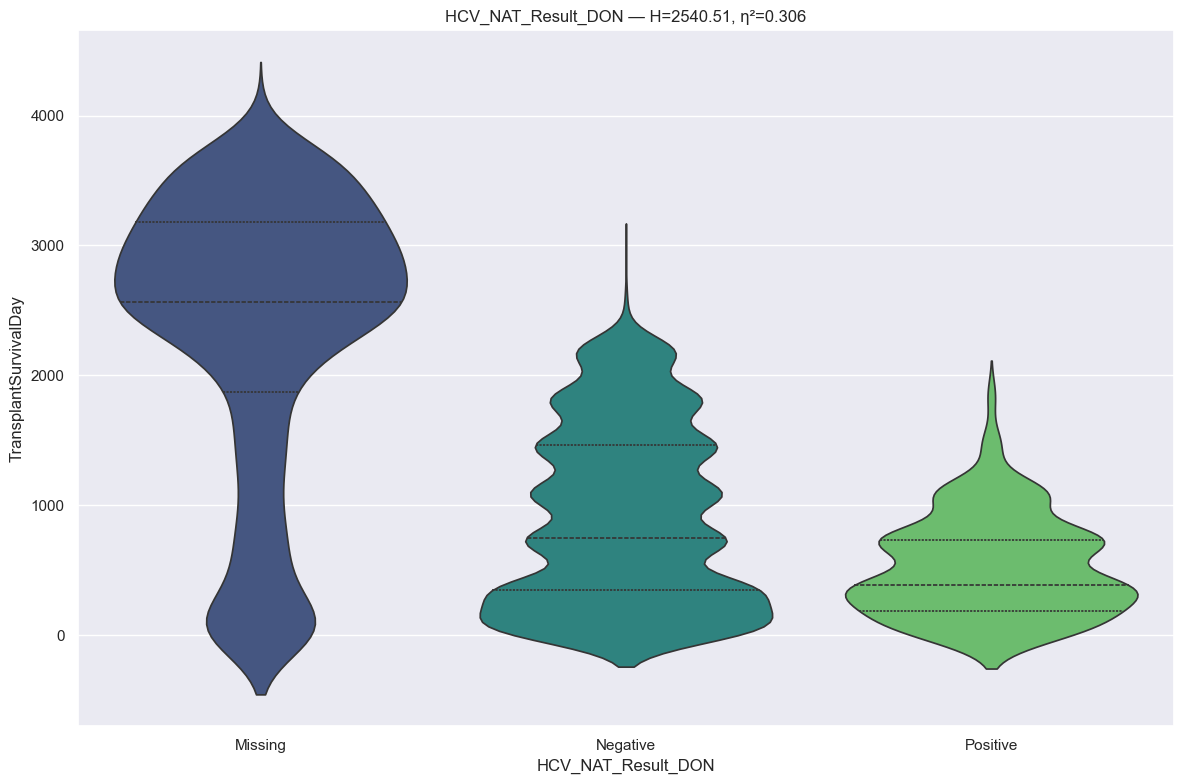

RANKING REPORT: HCV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5521 records
 * Positive                                          :    229 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      8 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 2540.5089 | P-value: 0.000000e+00 | Effect η²: 0.3056
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.684 | *Sig*
Missing      vs Positive     | p=1.6851e-80 | thr=0.0167 | r=-0.757 | *Sig*
Negative     vs Positive     | p=5.3322e-15 | thr=0.0167 | r=-0.304 | *Sig*
:::

In [180]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [181]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HIV NAT Result

In [182]:
# info
feature = u.get_feature_info(df, 'HIV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique       top  freq
HIV_NAT_Result_DON  8319      4  Negative  5734

:::: NaN Count:
HIV_NAT_Result_DON    0 



{'HIV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Unknown'], ordered=False, categories_dtype=object)}

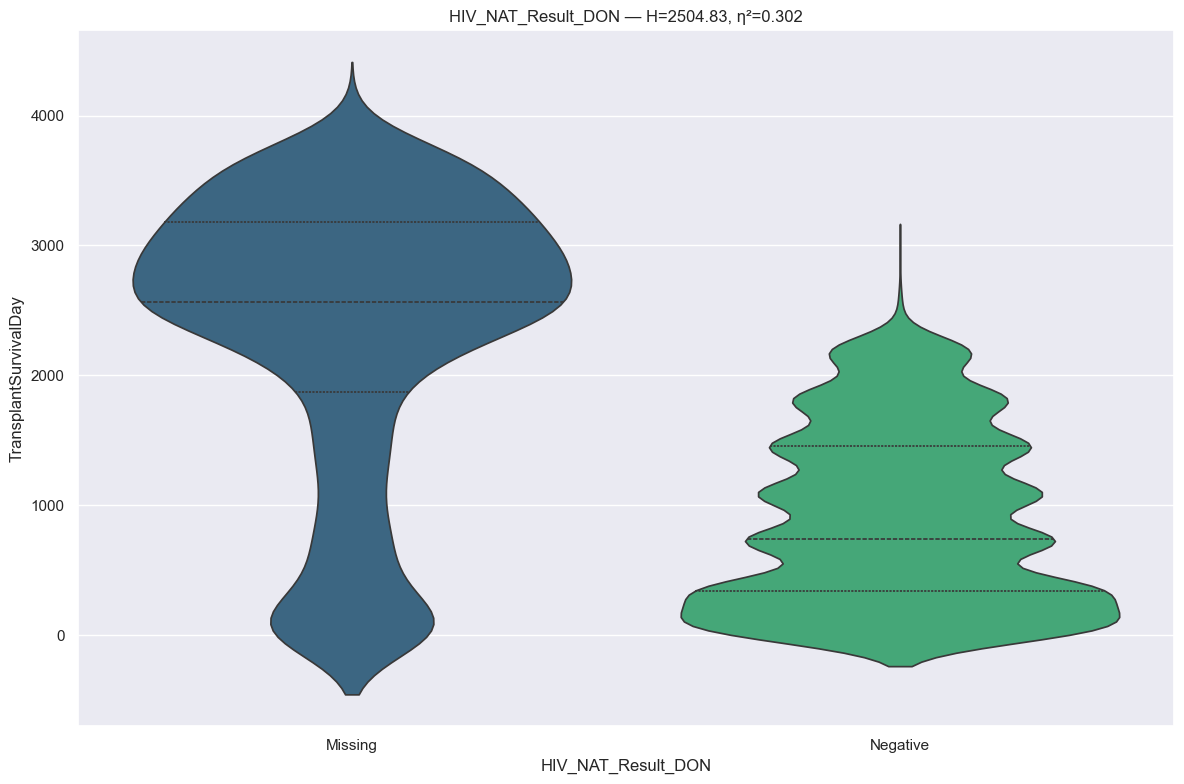

RANKING REPORT: HIV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5734 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :     24 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 2504.8261 | P-value: 0.000000e+00 | Effect η²: 0.3020
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0500 | r=-0.687 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Missing

>>> Group_2 (1 categories)
  - Negative

>>> O

In [183]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [184]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Allocation Type

In [185]:
# info
feature = u.get_feature_info(df, 'AllocationType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique    top  freq
AllocationType_DON  8319      4  Local  3756

:::: NaN Count:
AllocationType_DON    0 



{'AllocationType_DON': CategoricalDtype(categories=['Foreign Donor', 'Local', 'National', 'Regional'], ordered=False, categories_dtype=object)}

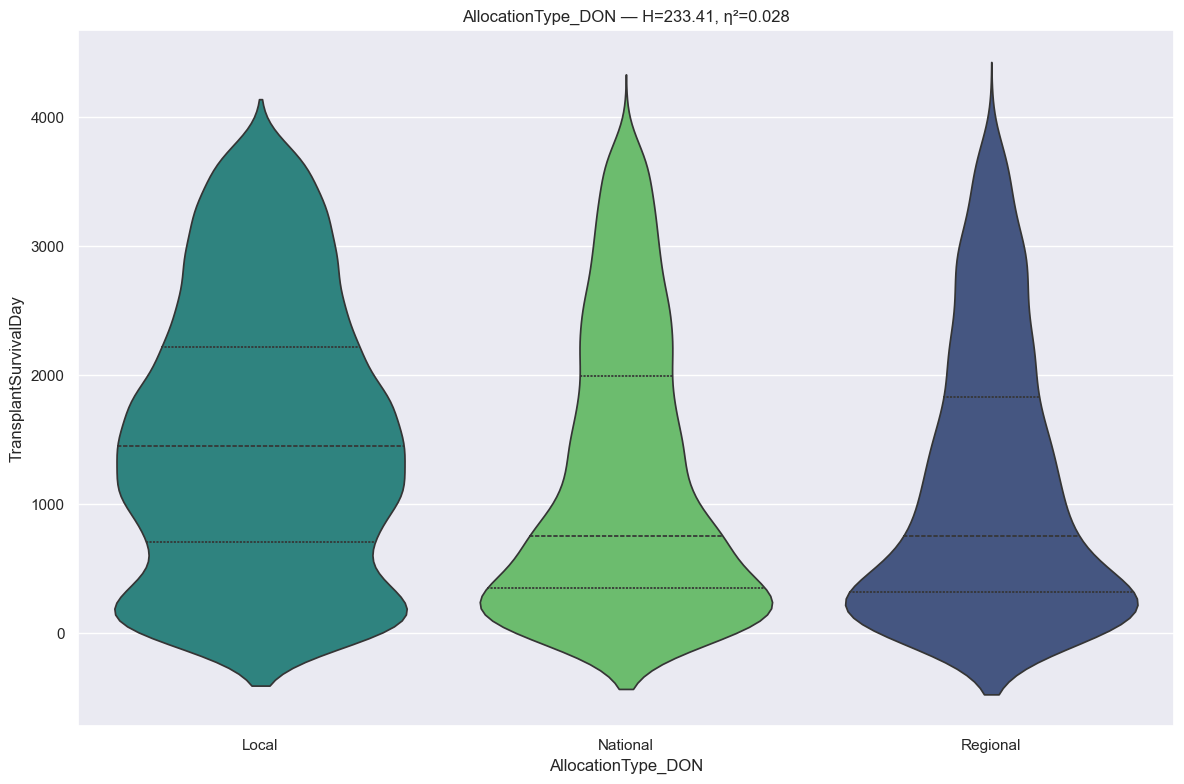

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :   3756 records
 * National                                          :   2930 records
 * Regional                                          :   1624 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :      9 records
--------------------------------------------------------------------------------
Kruskal H: 233.4063 | P-value: 2.072393e-51 | Effect η²: 0.0279
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Local        vs National     | p=8.2111e-38 | thr=0.0167 | r=-0.183 | *Sig*
Local        vs Regional     | p=4.0415e-35 | thr=0.0167 | r=-0.212 | *Sig*
National     vs Regional     | p=9.9972e-02 | thr=0.0167 | r=-0.029 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::

In [186]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [187]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Urine Portein

In [188]:
# info
feature = u.get_feature_info(df, 'UrinePortein', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique top  freq
UrinePortein_DON  8319      4  No  4623

:::: NaN Count:
UrinePortein_DON    0 



{'UrinePortein_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

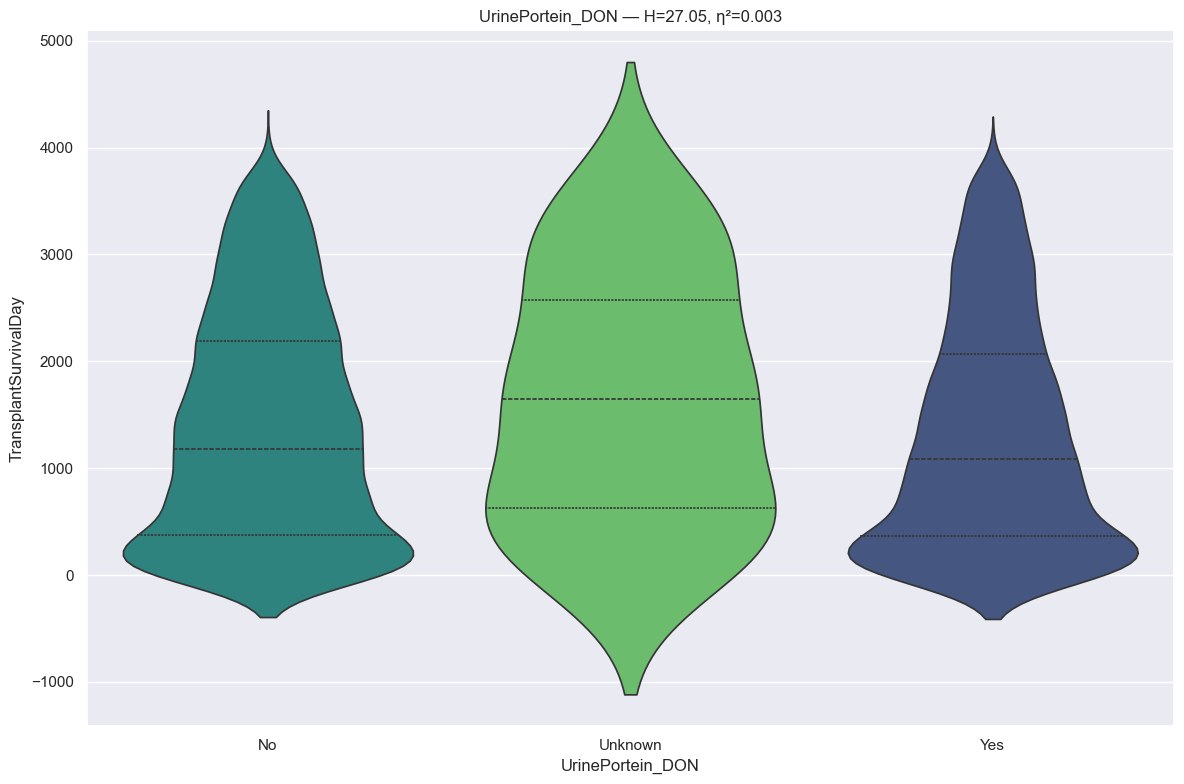

RANKING REPORT: UrinePortein_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4623 records
 * Unknown                                           :     37 records
 * Yes                                               :   3645 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 27.0528 | P-value: 1.335206e-06 | Effect η²: 0.0030
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.7532e-07 | thr=0.0167 | r=-0.063 | *Sig*
Unknown      vs Yes          | p=4.9426e-02 | thr=0.0167 | r=-0.187 | Not Sig
No           vs Unknown      | p=1.7509e-01 | thr=0.0167 | r= 0.129 | Not Sig
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::

In [189]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [190]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cardiac Arrest

In [191]:
# info
feature = u.get_feature_info(df, 'CardiacArrest', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique top  freq
CardiacArrest_DON  8319      3  No  7595

:::: NaN Count:
CardiacArrest_DON    0 



{'CardiacArrest_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

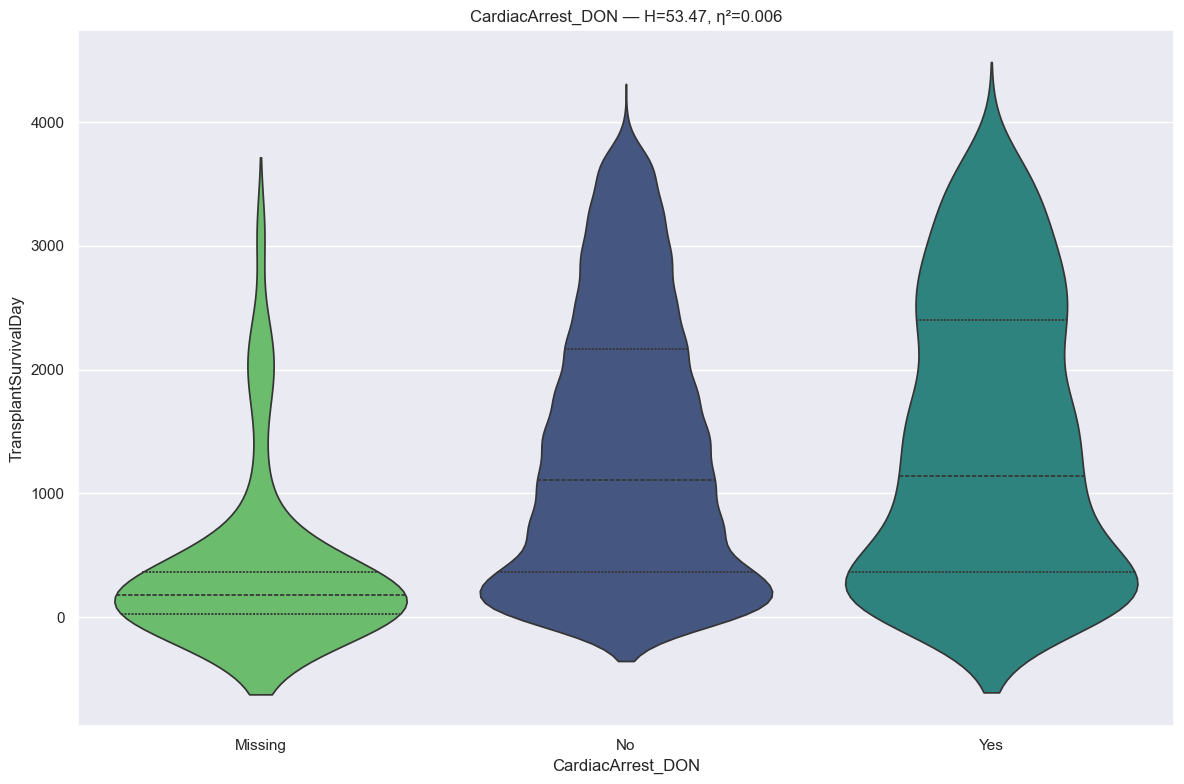

RANKING REPORT: CardiacArrest_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     50 records
 * No                                                :   7595 records
 * Yes                                               :    674 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 53.4732 | P-value: 2.445904e-12 | Effect η²: 0.0062
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=5.2901e-13 | thr=0.0167 | r= 0.591 | *Sig*
Missing      vs Yes          | p=3.6514e-12 | thr=0.0167 | r= 0.589 | *Sig*
No           vs Yes          | p=2.3543e-01 | thr=0.0167 | r= 0.028 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 

In [192]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [193]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but has no clinical interpretation value.

#### Myocardial Infarction History

In [194]:
# info
feature = u.get_feature_info(df, 'MyocardialInfarctionHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                count unique top  freq
MyocardialInfarctionHistory_DON  8319      4  No  8193

:::: NaN Count:
MyocardialInfarctionHistory_DON    0 



{'MyocardialInfarctionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

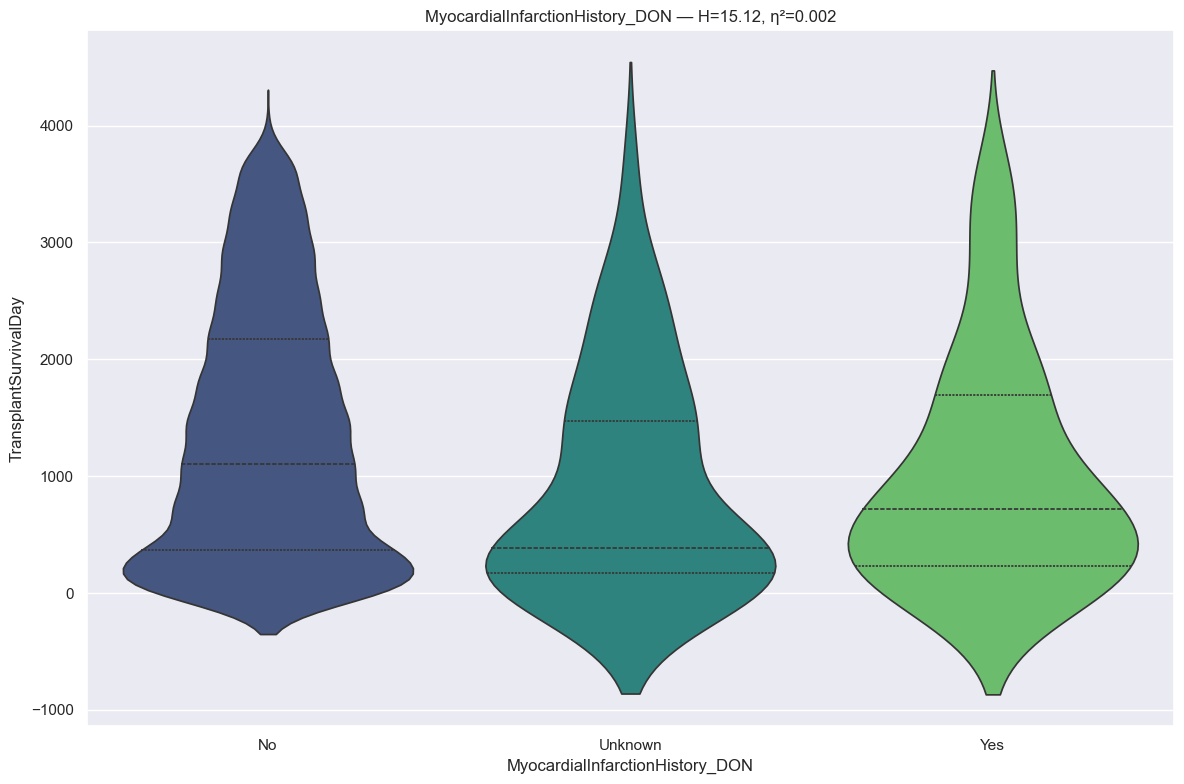

RANKING REPORT: MyocardialInfarctionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8193 records
 * Unknown                                           :     54 records
 * Yes                                               :     58 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 15.1186 | P-value: 5.212272e-04 | Effect η²: 0.0016
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=2.3452e-03 | thr=0.0167 | r=-0.240 | *Sig*
No           vs Yes          | p=1.4655e-02 | thr=0.0167 | r=-0.186 | *Sig*
Unknown      vs Yes          | p=4.6135e-01 | thr=0.0167 | r= 0.081 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::

In [195]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [196]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### LV Ejection Fraction Medthod

In [197]:
# info
feature = u.get_feature_info(df, 'LV_EjectionFractionMedthod', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                               count unique   top  freq
LV_EjectionFractionMedthod_DON  8319      3  Echo  8101

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0 



{'LV_EjectionFractionMedthod_DON': CategoricalDtype(categories=['Angiogram', 'Echo', 'Missing'], ordered=False, categories_dtype=object)}

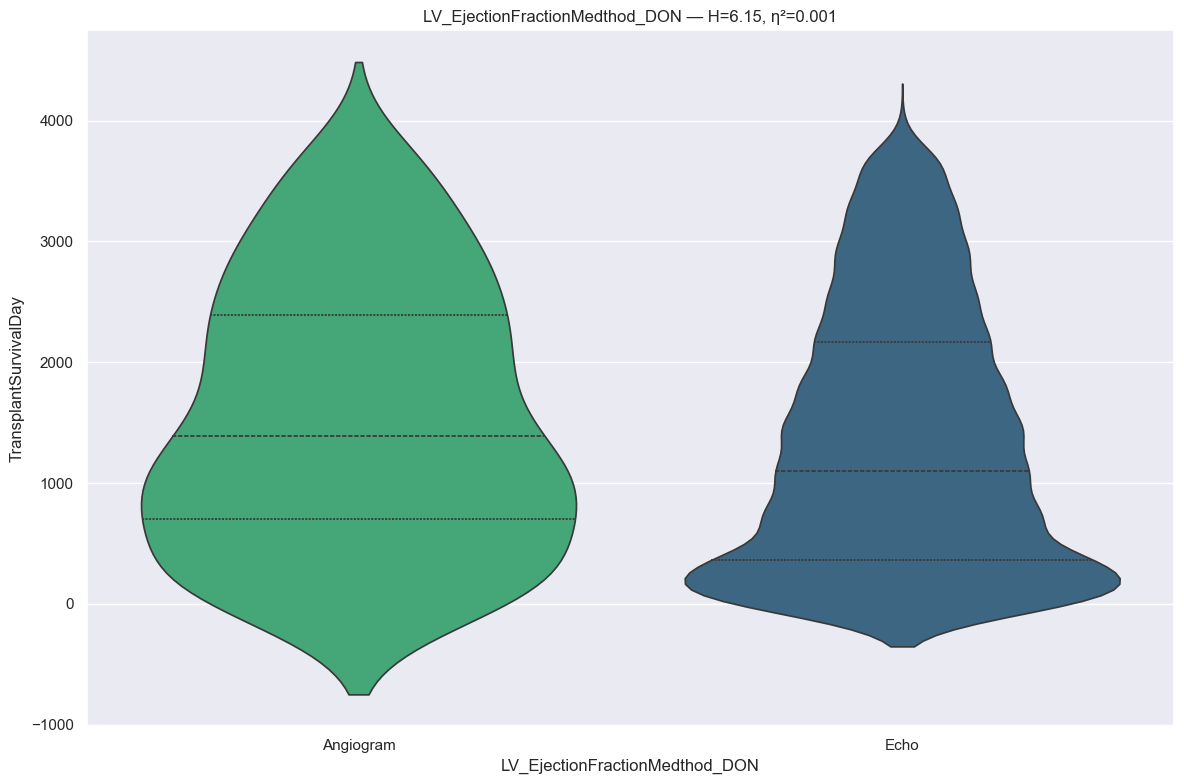

RANKING REPORT: LV_EjectionFractionMedthod_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Angiogram                                         :    206 records
 * Echo                                              :   8101 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 6.1521 | P-value: 1.312568e-02 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Angiogram    vs Echo         | p=1.3126e-02 | thr=0.0500 | r=-0.101 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Angiogram

>>> Group_2 (1 categories)
  - Echo

>>> Other (1 categories)
  - Missing

LV_EjectionFractionMedthod_DON

In [198]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [199]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Coronary Angiogram

In [200]:
# info
feature = u.get_feature_info(df, 'CoronaryAngiogram', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top  freq
CoronaryAngiogram_DON  8319      4  No  4870

:::: NaN Count:
CoronaryAngiogram_DON    0 



{'CoronaryAngiogram_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes, normal', 'Yes, not normal'], ordered=False, categories_dtype=object)}

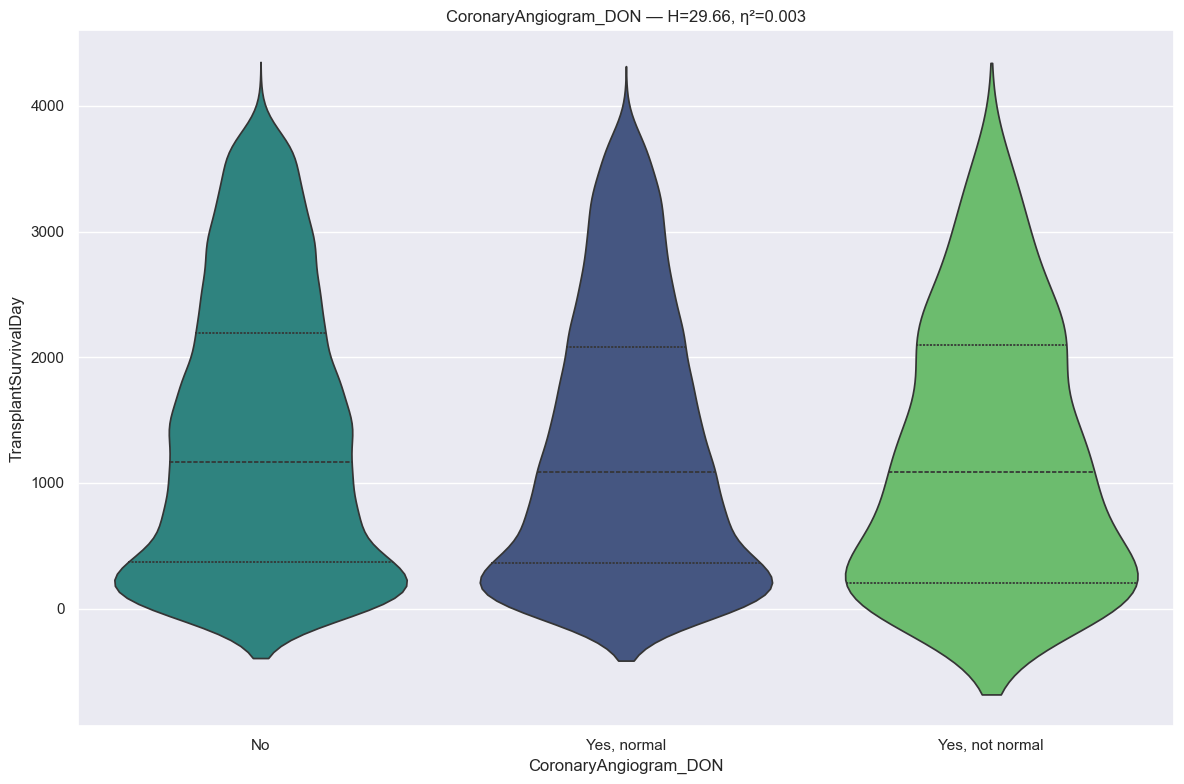

RANKING REPORT: CoronaryAngiogram_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4870 records
 * Yes, normal                                       :   3206 records
 * Yes, not normal                                   :    229 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 29.6648 | P-value: 3.617208e-07 | Effect η²: 0.0033
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes, normal  | p=9.0261e-07 | thr=0.0167 | r=-0.064 | *Sig*
No           vs Yes, not normal | p=2.8865e-03 | thr=0.0167 | r=-0.116 | *Sig*
Yes, normal  vs Yes, not normal | p=1.7713e-01 | thr=0.0167 | r=-0.053 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::

In [201]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [202]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Biopsy

In [203]:
# info
feature = u.get_feature_info(df, 'Biopsy', cat=False)
# dtype
{col: df[col].dtype for col in feature}

           count unique              top  freq
Biopsy_DON  8319      5  Biopsy not done  8296

:::: NaN Count:
Biopsy_DON    0 



{'Biopsy_DON': CategoricalDtype(categories=['Biopsy not done', 'Missing', 'Unknown',
                   'Yes, rejection confirmed', 'Yes, rejection not confirmed'],
 , ordered=False, categories_dtype=object)}

In [204]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

[WARNING] Cannot perform statistical comparison for Biopsy_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Biopsy not done

                  Biopsy_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             Biopsy not done         1338.085342                1105.0                 3956.0                    0.0          8296
                     Missing         1034.000000                 751.5                 3093.0                    8.0            14
Yes, rejection not confirmed         2557.000000                2721.5                 2929.0                 1856.0             4
                     Unknown         2044.666667                2182.0                 2889.0                 1063.0             3
    Yes, rejection confirmed          927.

In [205]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** Unable to determine due to sample sizes.

#### Tatoos

In [206]:
# info
feature = u.get_feature_info(df, 'Tatoos', cat=False)
# dtype
{col: df[col].dtype for col in feature}

           count unique  top  freq
Tatoos_DON  8319      4  Yes  4723

:::: NaN Count:
Tatoos_DON    0 



{'Tatoos_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

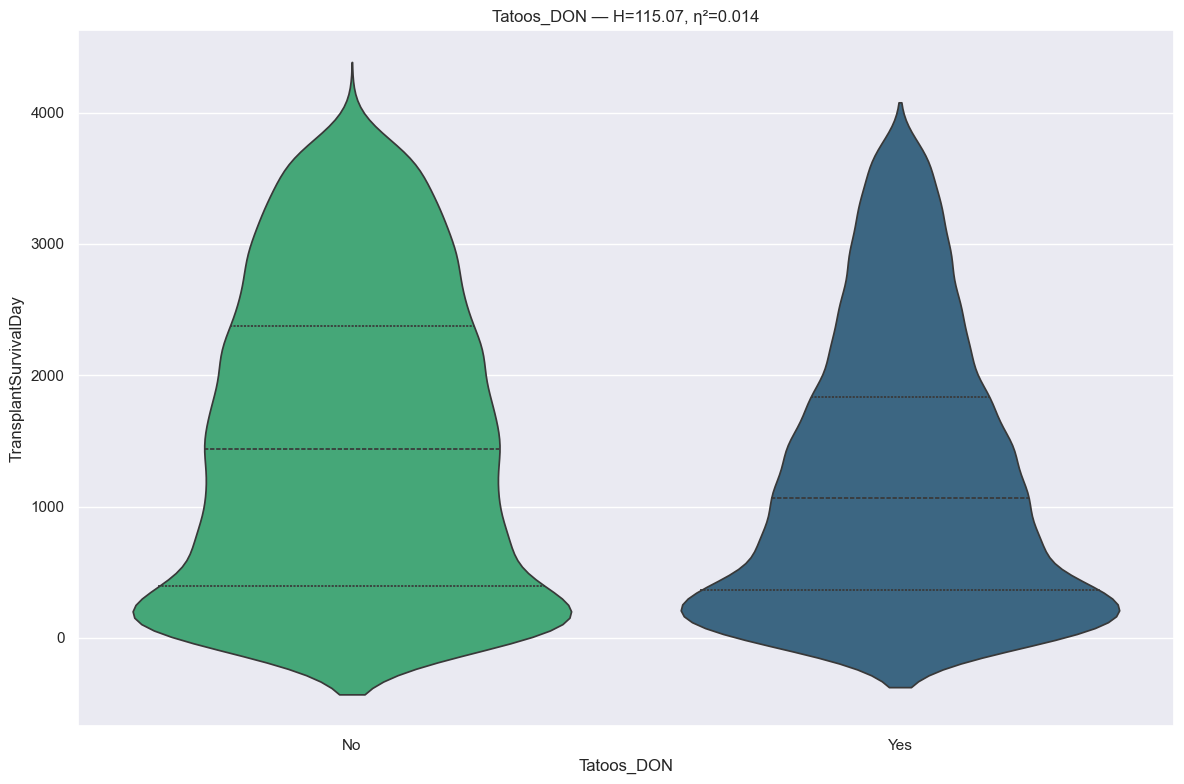

RANKING REPORT: Tatoos_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3570 records
 * Yes                                               :   4723 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 115.0726 | P-value: 7.586931e-27 | Effect η²: 0.0138
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.5873e-27 | thr=0.0500 | r=-0.137 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)

In [207]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [208]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Antibody Result HBSAB

In [209]:
# info
feature = u.get_feature_info(df, 'AntibodyResultHBSAB', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique       top  freq
AntibodyResultHBSAB_DON  8319      7  Not Done  7122

:::: NaN Count:
AntibodyResultHBSAB_DON    0 



{'AntibodyResultHBSAB_DON': CategoricalDtype(categories=['Cannot Disclose', 'Indeterminate', 'Missing', 'Negative',
                   'Not Done', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

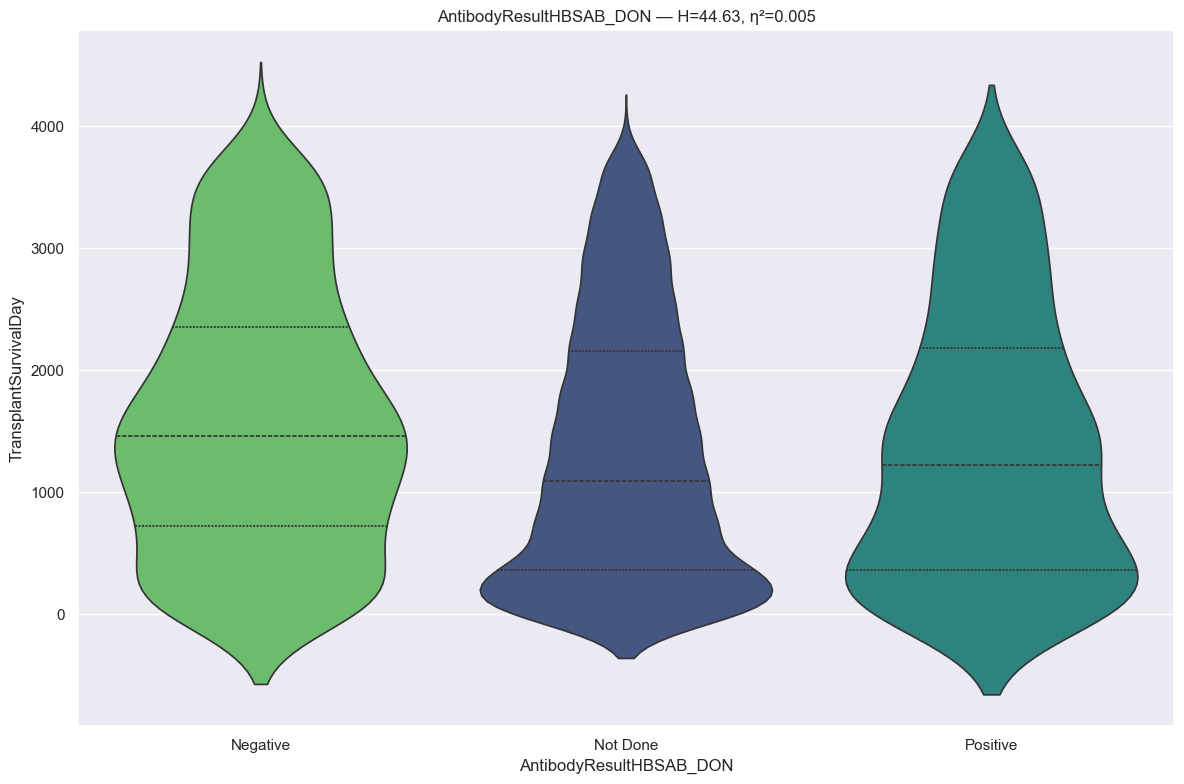

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :    746 records
 * Not Done                                          :   7122 records
 * Positive                                          :    418 records
BYPASSED CATEGORIES (n < min_n):
 * Cannot Disclose                                   :      1 records
 * Indeterminate                                     :     20 records
 * Missing                                           :     10 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 44.6295 | P-value: 2.036241e-10 | Effect η²: 0.0051
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.3661e-11 | thr=0.0167 | r=-0.148 | *Sig*
Negative    

In [210]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [211]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :    746 records
 * Not Done                                          :   7122 records
 * Positive                                          :    418 records
BYPASSED CATEGORIES (n < min_n):
 * Cannot Disclose                                   :      1 records
 * Indeterminate                                     :     20 records
 * Missing                                           :     10 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 44.6295 | P-value: 2.036241e-10 | Effect η²: 0.0051
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other')

In [212]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### EpsteinBarr IGG

In [213]:
# info
feature = u.get_feature_info(df, 'EpsteinBarr_IGG', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top  freq
EpsteinBarr_IGG_DON  8319      6  Positive  7584

:::: NaN Count:
EpsteinBarr_IGG_DON    0 



{'EpsteinBarr_IGG_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

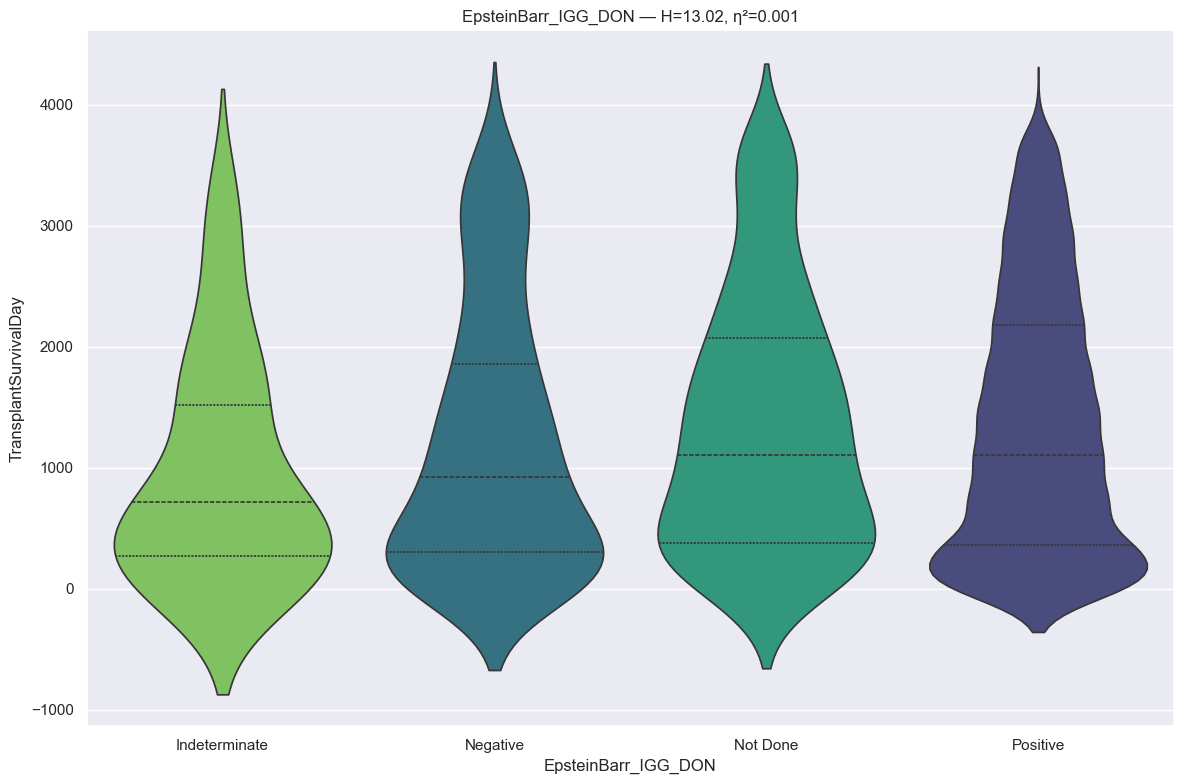

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     44 records
 * Negative                                          :    357 records
 * Not Done                                          :    326 records
 * Positive                                          :   7584 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 13.0197 | P-value: 4.594201e-03 | Effect η²: 0.0012
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=6.2328e-03 | thr=0.0083 | r= 0.254 | *Sig*
Negative     vs Positive     | p=1.0769e-02 | thr=0.0083 | r= 0.080 | Not Sig
Negativ

In [214]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [215]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     44 records
 * Negative                                          :    357 records
 * Not Done                                          :    326 records
 * Positive                                          :   7584 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 13.0197 | P-value: 4.594201e-03 | Effect η²: 0.0012
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::

In [216]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### EpsteinBarr IGM

In [217]:
# info
feature = u.get_feature_info(df, 'EpsteinBarr_IGM', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top  freq
EpsteinBarr_IGM_DON  8319      6  Negative  6649

:::: NaN Count:
EpsteinBarr_IGM_DON    0 



{'EpsteinBarr_IGM_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

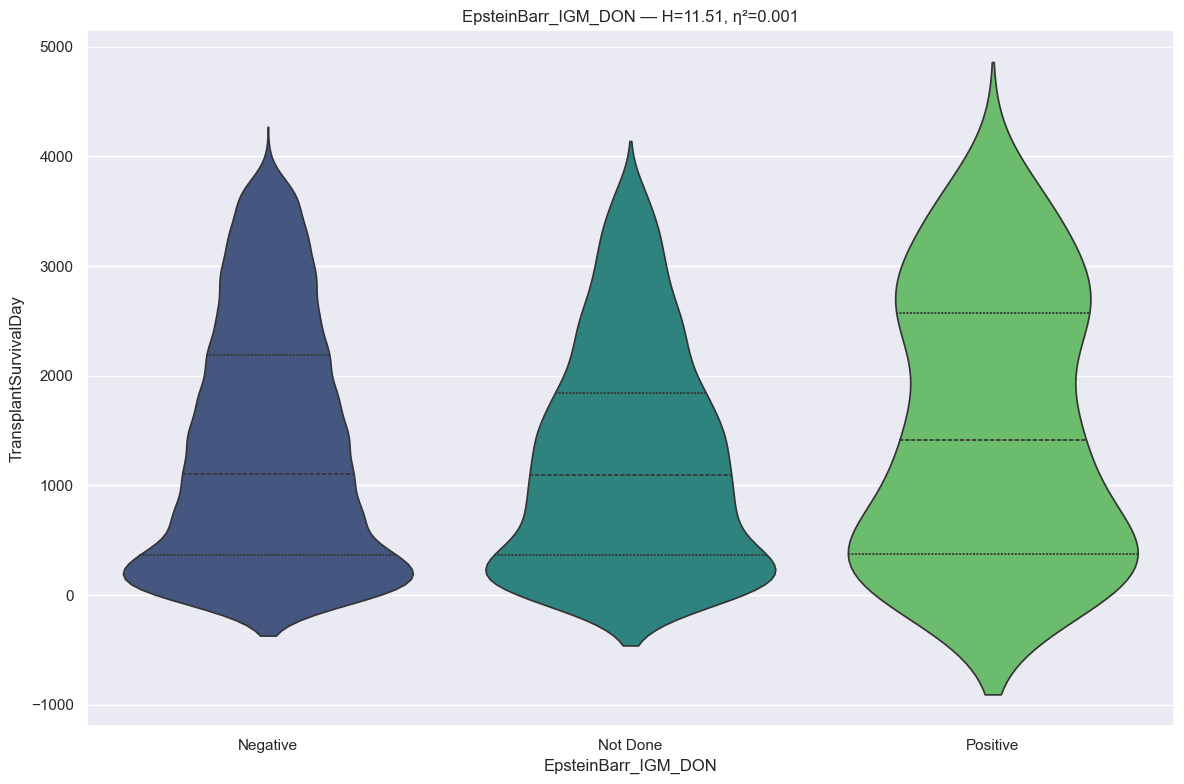

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   6649 records
 * Not Done                                          :   1503 records
 * Positive                                          :    132 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :     25 records
 * Missing                                           :      9 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.5068 | P-value: 3.171991e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.4435e-03 | thr=0.0167 | r=-0.050 | *Sig*
Not Done     vs Positive     | p=2.5445e-02 | thr=0.0167 | r= 0.117 | Not Sig
Negative

In [218]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [219]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   6649 records
 * Not Done                                          :   1503 records
 * Positive                                          :    132 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :     25 records
 * Missing                                           :      9 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.5068 | P-value: 3.171991e-03 | Effect η²: 0.0011
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::

In [220]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### HIV Risk

In [221]:
# info
feature = u.get_feature_info(df, 'HIV_Risk', cat=False)
# dtype
{col: df[col].dtype for col in feature}

             count unique top  freq
HIV_Risk_DON  8319      4  No  6367

:::: NaN Count:
HIV_Risk_DON    0 



{'HIV_Risk_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

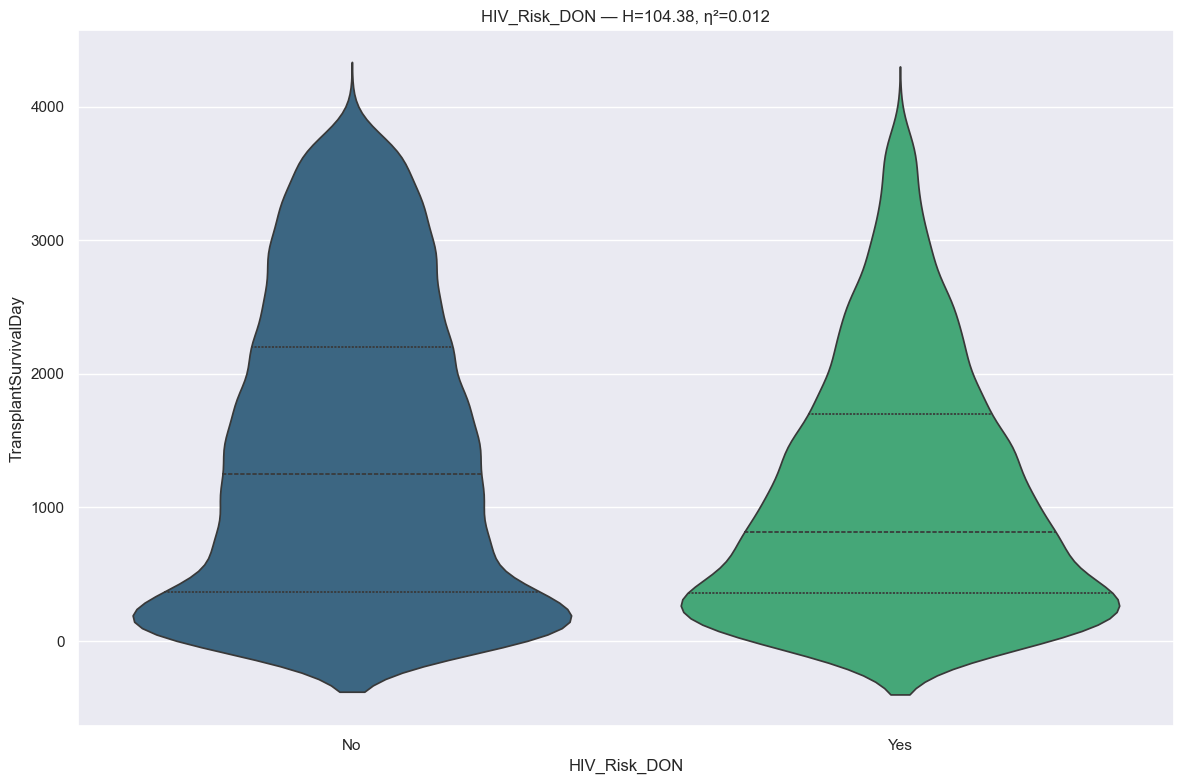

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6367 records
 * Yes                                               :   1950 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 104.3772 | P-value: 1.672480e-24 | Effect η²: 0.0124
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.6726e-24 | thr=0.0500 | r=-0.153 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categorie

In [222]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [223]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6367 records
 * Yes                                               :   1950 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 104.3772 | P-value: 1.672480e-24 | Effect η²: 0.0124
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categories)
  - Missing
  - Unknown



In [224]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Inotropic Agent

In [225]:
# info
feature = u.get_feature_info(df, 'InotropicAgent', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique      top  freq
InotropicAgent_DON  8319      7  Missing  4966

:::: NaN Count:
InotropicAgent_DON    0 



{'InotropicAgent_DON': CategoricalDtype(categories=['Dobutamine', 'Dopamine', 'Epinephrine', 'Levophed',
                   'Missing', 'Neosynephrine', 'Other, specify'],
 , ordered=False, categories_dtype=object)}

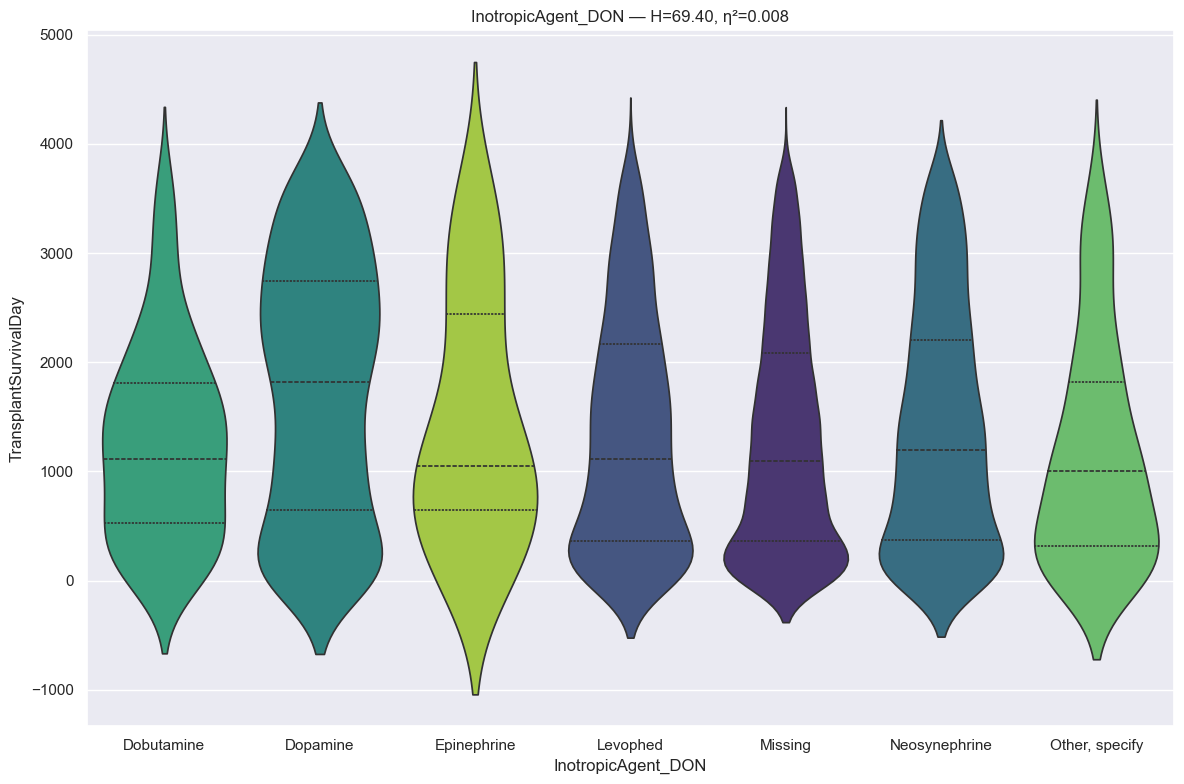

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    149 records
 * Dopamine                                          :    540 records
 * Epinephrine                                       :     38 records
 * Levophed                                          :   1031 records
 * Missing                                           :   4966 records
 * Neosynephrine                                     :   1417 records
 * Other, specify                                    :    178 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 69.4038 | P-value: 5.418188e-13 | Effect η²: 0.0076
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Dopamine     vs Missing      | p=2.1106e-14 | thr=0.0024 | r=-0.200 | *Sig*
Dopamine     vs Levophed

In [226]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [227]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Kidney Allocation

In [228]:
# info
feature = u.get_feature_info(df, 'KidneyAllocation', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top  freq
KidneyAllocation_DON  8319      3  No  7974

:::: NaN Count:
KidneyAllocation_DON    0 



{'KidneyAllocation_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

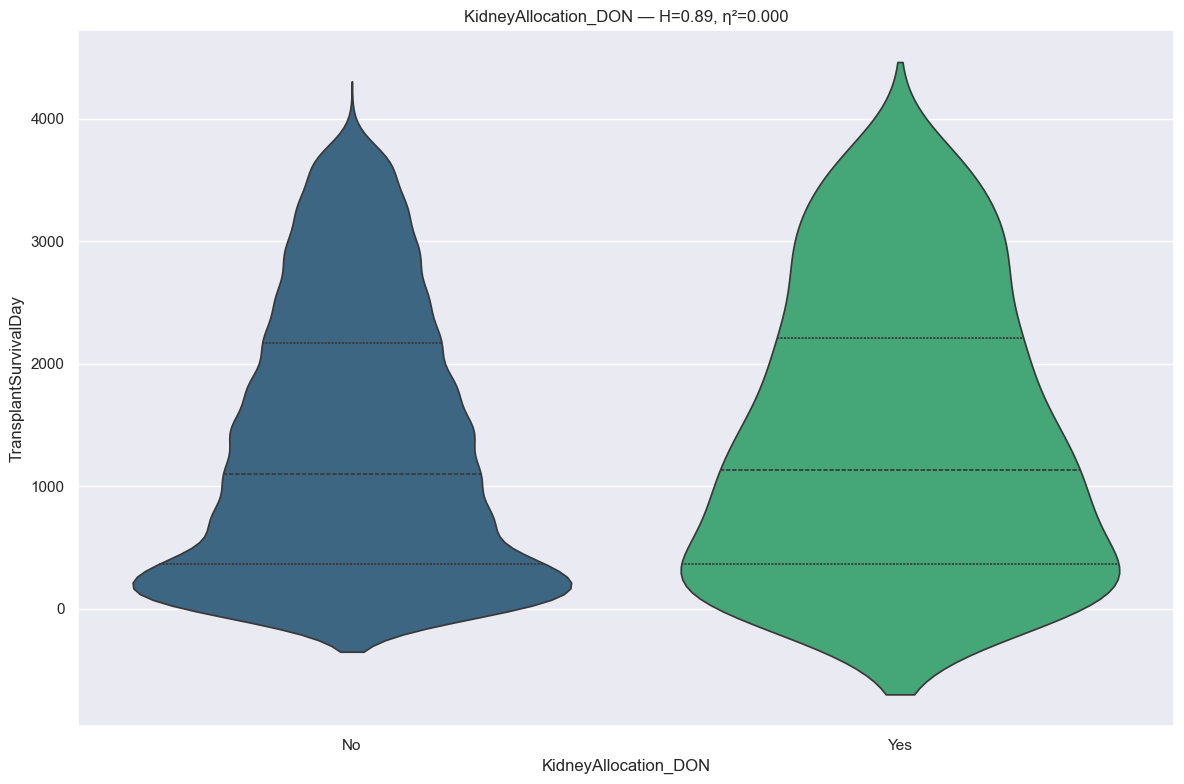

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7974 records
 * Yes                                               :    344 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 0.8915 | P-value: 3.450587e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.4506e-01 | thr=0.0500 | r= 0.030 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Missing

KidneyAllocation_DON  mean_survival_days  median_survival_days  maximum_su

In [229]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [230]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically significant effect.

#### Inotropic Medication Procurement

In [231]:
# info
feature = u.get_feature_info(df, 'InotropicMedicationProcurement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                   count unique top  freq
InotropicMedicationProcurement_DON  8319      4  No  4938

:::: NaN Count:
InotropicMedicationProcurement_DON    0 



{'InotropicMedicationProcurement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

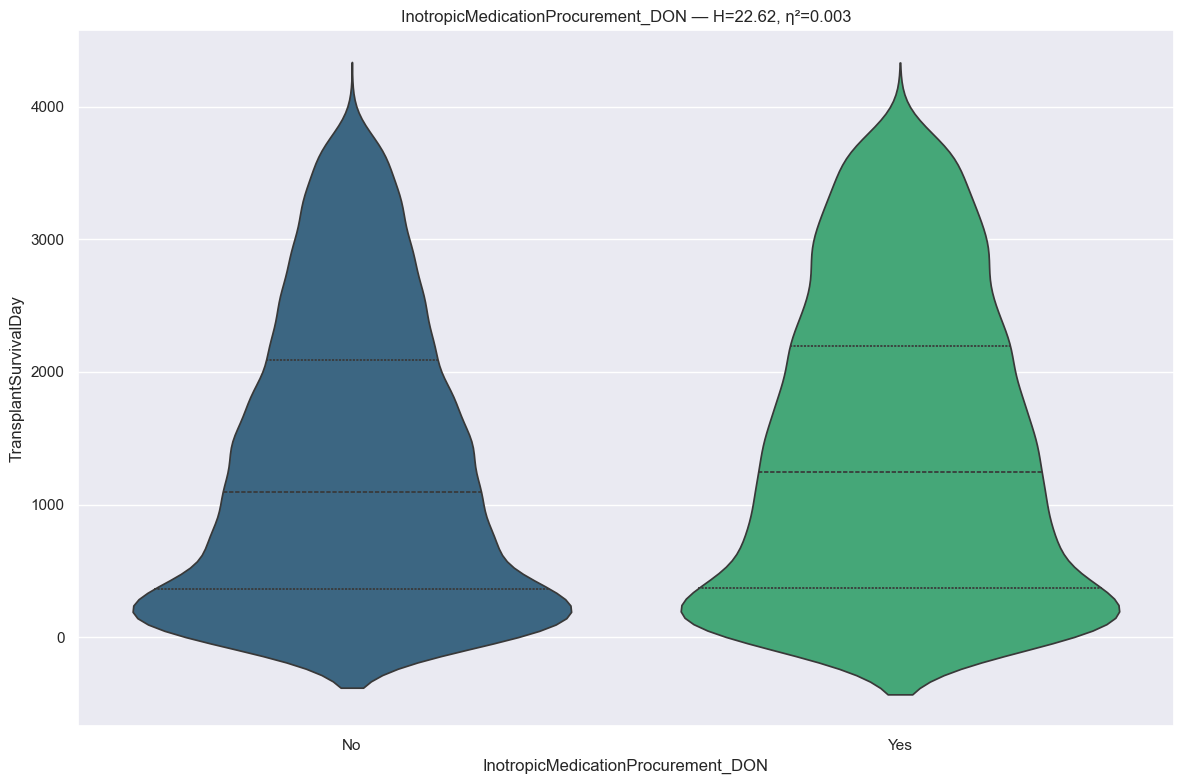

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4938 records
 * Yes                                               :   3353 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 22.6246 | P-value: 1.969437e-06 | Effect η²: 0.0026
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.9695e-06 | thr=0.0500 | r= 0.061 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>

In [232]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [233]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### LT ONE WEEK

In [234]:
# info
feature = u.get_feature_info(df, 'LT_ONE_WEEK', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
LT_ONE_WEEK_DON  8319      1  No  8319

:::: NaN Count:
LT_ONE_WEEK_DON    0 



{'LT_ONE_WEEK_DON': CategoricalDtype(categories=['No'], ordered=False, categories_dtype=object)}

In [235]:
# add to remove list
remove_cols.extend(feature)

#### Transfusion Number

In [236]:
# info
feature = u.get_feature_info(df, 'TransfusionNumber', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique   top  freq
TransfusionNumber_DON  8319      6  NONE  3742

:::: NaN Count:
TransfusionNumber_DON    0 



{'TransfusionNumber_DON': CategoricalDtype(categories=['1 - 5', '6 - 10', 'GREATER THAN 10', 'Missing', 'NONE',
                   'UNKNOWN'],
 , ordered=False, categories_dtype=object)}

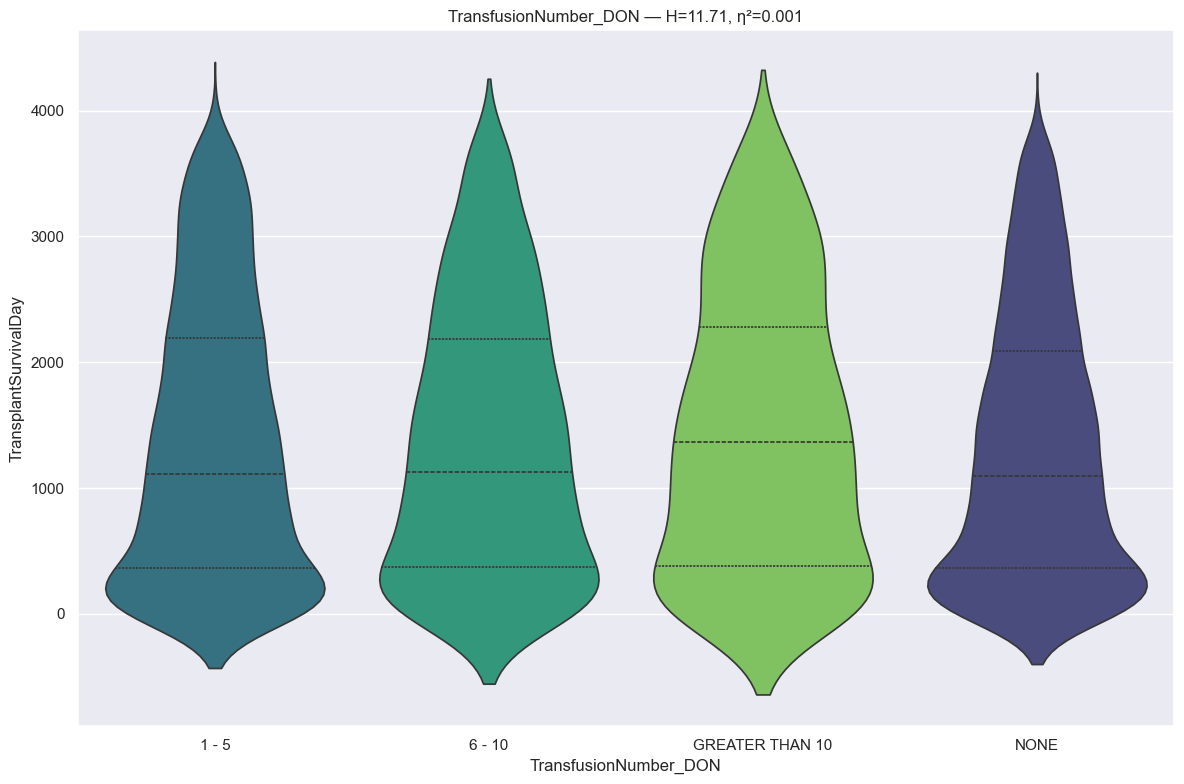

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   3327 records
 * 6 - 10                                            :    780 records
 * GREATER THAN 10                                   :    460 records
 * NONE                                              :   3742 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      9 records
 * UNKNOWN                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.7140 | P-value: 8.429754e-03 | Effect η²: 0.0010
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
GREATER THAN 10 vs NONE         | p=8.9769e-03 | thr=0.0083 | r=-0.075 | Not Sig
1 - 5        vs NONE         | p=1.3192e-02 | thr=0.0083 | r=-0.034 | Not Sig
6

In [237]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [238]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   3327 records
 * 6 - 10                                            :    780 records
 * GREATER THAN 10                                   :    460 records
 * NONE                                              :   3742 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      9 records
 * UNKNOWN                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.7140 | P-value: 8.429754e-03 | Effect η²: 0.0010
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::

In [239]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but it becomes non-informative and should be treated as a single-level variable. There is no remaining category structure that survives your r‑threshold, so the feature has no usable variation left.

#### Pulmonary Catheter

In [240]:
# info
feature = u.get_feature_info(df, 'PulmonaryCatheter', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top  freq
PulmonaryCatheter_DON  8319      3  No  7756

:::: NaN Count:
PulmonaryCatheter_DON    0 



{'PulmonaryCatheter_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

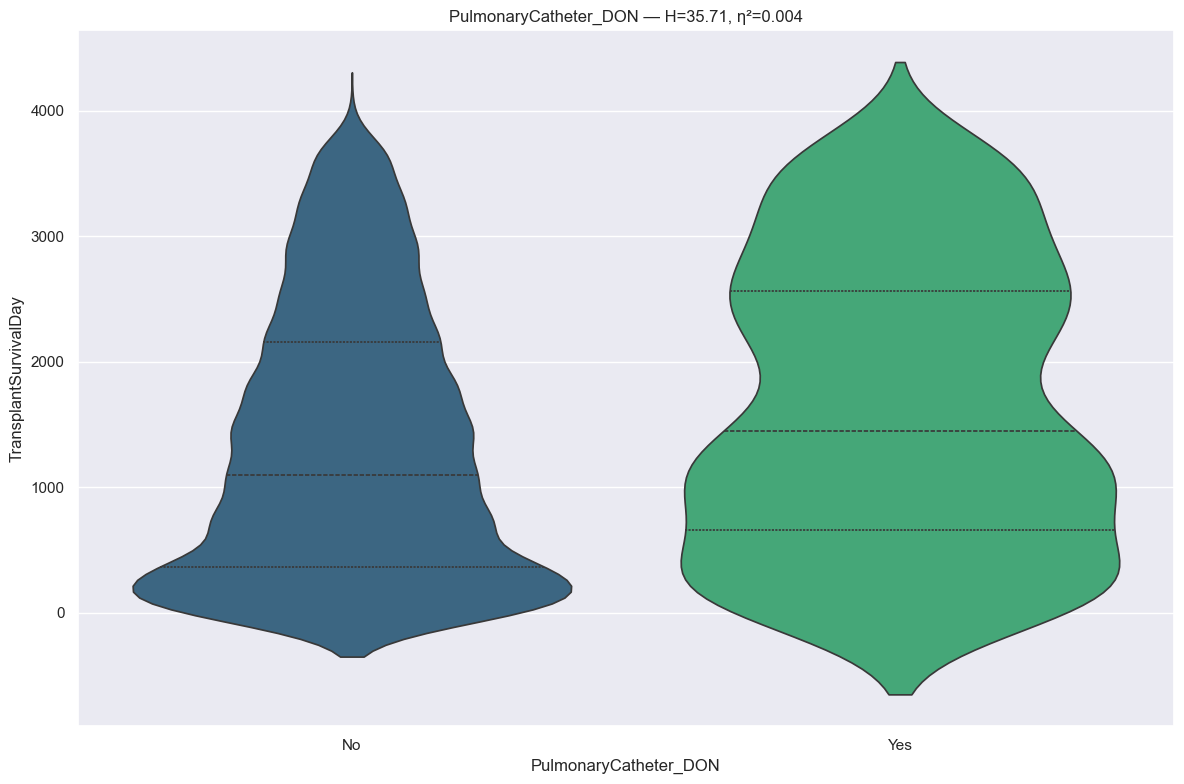

RANKING REPORT: PulmonaryCatheter_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7756 records
 * Yes                                               :    549 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 35.7104 | P-value: 2.289432e-09 | Effect η²: 0.0042
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.2896e-09 | thr=0.0500 | r= 0.152 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

PulmonaryCatheter_DON  mean_survival_days  med

In [241]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [242]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Bronchoscopy Left

In [243]:
# info
feature = u.get_feature_info(df, 'BronchoscopyLeft', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique      top  freq
BronchoscopyLeft_DON  8319      9  Missing  3934

:::: NaN Count:
BronchoscopyLeft_DON    0 



{'BronchoscopyLeft_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

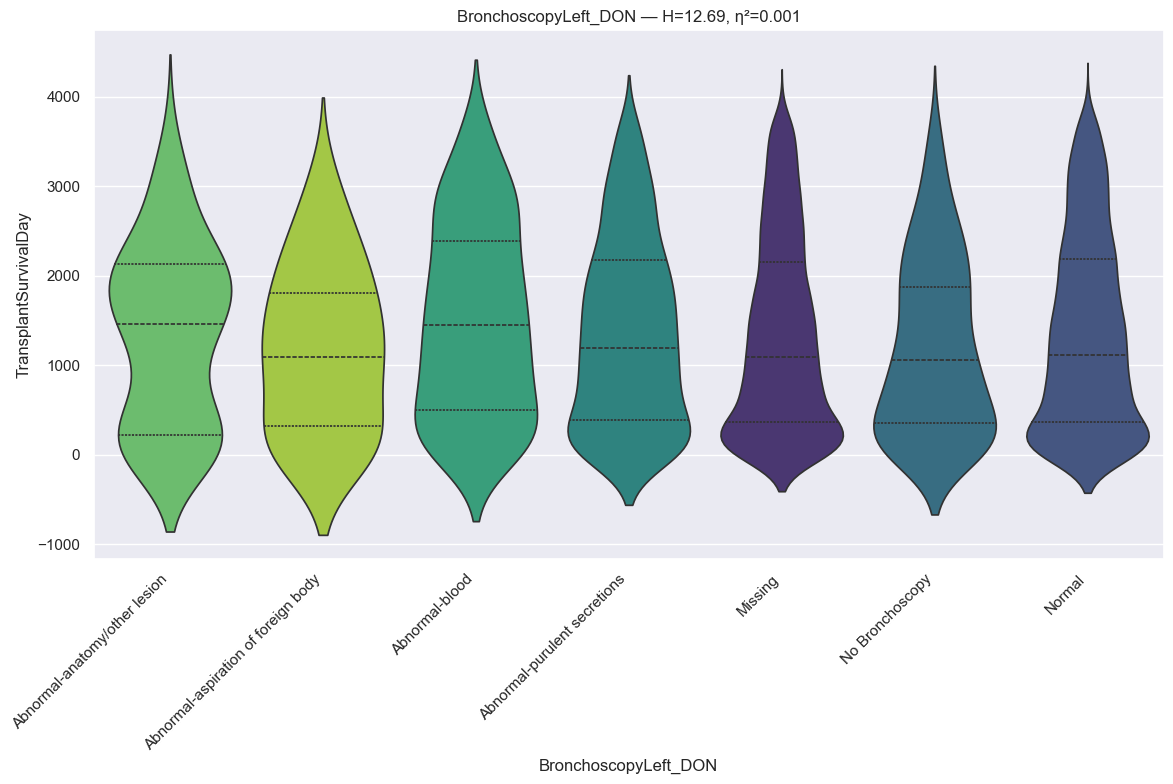

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     64 records
 * Abnormal-aspiration of foreign body               :     36 records
 * Abnormal-blood                                    :    201 records
 * Abnormal-purulent secretions                      :    674 records
 * Missing                                           :   3934 records
 * No Bronchoscopy                                   :    220 records
 * Normal                                            :   3162 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     24 records
 * Unknown if bronchoscopy performed                 :      4 records
--------------------------------------------------------------------------------
Kruskal H: 12.6895 | P-value: 4.824085e-02 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [244]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [245]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     64 records
 * Abnormal-aspiration of foreign body               :     36 records
 * Abnormal-blood                                    :    201 records
 * Abnormal-purulent secretions                      :    674 records
 * Missing                                           :   3934 records
 * No Bronchoscopy                                   :    220 records
 * Normal                                            :   3162 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     24 records
 * Unknown if bronchoscopy performed                 :      4 records
--------------------------------------------------------------------------------
Kruskal H: 12.6895 | P-value: 4.824085e-02 | Effect η²: 0.0008
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
---------------------------------

In [246]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but it becomes non-informative and should be treated as a single-level variable.

#### Bronchoscopy Right

In [247]:
# info
feature = u.get_feature_info(df, 'BronchoscopyRight', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique      top  freq
BronchoscopyRight_DON  8319      9  Missing  3972

:::: NaN Count:
BronchoscopyRight_DON    0 



{'BronchoscopyRight_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

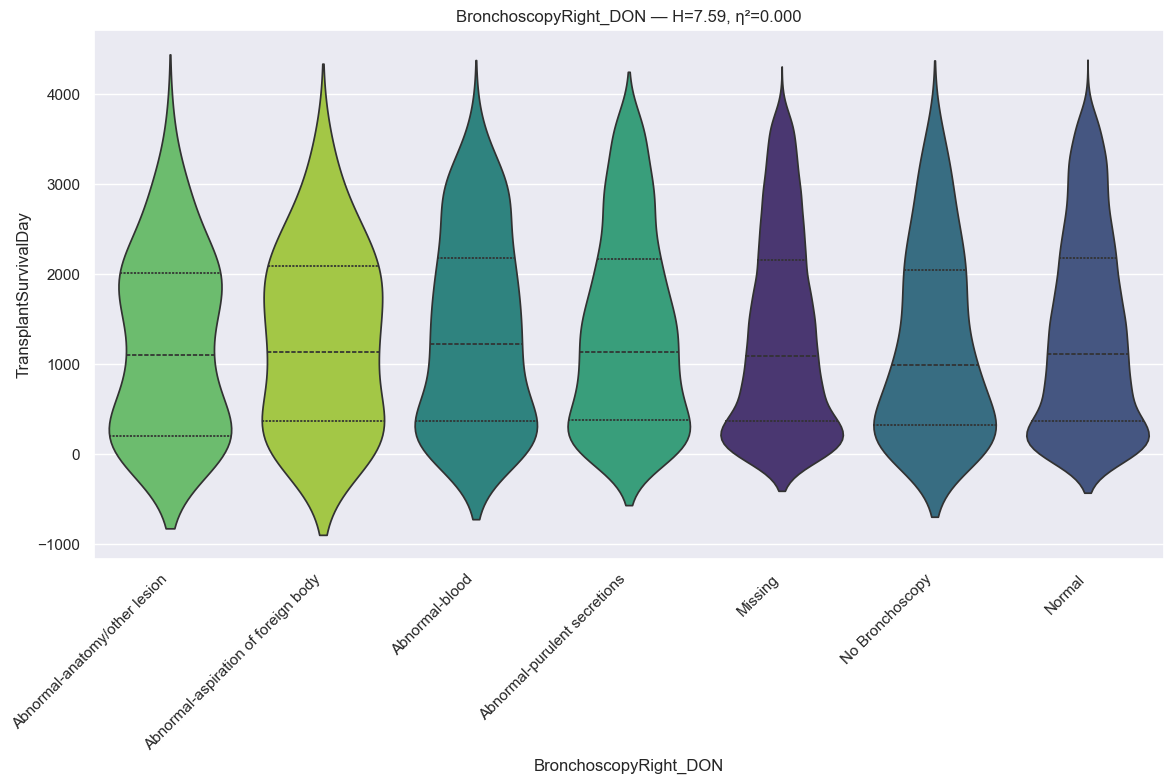

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     70 records
 * Abnormal-aspiration of foreign body               :     45 records
 * Abnormal-blood                                    :    204 records
 * Abnormal-purulent secretions                      :    739 records
 * Missing                                           :   3972 records
 * No Bronchoscopy                                   :    228 records
 * Normal                                            :   3030 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
 * Unknown if bronchoscopy performed                 :      3 records
--------------------------------------------------------------------------------
Kruskal H: 7.5856 | P-value: 2.700578e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [248]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [249]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but it becomes non-informative and should be treated as a single-level variable.

#### Chest Xray

In [250]:
# info
feature = u.get_feature_info(df, 'ChestXray', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique            top  freq
ChestXray_DON  8319      7  Abnormal-both  4504

:::: NaN Count:
ChestXray_DON    0 



{'ChestXray_DON': CategoricalDtype(categories=['Abnormal-both', 'Abnormal-left', 'Abnormal-right',
                   'Missing', 'No chest x-ray', 'Normal', 'Results Unknown'],
 , ordered=False, categories_dtype=object)}

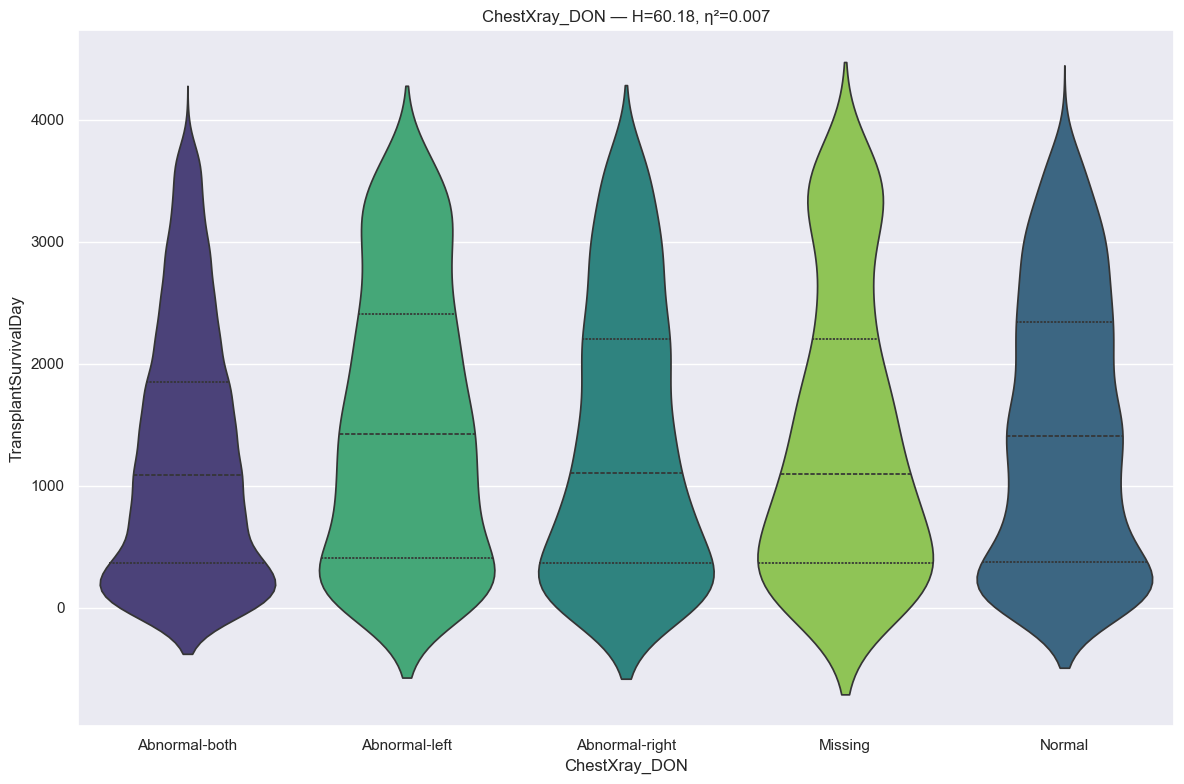

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4504 records
 * Abnormal-left                                     :    869 records
 * Abnormal-right                                    :    819 records
 * Missing                                           :    375 records
 * Normal                                            :   1731 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :      2 records
 * Results Unknown                                   :     19 records
--------------------------------------------------------------------------------
Kruskal H: 60.1824 | P-value: 2.655857e-12 | Effect η²: 0.0068
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=8.1101e-10 | thr=0.0050 | r= 0.100 | *Sig*
Abnormal-both vs Abno

In [251]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [252]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4504 records
 * Abnormal-left                                     :    869 records
 * Abnormal-right                                    :    819 records
 * Missing                                           :    375 records
 * Normal                                            :   1731 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :      2 records
 * Results Unknown                                   :     19 records
--------------------------------------------------------------------------------
Kruskal H: 60.1824 | P-value: 2.655857e-12 | Effect η²: 0.0068
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

::

In [253]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does have a statistically significant effect, but it becomes non-informative and should be treated as a single-level variable

#### Meds_DON

In [254]:
# info
feature = u.get_feature_info(df, 'Meds', cat=False)
# dtype
{col: df[col].dtype for col in feature}

         count unique top freq
Meds_DON  8319   7175      177

:::: NaN Count:
Meds_DON    0 



{'Meds_DON': dtype('O')}

In [255]:
# add to remove list
remove_cols.extend(feature)
# info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 8319 entries, 3 to 28747
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   8319 non-null   category
 1    AntigenDA1_DON                        8319 non-null   category
 2    AntigenDA2_DON                        8319 non-null   category
 3    AntigenDB1_DON                        8319 non-null   category
 4    AntigenDB2_DON                        8319 non-null   category
 5    AntigenDR1_DON                        8319 non-null   category
 6    AntigenDR2_DON                        8319 non-null   category
 7    Citizenship_DON                       8319 non-null   category
 8    PastCocaineUse_DON                    8319 non-null   category
 9    Age_DON                               8319 non-null   float64 
 10   Ethnicity_DON                         8319 non-null   category

In [256]:
# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

#### Write to Disk: Full Data

In [257]:
# save data: heart dataset
u.write_to_file(df, 'Female_DON_Heart_Data',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Female_DON_Category_Mapping',path='../Data/', format='pkl')

8,319 records written to ../Data/Female_DON_Heart_Data.pkl
42 records written to ../Data/Female_DON_Category_Mapping.pkl
